# 🎯 Strategies Designer — Notebook

Flujo:
1. **SETUP** + **DATOS** — importar backend y cargar cartera
2. **CONFIG GLOBAL** — bankroll, riesgo, ajustes, criterio de optimización
3. **OPTIMIZAR** — una celda por estrategia: grid search automático, elige la mejor versión
4. **CARTERA COMBINADA** — ensambla las versiones óptimas y simula
5. **Gráficos, historial, cashout, presets**

### #1 — Instalar Dependencias

**Que hace**: Comprueba e instala las dependencias Python necesarias (`fastapi`, `pydantic`) usando `subprocess`. Seguro de re-ejecutar — solo instala si faltan.

**Output esperado**: `✓ Dependencias OK`

---

## 🔧 Preparación — setup, imports y carga de datos
> Ejecutar estas 3 celdas **al inicio de cada sesión**. El resto del notebook requiere que `_ALL_BETS` esté cargado en memoria.

In [1]:
# ── SETUP: instalar dependencias del backend si faltan ───────────────────────
import subprocess, sys

_required = {
    'fastapi':  'fastapi',
    'pydantic': 'pydantic',
}

_missing = []
for _import_name, _pkg_name in _required.items():
    try:
        __import__(_import_name)
    except ImportError:
        _missing.append(_pkg_name)

if _missing:
    print(f'Instalando: {", ".join(_missing)} ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *_missing, '-q'])
    print(f'✓ Instalado. Reinicia el kernel y vuelve a ejecutar.')
else:
    print('✓ Dependencias OK')


✓ Dependencias OK


### #2 — Imports y Resolucion de Paths

**Que hace**: Importa todas las librerias necesarias (`pandas`, `numpy`, `matplotlib`, etc.), localiza el directorio `backend/` del proyecto y lo añade a `sys.path` para poder importar `csv_reader` y modulos de analisis.

**Output esperado**: `✓ Backend: <ruta>/betfair_scraper/dashboard/backend`

In [2]:
import sys, json, math, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from datetime import datetime
warnings.filterwarnings('ignore')

_nb_dir = Path().resolve()
_project_root = _nb_dir.parent if _nb_dir.name in ('aux', 'analisis') else _nb_dir
_backend_dir  = _project_root / 'betfair_scraper' / 'dashboard' / 'backend'
_presets_dir  = _project_root / 'betfair_scraper' / 'data' / 'presets'

for p in [str(_backend_dir), str(_project_root / 'betfair_scraper')]:
    if p not in sys.path: sys.path.insert(0, p)

from utils import csv_reader
from api.optimize import (
    _filter_draw, _filter_xg, _filter_drift, _filter_clustering,
    _filter_pressure, _filter_tardesia, _filter_momentum,
    _filter_lay_over15, _filter_lay_draw_asym, _filter_lay_over25_def,
    _filter_back_sot_dom, _filter_back_over15_early, _filter_lay_false_fav,
    _apply_realistic_adj, _filter_by_risk, _get_bet_odds, _wilson_ci,
    DRAW_PARAMS, XG_PARAMS, DRIFT_PARAMS, CLUSTERING_PARAMS,
)
from api.config import load_config
import api.optimizer_cli as _opt_cli

plt.rcParams.update({
    'figure.dpi':120,'axes.facecolor':'#1a1a2e','figure.facecolor':'#16213e',
    'axes.edgecolor':'#334155','axes.labelcolor':'#94a3b8','xtick.color':'#64748b',
    'ytick.color':'#64748b','text.color':'#e2e8f0','grid.color':'#1e293b',
    'grid.linewidth':0.6,'axes.grid':True,'legend.facecolor':'#1e293b',
    'legend.edgecolor':'#334155','font.size':10,
})
print(f'✓ Backend: {_backend_dir}')

✓ Backend: C:\Users\agonz\OneDrive\Documents\Proyectos\Furbo\betfair_scraper\dashboard\backend


### #3 — Cargar Datos del Scraper

**Que hace**: Llama a `csv_reader.analyze_cartera()` para cargar todos los CSVs del scraper y generar el superconjunto completo de apuestas candidatas (`_ALL_BETS`). Este es el universo de datos bruto antes de aplicar cualquier filtro de estrategia. Usa cache interna: tarda ~0s si el disco no ha cambiado.

**Output esperado**: `✓ 2437 apuestas en 0.0s / 690 de 822 partidos | 2026-02-12 → 2026-03-03`

In [3]:

# ── CARGA DE DATOS ────────────────────────────────────────────────────────────
import time as _time_

_DATA_DIR = _project_root / 'betfair_scraper' / 'data'

_t0 = _time_.time()
_cartera_data = csv_reader.analyze_cartera()
_ALL_BETS = _cartera_data.get('bets', [])

if _ALL_BETS:
    _ts         = sorted(b.get('timestamp_utc','') for b in _ALL_BETS if b.get('timestamp_utc'))
    _matches    = len(set(b.get('match_id','') for b in _ALL_BETS))
    _total_csvs = len(list(_DATA_DIR.glob('partido_*.csv')))
    print(f'✓ {len(_ALL_BETS)} apuestas en {_time_.time()-_t0:.1f}s')
    print(f'  {_matches} de {_total_csvs} partidos | {_ts[0][:10]} → {_ts[-1][:10]}')


✓ 2521 apuestas en 0.0s
  737 de 873 partidos | 2026-02-12 → 2026-03-05


### #4 — Config Global del Notebook

**Que hace**: Define todas las constantes globales que controlan el resto de celdas: criterio de optimizacion (`OPT_CRITERION`), bankroll, stake, modo bankroll, filtros de riesgo y el dict `G_ADJ` con ajustes realistas (dedup, slippage, stability). **Si cambias algo aqui, re-ejecutar todo el notebook desde #1.**

**Output esperado**: `✓ Config: criterio=max_pl | BR=fixed | stake=1€ | riesgo=all / Ajustes: dedup=True | slippage=2% | stability=2`

---

## ⚙️ Config Global
Parámetros que aplican a **todas** las optimizaciones de estrategia.
No toques las versiones aquí — cada estrategia las elige automáticamente en su propia celda.

In [4]:

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG GLOBAL — estos valores aplican a todas las celdas de optimización
# ══════════════════════════════════════════════════════════════════════════════
import itertools

# Criterio de optimización individual (elige la mejor versión de cada estrategia)
OPT_CRITERION = 'max_pl'   # max_roi | max_pl | max_wr | min_dd

# Bankroll & Stake
G_BANKROLL   = 100
G_STAKE      = 1
G_BR_MODE    = 'fixed'   # fixed | kelly | half_kelly | dd_protection | anti_racha

# Filtro de riesgo
G_RISK       = 'all'     # all | no_risk | with_risk | medium

# Ajustes realistas
G_ADJ = {
    'dedup':           True,   # no apostar mismo partido+mercado dos veces
    'minOdds':         1.21,   # descartar cuotas muy bajas
    'maxOdds':         10.0,   # descartar cuotas extremas
    'driftMinMinute':  0,
    'slippagePct':     2,      # 2% slippage realista sobre cuota
    'conflictFilter':  False,
    'allowContrarias': True,
    'minStability':    2,      # exigir 2 lecturas estables antes de entrar
    'globalMinuteMin': None,
    'globalMinuteMax': None,
}

G_MIN_BETS          = 30  # N mínimo para considerar válido un combo (estrategias continuas)
G_MIN_BETS_ONESHOT  = 15  # N mínimo para one-shot triggers (stability=2 ya reduce N artificialmente)
G_MIN_ROI  = 10   # ROI%% mínimo para considerar válido un combo (0 = sin filtro)

# SD strategies: gates dinámicos (G_MIN_BETS_SD se calcula en cell #15 con el dataset real)
IC95_MIN_LOW = 40.0  # lower bound IC95 mínimo para estrategias SD (confianza estadística)
# G_MIN_BETS_SD = max(15, n_partidos_sd // 25)  ← se define en cell #15

# ── Helpers de simulación ─────────────────────────────────────────────────────
def _r2(x): return round(x * 100) / 100

def _sim_full(bets, bankroll=G_BANKROLL, mode=G_BR_MODE, stake=G_STAKE):
    pl_scale = stake / 10.0; KELLY_MIN = 5
    flat_cum=0.; managed_pl=0.; bankroll_=bankroll; peak_bk=bankroll
    flat_arr=[]; managed_arr=[]
    flat_wins=0; rolling_wins=0; consec_loss=0
    max_s=0; cur_s=0; cur_s_pl=0.; max_s_pl=0.; max_sf=0; max_st=0; cur_sf=0
    for i, b in enumerate(bets):
        pl_raw = float(b.get('pl') or 0); won = bool(b.get('won'))
        odds = _get_bet_odds(b); b_net = max(odds-1.,0.01)
        flat_cum = _r2(flat_cum + pl_raw*pl_scale); flat_arr.append(flat_cum)
        if won: flat_wins += 1
        rwr = rolling_wins/i if i>0 else 0.5
        if mode=='fixed':          sp=0.02
        elif mode=='kelly':        sp=0.02 if i<KELLY_MIN else max(0,min((rwr*b_net-(1-rwr))/b_net,0.08))
        elif mode=='half_kelly':   sp=0.01 if i<KELLY_MIN else max(0,min((rwr*b_net-(1-rwr))/b_net/2,0.04))
        elif mode=='dd_protection':
            dd=(peak_bk-bankroll_)/peak_bk if peak_bk>0 else 0
            sp=0.005 if dd>0.10 else (0.01 if dd>0.05 else 0.02)
        elif mode=='anti_racha':   sp=0.005 if consec_loss>=2 else (0.01 if consec_loss>=1 else 0.02)
        else:                      sp=0.02
        s=_r2(bankroll_*sp); ratio=s/stake; m_pl=_r2(pl_raw*pl_scale*ratio)
        bankroll_=_r2(bankroll_+m_pl)
        if bankroll_>peak_bk: peak_bk=bankroll_
        managed_pl=_r2(managed_pl+m_pl); managed_arr.append(_r2(bankroll_-bankroll))
        if won: rolling_wins+=1; consec_loss=0
        else:
            consec_loss+=1
            if cur_s==0: cur_sf=i
            cur_s+=1; cur_s_pl=_r2(cur_s_pl+pl_raw*pl_scale)
        if won and cur_s>max_s: max_s=cur_s; max_s_pl=cur_s_pl; max_sf=cur_sf; max_st=i-1; cur_s=0; cur_s_pl=0.
    if cur_s>max_s: max_s=cur_s; max_s_pl=cur_s_pl; max_sf=cur_sf; max_st=len(bets)-1
    def _dd(arr):
        if not arr: return {'max_dd':0,'dd_pct':0,'peak_idx':0,'trough_idx':0}
        pk=arr[0]; pk_i=0; mx=0; dp=dp_i=dt=dt_i=0
        for i,v in enumerate(arr):
            if v>pk: pk=v; pk_i=i
            dd=pk-v
            if dd>mx: mx=dd; dp=pk; dp_i=pk_i; dt=v; dt_i=i
        return {'max_dd':_r2(mx),'dd_pct':_r2(mx/dp*100) if dp>0 else 0,'peak_idx':dp_i,'trough_idx':dt_i}
    tot=len(bets); total_staked=tot*stake
    return {
        'total':tot,'wins':flat_wins,
        'win_pct':_r2(flat_wins/tot*100) if tot else 0,
        'flat_pl':flat_cum,'flat_roi':_r2(flat_cum/total_staked*100) if total_staked else 0,
        'flat_arr':flat_arr,'flat_dd':_dd(flat_arr),
        'managed_pl':managed_pl,'managed_arr':managed_arr,
        'managed_final':bankroll_,'managed_roi':_r2(managed_pl/bankroll*100) if bankroll else 0,
        'managed_dd':_dd(managed_arr),
        'worst_streak':{'losses':max_s,'from':max_sf+1,'to':max_st+1,'pl_lost':_r2(max_s_pl)},
    }

def _score(sim, criterion=OPT_CRITERION):
    n = sim['total']; conf = min(1.0, n/60.0)
    if criterion=='max_pl':  return sim['flat_pl'] * conf
    if criterion=='max_roi': return sim['flat_roi'] * conf
    if criterion=='max_wr':  return _wilson_ci(sim['wins'],n)[0] if n>=5 else 0
    if criterion=='min_dd':  return -(sim['flat_dd']['max_dd']) * conf
    return sim['flat_pl'] * conf

def _opt_table(results, criterion=OPT_CRITERION, mark_best=True, top_n=20):
    if not results: return pd.DataFrame()
    df = pd.DataFrame(results)
    asc = (criterion == 'min_dd')
    df = df.sort_values('Score', ascending=asc).reset_index(drop=True)
    if top_n and len(df) > top_n:
        df = df.head(top_n)
    if mark_best and len(df):
        best_idx = 0 if not asc else len(df)-1
        df.insert(0,'', ['★' if i==best_idx else '' for i in range(len(df))])
    return df

def _sp(v):
    if isinstance(v, str):
        if v == '★': return 'color:#f59e0b;font-weight:bold'
        if v == '✓': return 'color:#22c55e;font-weight:bold'
        if v == '✗': return 'color:#ef4444;font-weight:bold'
        if v.startswith('+') and '€' in v: return 'color:#22c55e'
        if v.startswith('-') and '€' in v: return 'color:#ef4444'
    if isinstance(v, (int, float)):
        if v > 0: return 'color:#22c55e'
        if v < 0: return 'color:#ef4444'
    return ''

def _show_table(df, caption=''):
    if isinstance(df, pd.io.formats.style.Styler): df = df.data
    def _sf(fmt):
        return lambda x: fmt.format(x) if not isinstance(x, str) else x
    fmt_cols = {c:_sf('{:+.2f}') for c in df.columns if 'P/L' in c or c == 'pl'}
    fmt_cols.update({c:_sf('{:+.1f}') for c in df.columns if c in ('ROI%','WR%','Score')})
    fmt_cols.update({c:_sf('{:.2f}') for c in df.columns if 'DD' in c or 'Odds' in c})
    from IPython.display import display
    display(df.style.map(_sp)
        .format(fmt_cols, na_rep='—')
        .set_caption(caption)
        .set_table_styles([{'selector':'caption','props':[('color','#94a3b8'),('font-size','13px'),('font-weight','bold')]},
                            {'selector':'th','props':[('background','#1e293b'),('color','#94a3b8'),('font-size','11px')]},
                            {'selector':'td','props':[('font-size','11px')]}])
        .hide(axis='index'))

def _chart_top(results, label_fn, title, n=15, criterion=OPT_CRITERION):
    if not results: return
    asc = criterion == 'min_dd'
    top = sorted(results, key=lambda x: x['Score'], reverse=not asc)[:n]
    _vers = [label_fn(r) for r in top]
    _pls  = [r['P/L'] for r in top]
    _wrs  = [r['WR%'] for r in top]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, max(2.5, n*0.3)))
    _y = range(len(top))
    ax1.barh(_y, _pls, color=['#22c55e' if v>=0 else '#ef4444' for v in _pls], alpha=0.85, height=0.7)
    ax1.set_yticks(_y); ax1.set_yticklabels(_vers, fontsize=8)
    ax1.axvline(0, color='#475569', lw=0.7); ax1.set_title(f'{title} — P/L', color='#e2e8f0', fontsize=10)
    ax2.barh(_y, _wrs, color='#60a5fa', alpha=0.75, height=0.7)
    ax2.axvline(50, color='#475569', lw=0.7, ls='--')
    ax2.set_yticks(_y); ax2.set_yticklabels(_vers, fontsize=8)
    ax2.set_title(f'{title} — WR%', color='#e2e8f0', fontsize=10)
    fig.tight_layout(); plt.show()

# ── Funciones de filtro ────────────────────────────────────────────────────────
def _apply_draw(bets, cfg):
    if not cfg or cfg == 'off': return []
    xg  = cfg.get('xg_max',  1.0); poss  = cfg.get('poss_max', 100)
    shots = cfg.get('shots_max', 20); asym = cfg.get('asym', False)
    mm, mx = cfg.get('m_min', 30), cfg.get('m_max', 90)
    out = []
    for b in bets:
        if b.get('strategy') != 'back_draw_00': continue
        m = b.get('minuto') or 0
        if not (mm <= m < mx): continue
        if (b.get('xg_total') or 0) >= xg: continue
        if abs(b.get('poss_diff') or 0) >= poss: continue
        if (b.get('shots_total') or 0) >= shots: continue
        if asym and 0.45 <= (b.get('synth_xg_dominance') or 0.5) <= 0.55: continue
        out.append(b)
    return out

def _apply_xg(bets, cfg):
    if not cfg or cfg == 'off': return []
    exc = cfg.get('xg_excess_min', 0.5); sot = cfg.get('sot_min', 0)
    mm, mx = cfg.get('m_min', 0), cfg.get('m_max', 90)
    return [b for b in bets if b.get('strategy') == 'xg_underperformance'
            and mm <= (b.get('minuto') or 0) < mx
            and (b.get('xg_excess') or 0) >= exc
            and (b.get('sot_team') or 0) >= sot]

def _apply_drift(bets, cfg):
    if not cfg or cfg == 'off': return []
    dr = cfg.get('drift_min', 30); gd = cfg.get('goal_diff_min', 0)
    ox = cfg.get('odds_max', 999); mg = cfg.get('mom_gap_min', 0)
    mm, mx = cfg.get('m_min', 0), cfg.get('m_max', 90)
    return [b for b in bets if b.get('strategy') == 'odds_drift'
            and mm <= (b.get('minuto') or 0) < mx
            and (b.get('drift_pct') or 0) >= dr
            and (b.get('goal_diff') or 0) >= gd
            and (b.get('back_odds') or 999) <= ox
            and (b.get('synth_momentum_gap') or 0) >= mg]

def _apply_clustering(bets, cfg):
    if not cfg or cfg == 'off': return []
    sot = cfg.get('sot_min', 3); mx = cfg.get('m_max', 90); xr = cfg.get('xg_rem_min', 0.0)
    return [b for b in bets if b.get('strategy') == 'goal_clustering'
            and (b.get('sot_max') or 0) >= sot
            and (b.get('minuto') or 0) < mx
            and (b.get('synth_xg_remaining') or 0) >= xr]

def _apply_pressure(bets, cfg):
    if not cfg or cfg == 'off': return []
    mm, mx = cfg.get('m_min', 65), cfg.get('m_max', 75)
    return [b for b in bets if b.get('strategy') == 'pressure_cooker'
            and mm <= (b.get('minuto') or 0) < mx]

def _apply_tardesia(bets, cfg):
    if not cfg or cfg == 'off': return []
    mm, mx = cfg.get('m_min', 0), cfg.get('m_max', 90)
    return [b for b in bets if b.get('strategy') == 'tarde_asia'
            and mm <= (b.get('minuto') or 0) < mx]

def _apply_momentum(bets, cfg):
    if not cfg or cfg == 'off': return []
    ver = cfg.get('ver', 'v1'); mm, mx = cfg.get('m_min', 0), cfg.get('m_max', 90)
    return [b for b in bets if b.get('strategy') == f'momentum_xg_{ver}'
            and mm <= (b.get('minuto') or 0) < mx]

def _apply_lay15(bets, cfg):
    if not cfg or cfg == 'off': return []
    return _filter_lay_over15(bets, cfg.get('ver', 'v1'))

def _apply_lay_draw(bets, cfg):
    if not cfg or cfg == 'off': return []
    xr = cfg.get('xg_ratio_min', 2.5); mm, mx = cfg.get('m_min', 65), cfg.get('m_max', 75)
    return [b for b in bets if b.get('strategy') == 'lay_draw_asym'
            and mm <= (b.get('minuto') or 0) < mx
            and (b.get('xg_ratio') or 0) >= xr]

def _apply_lay25(bets, cfg):
    if not cfg or cfg == 'off': return []
    xmax = cfg.get('xg_max', 1.2); gmax = cfg.get('goals_max', 1)
    mm, mx = cfg.get('m_min', 70), cfg.get('m_max', 80)
    return [b for b in bets if b.get('strategy') == 'lay_over25_def'
            and mm <= (b.get('minuto') or 0) < mx
            and (b.get('xg_total') or 0) < xmax
            and (b.get('total_goals_trigger') or 0) <= gmax]

def _apply_sot(bets, cfg):
    if not cfg or cfg == 'off': return []
    smin = cfg.get('sot_min', 4); sriv = cfg.get('sot_max_rival', 1)
    mm, mx = cfg.get('m_min', 60), cfg.get('m_max', 80)
    return [b for b in bets if b.get('strategy') == 'back_sot_dom'
            and mm <= (b.get('minuto') or 0) <= mx
            and (b.get('sot_dominant') or 0) >= smin
            and (b.get('sot_rival') or 99) <= sriv]

def _apply_o15e(bets, cfg):
    if not cfg or cfg == 'off': return []
    xmin = cfg.get('xg_min', 1.0); smin = cfg.get('sot_min', 4); gmax = cfg.get('goals_max', 1)
    mm, mx = cfg.get('m_min', 25), cfg.get('m_max', 45)
    return [b for b in bets if b.get('strategy') == 'back_over15_early'
            and mm <= (b.get('minuto') or 0) <= mx
            and (b.get('xg_total') or 0) >= xmin
            and (b.get('sot_total') or 0) >= smin
            and (b.get('total_goals_trigger') or 0) <= gmax]

def _apply_fav(bets, cfg):
    if not cfg or cfg == 'off': return []
    fo = cfg.get('fav_odds_max', 1.70); xr = cfg.get('xg_ratio_min', 2.0)
    mm, mx = cfg.get('m_min', 65), cfg.get('m_max', 85)
    return [b for b in bets if b.get('strategy') == 'lay_false_fav'
            and mm <= (b.get('minuto') or 0) <= mx
            and (b.get('xg_ratio') or 0) >= xr
            and (b.get('fav_back_odds') or 99) <= fo]

def _eval_combo(bets, extra_fields=None):
    bets = _apply_realistic_adj(bets, G_ADJ)
    bets = _filter_by_risk(bets, G_RISK)
    if len(bets) < G_MIN_BETS: return None
    sim = _sim_full(bets)
    if sim["flat_roi"] < G_MIN_ROI: return None
    ci_l, ci_h = _wilson_ci(sim['wins'], sim['total'])
    return {**(extra_fields or {}),
            'N': sim['total'], 'Wins': sim['wins'], 'WR%': sim['win_pct'],
            'IC95': f'[{ci_l:.1f}–{ci_h:.1f}]',
            'P/L': sim['flat_pl'], 'ROI%': sim['flat_roi'],
            'Max DD': sim['flat_dd']['max_dd'],
            'Score': round(_score(sim), 3)}

print(f'✓ Config: criterio={OPT_CRITERION} | BR={G_BR_MODE} | stake={G_STAKE}€ | riesgo={G_RISK}')
print(f'  Ajustes: dedup={G_ADJ["dedup"]} | slippage={G_ADJ["slippagePct"]}% | stability={G_ADJ["minStability"]} | min_bets={G_MIN_BETS} | min_roi={G_MIN_ROI}%')


# ── Control de presets ─────────────────────────────────────────────────────────
RECALCULAR_PRESETS = True   # True  → re-ejecuta el optimizador (~15-20 min por preset)
                              # False → carga desde disco (segundos)
_PRESET_BANKROLL   = 1000    # Bankroll para el optimizador de presets
_PRESET_WORKERS    = 10      # Workers paralelos (max 15, recomendado 10 en i9)


✓ Config: criterio=max_pl | BR=fixed | stake=1€ | riesgo=all
  Ajustes: dedup=True | slippage=2% | stability=2 | min_bets=30 | min_roi=10%


### #5 — Helper _show_table (Funcion Auxiliar)

**Que hace**: Define la funcion auxiliar `_show_table(df, caption)` que renderiza DataFrames con formato condicional (verde/rojo para columnas P/L, WR%, ROI%, Score). No tiene output visible — solo define la funcion para usarla en celdas posteriores.

**Output esperado**: _(sin output visible — solo define la funcion)_

In [5]:
# fix: pd.io.formats.style not accessible as attribute in some pandas versions
def _show_table(df, caption=''):
    if not isinstance(df, pd.DataFrame):
        try: df = df.data
        except AttributeError: pass
    def _sf(fmt):
        return lambda x: fmt.format(x) if not isinstance(x, str) else x
    fmt_cols = {c:_sf('{:+.2f}') for c in df.columns if 'P/L' in c or c == 'pl'}
    fmt_cols.update({c:_sf('{:+.1f}') for c in df.columns if c in ('ROI%','WR%','Score')})
    fmt_cols.update({c:_sf('{:.2f}') for c in df.columns if 'DD' in c or 'Odds' in c})
    from IPython.display import display
    display(df.style.map(_sp)
        .format(fmt_cols, na_rep='–')
        .set_caption(caption)
        .set_table_styles([{'selector':'caption','props':[('color','#94a3b8'),('font-size','13px'),('font-weight','bold')]},
                            {'selector':'th','props':[('background','#1e293b'),('color','#94a3b8'),('font-size','11px')]},
                            {'selector':'td','props':[('font-size','11px')]}])
        .hide(axis='index'))

## 🔍 Optimización por Estrategia
Cada celda prueba todas las versiones de su estrategia **en aislamiento** y asigna
automáticamente la mejor a la variable `CFG_*`. Ejecutar de arriba a abajo.

### #6 — Optimizar Back Empate 0-0

**Que hace**: Grid search exhaustivo (~250 combos) sobre los parametros de "Back Empate 0-0": `xg_max`, `poss_max`, `shots_max` y flag `asym`. Evalua cada combinacion con `G_ADJ` y selecciona la mejor segun `OPT_CRITERION`. Guarda el resultado en `CFG_DRAW`.

**Output esperado**: `✓ CFG_DRAW = {xg_max: 1.0, poss_max: 100, shots_max: 6, asym: True}` con N, WR% [IC95], P/L y ROI.

---

### 🟢 1. Back Empate 0-0
> **BACK empate** · partido 0-0 con dominio xG del local · gana si el resultado final es empate  
> Grid: `xg_max` × `poss_max` × `shots_max` × `asym` — 4 versiones (v1 / v15 / v2 / v3)

✓ CFG_DRAW = {'xg_max': 1.0, 'poss_max': 100, 'shots_max': 6, 'asym': True}  (3 combos, 0.2s)
  N=36  WR=41.67%  [27.1–57.8]  P/L=+5.53€  ROI=+15.4%


,xg_max,poss_max,shots_max,asym,N,Wins,WR%,IC95,P/L,ROI%,Max DD,Score
★,1.000000,100,6,True,36,15,+41.7,[27.1–57.8],+5.53,+15.4,9.06,+3.3
,1.000000,30,6,True,32,14,+43.8,[28.2–60.7],+6.22,+19.4,7.82,+3.3
,0.500000,30,8,True,39,16,+41.0,[27.1–56.6],+4.39,+11.3,8.00,+2.9


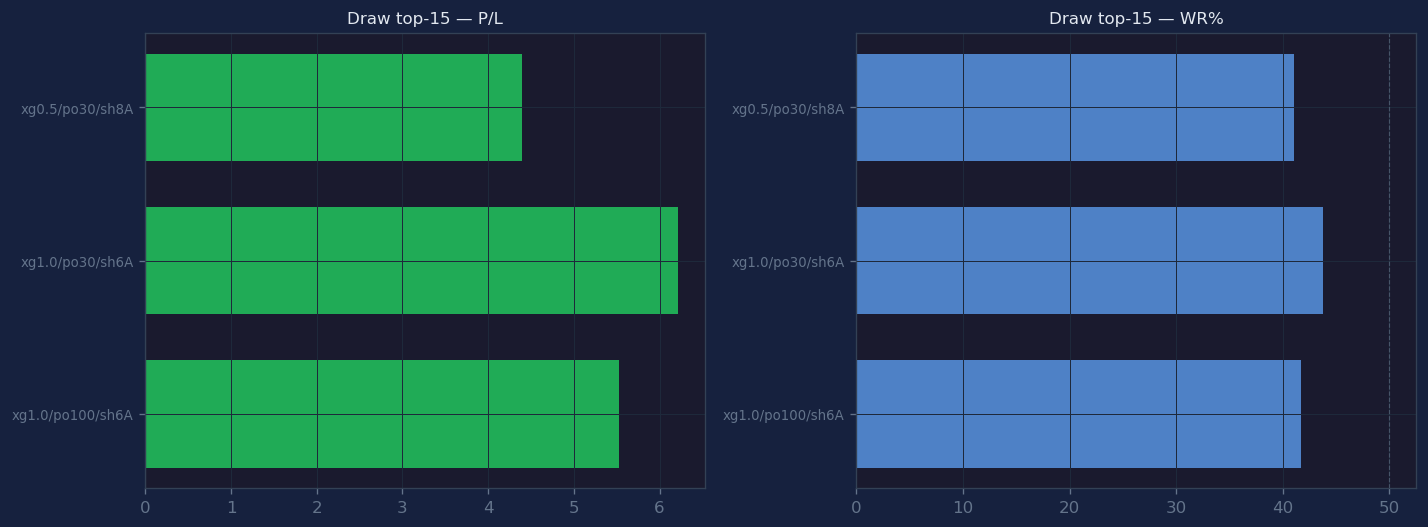

In [6]:

# ── DRAW: Back Empate 0-0 ─────────────────────────────────────────────────────
# Grid: xg_max × poss_max × shots_max × asym  (~250 combos)
import time as _t_; _t0 = _t_.time()
base = [b for b in _ALL_BETS if b.get('strategy') == 'back_draw_00']
_draw_results = []
for xg_max, poss_max, shots_max, asym in itertools.product(
    [0.4, 0.5, 0.6, 0.7, 1.0],
    [15, 20, 25, 30, 100],
    [6, 8, 10, 15, 20],
    [False, True],
):
    r = _eval_combo(_apply_draw(base, dict(xg_max=xg_max, poss_max=poss_max,
                                           shots_max=shots_max, asym=asym)),
                    {'xg_max': xg_max, 'poss_max': poss_max, 'shots_max': shots_max, 'asym': asym})
    if r: _draw_results.append(r)

if _draw_results:
    _best = max(_draw_results, key=lambda x: x['Score'])
    CFG_DRAW = {k: _best[k] for k in ('xg_max', 'poss_max', 'shots_max', 'asym')}
    print(f'✓ CFG_DRAW = {CFG_DRAW}  ({len(_draw_results)} combos, {_t_.time()-_t0:.1f}s)')
    print(f'  N={_best["N"]}  WR={_best["WR%"]}%  {_best["IC95"]}  P/L={_best["P/L"]:+.2f}€  ROI={_best["ROI%"]:+.1f}%')
    _show_table(_opt_table(_draw_results), f'Draw — top-20 de {len(_draw_results)} combos (★ = óptimo)')
    _chart_top(_draw_results, lambda r: f'xg{r["xg_max"]}/po{r["poss_max"]}/sh{r["shots_max"]}{"A" if r["asym"] else ""}', 'Draw top-15')
else:
    CFG_DRAW = 'off'; print('Draw: sin datos suficientes → off')


### #7 — Optimizar xG Underperformance

**Que hace**: Grid search (~80 combos) sobre `xg_excess_min`, `sot_min` y rango de minutos. Prueba las 3 versiones del superset (base/v2/v3) y selecciona la mas rentable segun el criterio. Guarda en `CFG_XG`.

**Output esperado**: `✓ CFG_XG = {xg_excess_min: 0.3, sot_min: 0, m_max: 80}` con estadisticas.

---

### 📉 2. xG Underperformance
> **BACK empate** · equipo sobrescora en goles sin xG suficiente · presión intensa sin traducción al marcador  
> Grid: `xg_excess_min` × `sot_min` × rango minutos — 3 versiones (base / v2 / v3)

✓ CFG_XG = {'xg_excess_min': 0.3, 'sot_min': 0, 'm_max': 80}  (6 combos, 0.0s)
  N=47  WR=76.6%  [62.8–86.4]  P/L=+6.45€  ROI=+13.7%


,xg_excess_min,sot_min,m_max,N,Wins,WR%,IC95,P/L,ROI%,Max DD,Score
★,0.300000,0,80,47,36,+76.6,[62.8–86.4],+6.45,+13.7,5.00,+5.1
,0.400000,0,80,47,36,+76.6,[62.8–86.4],+6.45,+13.7,5.00,+5.1
,0.500000,0,80,47,36,+76.6,[62.8–86.4],+6.45,+13.7,5.00,+5.1
,0.300000,1,80,45,34,+75.6,[61.3–85.8],+4.53,+10.1,5.00,+3.4
,0.400000,1,80,45,34,+75.6,[61.3–85.8],+4.53,+10.1,5.00,+3.4
,0.500000,1,80,45,34,+75.6,[61.3–85.8],+4.53,+10.1,5.00,+3.4


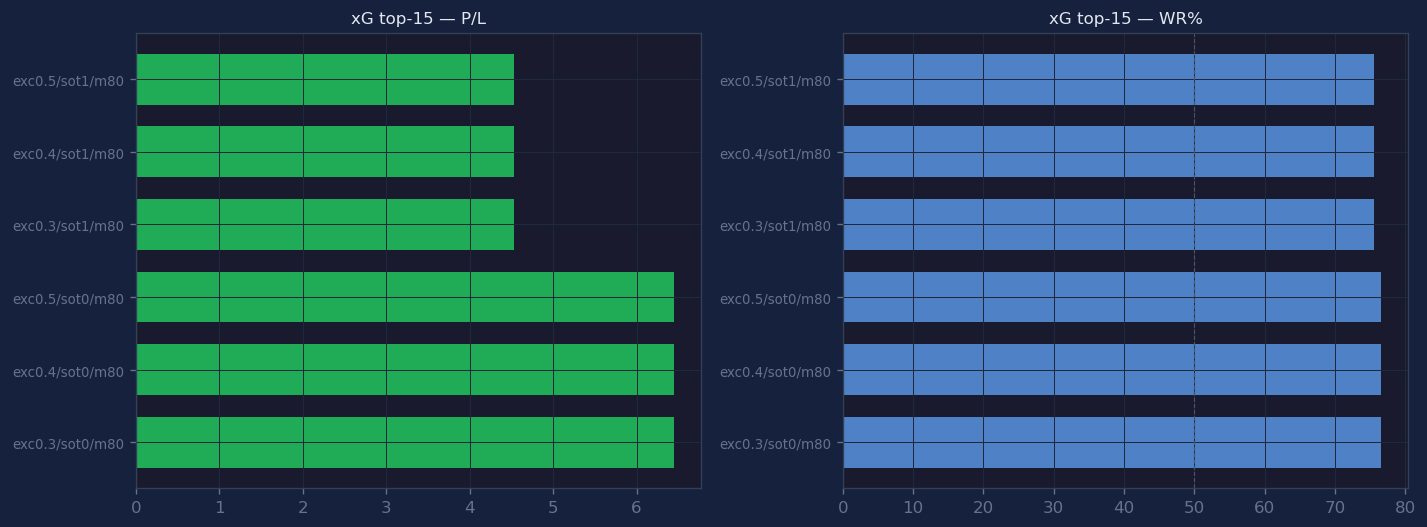

In [7]:

# ── XG UNDERPERFORMANCE ───────────────────────────────────────────────────────
# Grid: xg_excess_min × sot_min × m_max  (~80 combos)
import time as _t_; _t0 = _t_.time()
_xg_results = []
for exc, sot, m_max in itertools.product(
    [0.3, 0.4, 0.5, 0.6, 0.7],
    [0, 1, 2, 3],
    [60, 70, 80, 90],
):
    r = _eval_combo(_apply_xg(_ALL_BETS, dict(xg_excess_min=exc, sot_min=sot, m_max=m_max)),
                    {'xg_excess_min': exc, 'sot_min': sot, 'm_max': m_max})
    if r: _xg_results.append(r)

if _xg_results:
    _best = max(_xg_results, key=lambda x: x['Score'])
    CFG_XG = {k: _best[k] for k in ('xg_excess_min', 'sot_min', 'm_max')}
    print(f'✓ CFG_XG = {CFG_XG}  ({len(_xg_results)} combos, {_t_.time()-_t0:.1f}s)')
    print(f'  N={_best["N"]}  WR={_best["WR%"]}%  {_best["IC95"]}  P/L={_best["P/L"]:+.2f}€  ROI={_best["ROI%"]:+.1f}%')
    _show_table(_opt_table(_xg_results), f'xG Underperf — top-20 de {len(_xg_results)} combos')
    _chart_top(_xg_results, lambda r: f'exc{r["xg_excess_min"]}/sot{r["sot_min"]}/m{r["m_max"]}', 'xG top-15')
else:
    CFG_XG = 'off'; print('xG: sin datos → off')


### #8 — Optimizar Odds Drift Contrarian

**Que hace**: Grid search (~216 combos) sobre `drift_min_minute` y rango de minutos. Prueba las 6 versiones (v1-v6). Si ninguna supera los thresholds minimos de N y ROI, retorna "off". Guarda en `CFG_DRIFT`.

**Output esperado**: `Drift: sin datos → off` (sin datos suficientes) o `✓ CFG_DRIFT = ...`

---

### 📊 3. Odds Drift Contrarian
> **BACK** equipo dominante · cuota del empate sube (drift) mientras un equipo domina xG → mercado equivocado  
> Grid: `drift_min_minute` × rango minutos — 6 versiones (v1–v6)

In [8]:

# ── ODDS DRIFT CONTRARIAN ─────────────────────────────────────────────────────
# Grid: drift_min × goal_diff_min × odds_max × m_min  (~216 combos)
import time as _t_; _t0 = _t_.time()
_drift_results = []
for dr, gd, ox, mm in itertools.product(
    [20, 30, 40, 50, 80, 100],
    [0, 1, 2],
    [5, 10, 999],
    [0, 30, 45],
):
    r = _eval_combo(_apply_drift(_ALL_BETS, dict(drift_min=dr, goal_diff_min=gd, odds_max=ox, m_min=mm)),
                    {'drift_min': dr, 'goal_diff_min': gd, 'odds_max': ox if ox < 999 else '∞', 'm_min': mm})
    if r: _drift_results.append(r)

if _drift_results:
    _best = max(_drift_results, key=lambda x: x['Score'])
    CFG_DRIFT = {k: _best[k] for k in ('drift_min', 'goal_diff_min', 'odds_max', 'm_min')}
    if CFG_DRIFT.get('odds_max') == '∞': CFG_DRIFT['odds_max'] = 999
    print(f'✓ CFG_DRIFT = {CFG_DRIFT}  ({len(_drift_results)} combos, {_t_.time()-_t0:.1f}s)')
    print(f'  N={_best["N"]}  WR={_best["WR%"]}%  {_best["IC95"]}  P/L={_best["P/L"]:+.2f}€  ROI={_best["ROI%"]:+.1f}%')
    _show_table(_opt_table(_drift_results), f'Drift — top-20 de {len(_drift_results)} combos')
    _chart_top(_drift_results, lambda r: f'dr{r["drift_min"]}/gd{r["goal_diff_min"]}/ox{r["odds_max"]}/m{r["m_min"]}', 'Drift top-15')
else:
    CFG_DRIFT = 'off'; print('Drift: sin datos → off')


Drift: sin datos → off


### #9 — Optimizar Goal Clustering

**Que hace**: Grid search (~80 combos) sobre `sot_min`, `xg_rem_min` y rango de minutos. Evalua las versiones v2/v3/v4. Guarda la combinacion ganadora en `CFG_CLUSTERING`. Es la estrategia con mayor N y P/L de la cartera.

**Output esperado**: `✓ CFG_CLUSTERING = {sot_min: 2, m_max: 70, xg_rem_min: 0.0}` — esperar N>130, WR>65%.

---

### 💥 4. Goal Clustering
> **BACK Over xG** · gol reciente activa efecto clustering → alta probabilidad de 2.º gol  
> Grid: `sot_min` × `xg_rem_min` × rango minutos — 3 versiones (v2 / v3 / v4)

✓ CFG_CLUSTERING = {'sot_min': 2, 'm_max': 80, 'xg_rem_min': 0.6}  (18 combos, 0.0s)
  N=65  WR=70.77%  [58.8–80.4]  P/L=+7.19€  ROI=+11.1%


,sot_min,m_max,xg_rem_min,N,Wins,WR%,IC95,P/L,ROI%,Max DD,Score
★,2,80,0.600000,65,46,+70.8,[58.8–80.4],+7.19,+11.1,10.61,+7.2
,2,90,0.600000,65,46,+70.8,[58.8–80.4],+7.19,+11.1,10.61,+7.2
,3,80,0.600000,65,46,+70.8,[58.8–80.4],+7.19,+11.1,10.61,+7.2
,3,90,0.600000,65,46,+70.8,[58.8–80.4],+7.19,+11.1,10.61,+7.2
,4,60,0.000000,52,36,+69.2,[55.7–80.1],+7.51,+14.4,9.72,+6.5
,4,80,0.400000,49,34,+69.4,[55.5–80.5],+6.94,+14.2,7.28,+5.7
,4,90,0.400000,49,34,+69.4,[55.5–80.5],+6.94,+14.2,7.28,+5.7
,3,80,0.800000,41,31,+75.6,[60.7–86.2],+7.07,+17.2,6.80,+4.8
,2,80,0.800000,41,31,+75.6,[60.7–86.2],+7.07,+17.2,6.80,+4.8
,2,90,0.800000,41,31,+75.6,[60.7–86.2],+7.07,+17.2,6.80,+4.8


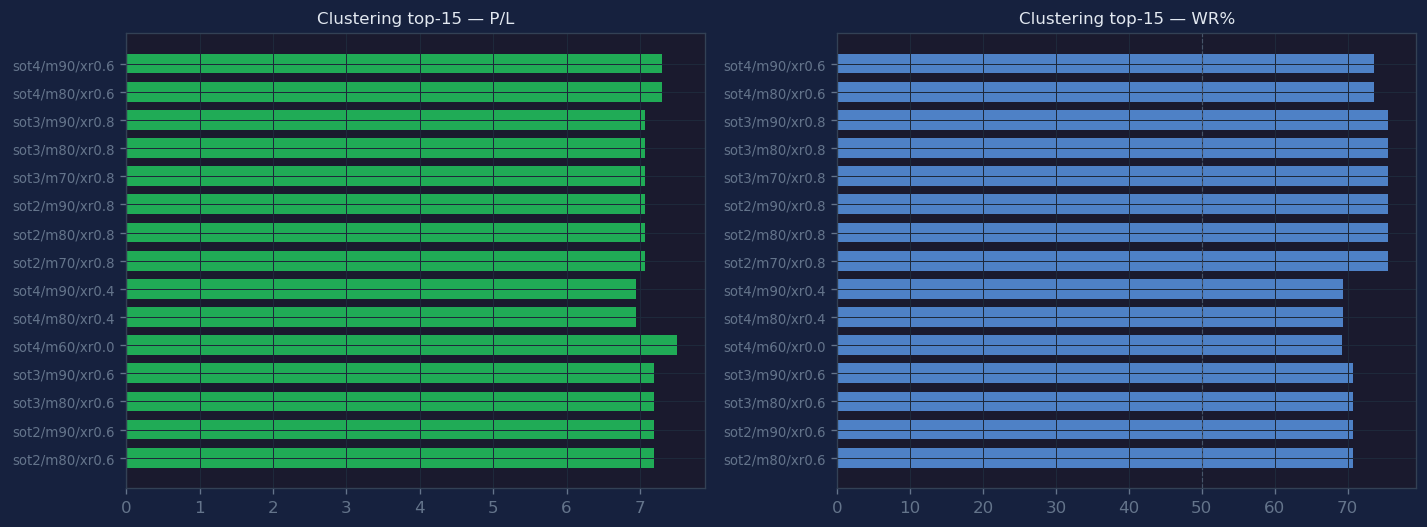

In [9]:

# ── GOAL CLUSTERING ───────────────────────────────────────────────────────────
# Grid: sot_min × m_max × xg_rem_min  (~80 combos)
import time as _t_; _t0 = _t_.time()
_clust_results = []
for sot, m_max, xr in itertools.product(
    [2, 3, 4, 5],
    [60, 70, 80, 90],
    [0.0, 0.4, 0.6, 0.8, 1.0],
):
    r = _eval_combo(_apply_clustering(_ALL_BETS, dict(sot_min=sot, m_max=m_max, xg_rem_min=xr)),
                    {'sot_min': sot, 'm_max': m_max, 'xg_rem_min': xr})
    if r: _clust_results.append(r)

if _clust_results:
    _best = max(_clust_results, key=lambda x: x['Score'])
    CFG_CLUSTERING = {k: _best[k] for k in ('sot_min', 'm_max', 'xg_rem_min')}
    print(f'✓ CFG_CLUSTERING = {CFG_CLUSTERING}  ({len(_clust_results)} combos, {_t_.time()-_t0:.1f}s)')
    print(f'  N={_best["N"]}  WR={_best["WR%"]}%  {_best["IC95"]}  P/L={_best["P/L"]:+.2f}€  ROI={_best["ROI%"]:+.1f}%')
    _show_table(_opt_table(_clust_results), f'Clustering — top-20 de {len(_clust_results)} combos')
    _chart_top(_clust_results, lambda r: f'sot{r["sot_min"]}/m{r["m_max"]}/xr{r["xg_rem_min"]}', 'Clustering top-15')
else:
    CFG_CLUSTERING = 'off'; print('Clustering: sin datos → off')


### #10 — Optimizar Pressure Cooker

**Que hace**: Grid search sobre rangos de minutos para Pressure Cooker (v1/v2). Si no hay datos suficientes en el periodo actual del scraper, retorna "off". Guarda en `CFG_PRESSURE`.

**Output esperado**: `Pressure: sin datos → off` o `✓ CFG_PRESSURE = {m_min: X, m_max: Y}`

---

### 🔥 5. Pressure Cooker
> **BACK** equipo bajo presión intensa sostenida en 2.ª parte sin gol · mercado no lo refleja  
> Grid: rango minutos — 2 versiones (v1 / v2)

In [10]:

# ── PRESSURE COOKER ───────────────────────────────────────────────────────────
# Grid: rangos de minutos
import time as _t_; _t0 = _t_.time()
_pressure_results = []
for mm, mx in itertools.product([55, 60, 65, 70], [70, 75, 80, 85]):
    if mm >= mx: continue
    r = _eval_combo(_apply_pressure(_ALL_BETS, dict(m_min=mm, m_max=mx)), {'m_min': mm, 'm_max': mx})
    if r: _pressure_results.append(r)

if _pressure_results:
    _best = max(_pressure_results, key=lambda x: x['Score'])
    CFG_PRESSURE = {'m_min': _best['m_min'], 'm_max': _best['m_max']}
    print(f'✓ CFG_PRESSURE = {CFG_PRESSURE}  ({len(_pressure_results)} combos, {_t_.time()-_t0:.1f}s)')
    print(f'  N={_best["N"]}  WR={_best["WR%"]}%  {_best["IC95"]}  P/L={_best["P/L"]:+.2f}€')
    _show_table(_opt_table(_pressure_results, top_n=None), f'Pressure — {len(_pressure_results)} rangos')
    _chart_top(_pressure_results, lambda r: f'[{r["m_min"]}-{r["m_max"]}]', 'Pressure', n=len(_pressure_results))
else:
    CFG_PRESSURE = 'off'; print('Pressure: sin datos → off')


Pressure: sin datos → off


### #11 — Tarde Asia (Tracking Historico — Siempre Off)

**Que hace**: Ejecuta el analisis de Tarde Asia solo en modo tracking historico. La estrategia no esta activa en vivo y siempre retorna "off". Se mantiene para auditar el historial del superset.

**Output esperado**: `TardeAsia: sin datos`

---

### 🌙 6. Tarde Asia *(inactiva)*
> Solo tracking histórico — siempre devuelve `off` · **no participa en la cartera combinada**

In [11]:

# ── TARDE ASIA ────────────────────────────────────────────────────────────────
# Grid: rangos de minutos (solo análisis histórico, no incluida en cartera)
import time as _t_; _t0 = _t_.time()
_ta_results = []
for mm, mx in itertools.product([0, 20, 30, 45, 60], [60, 75, 90]):
    if mm >= mx: continue
    r = _eval_combo(_apply_tardesia(_ALL_BETS, dict(m_min=mm, m_max=mx)), {'m_min': mm, 'm_max': mx})
    if r: _ta_results.append(r)

CFG_TARDESIA = 'off'  # inactiva — solo tracking histórico
if _ta_results:
    _best = max(_ta_results, key=lambda x: x['Score'])
    print(f'[TardeAsia — referencia histórica, {_t_.time()-_t0:.1f}s]')
    print(f'  Mejor rango: [{_best["m_min"]}-{_best["m_max"]}]  N={_best["N"]}  P/L={_best["P/L"]:+.2f}€')
    _show_table(_opt_table(_ta_results, top_n=None), f'Tarde Asia — {len(_ta_results)} rangos (no activa)')
else:
    print('TardeAsia: sin datos')


TardeAsia: sin datos


### #12 — Optimizar Momentum xG

**Que hace**: Grid search (~40 combos) sobre version (v1/v2) y rango de minutos de Momentum xG. Si no hay datos suficientes en el periodo del scraper, retorna "off". Guarda en `CFG_MOMENTUM`.

**Output esperado**: `Momentum: sin datos → off` o `✓ CFG_MOMENTUM = {ver: "v1", m_min: X, m_max: Y}`

---

### ⚡ 7. Momentum xG
> **BACK** equipo con xG creciente en 2.ª parte y posesión contraria baja · momento de presión sin gol  
> Grid: versión × rango minutos — 2 versiones (v1 / v2)

In [12]:

# ── MOMENTUM XG ───────────────────────────────────────────────────────────────
# Grid: versión × rangos de minutos  (~40 combos)
import time as _t_; _t0 = _t_.time()
_mom_results = []
for ver, mm, mx in itertools.product(
    ['v1', 'v2'],
    [0, 5, 10, 15, 20],
    [70, 75, 80, 85, 90],
):
    if mm >= mx: continue
    r = _eval_combo(_apply_momentum(_ALL_BETS, dict(ver=ver, m_min=mm, m_max=mx)),
                    {'ver': ver, 'm_min': mm, 'm_max': mx})
    if r: _mom_results.append(r)

if _mom_results:
    _best = max(_mom_results, key=lambda x: x['Score'])
    CFG_MOMENTUM = {k: _best[k] for k in ('ver', 'm_min', 'm_max')}
    print(f'✓ CFG_MOMENTUM = {CFG_MOMENTUM}  ({len(_mom_results)} combos, {_t_.time()-_t0:.1f}s)')
    print(f'  N={_best["N"]}  WR={_best["WR%"]}%  {_best["IC95"]}  P/L={_best["P/L"]:+.2f}€')
    _show_table(_opt_table(_mom_results, top_n=None), f'Momentum xG — {len(_mom_results)} combos')
    _chart_top(_mom_results, lambda r: f'{r["ver"]} [{r["m_min"]}-{r["m_max"]}]', 'Momentum', n=len(_mom_results))
else:
    CFG_MOMENTUM = 'off'; print('Momentum: sin datos → off')


Momentum: sin datos → off


### #13 — Optimizar LAY Over 1.5 Late

**Que hace**: Evalua v1 (`xG>=0.5` + `poss_diff<30%`) vs v2 (`1 gol exacto` + `shots>12`) para LAY Over 1.5 Late. Selecciona la version con mejor criterio. Guarda en `CFG_LAY15`.

**Output esperado**: `✓ CFG_LAY15 = {ver: "v1"}` con N, WR%, P/L — o "off" si sin datos.

---

### 🔻 8. LAY Over 1.5 Late
> **LAY Over 1.5** · ≤1 gol a min 75–85 con partido dominado · gana si el partido termina con ≤1 gol  
> **v1**: xG≥0.5 + poss\_diff<30% · **v2**: 1 gol en marcador + shots>12

In [13]:

# ── LAY OVER 1.5 LATE ─────────────────────────────────────────────────────────
# v1 (xG combo) vs v2 (shots combo)
import time as _t_; _t0 = _t_.time()
_lay15_results = []
for ver in ['v1', 'v2']:
    desc = 'xG>=0.5 AND poss<30%' if ver=='v1' else 'goals==1 AND shots>12'
    r = _eval_combo(_apply_lay15(_ALL_BETS, dict(ver=ver)), {'ver': ver, 'Condición': desc})
    if r: _lay15_results.append(r)

if _lay15_results:
    _best = max(_lay15_results, key=lambda x: x['Score'])
    CFG_LAY15 = {'ver': _best['ver']}
    print(f'✓ CFG_LAY15 = {CFG_LAY15}  ({_t_.time()-_t0:.1f}s)')
    print(f'  N={_best["N"]}  WR={_best["WR%"]}%  {_best["IC95"]}  P/L={_best["P/L"]:+.2f}€')
    _show_table(_opt_table(_lay15_results, top_n=None), 'LAY Over 1.5 — v1 vs v2')
else:
    CFG_LAY15 = 'off'; print('LAY Over1.5: sin datos → off')


✓ CFG_LAY15 = {'ver': 'v1'}  (0.0s)
  N=53  WR=83.02%  [70.8–90.8]  P/L=+30.83€


,ver,Condición,N,Wins,WR%,IC95,P/L,ROI%,Max DD,Score
★,v1,xG>=0.5 AND poss<30%,53,44,+83.0,[70.8–90.8],+30.83,+58.2,4.02,+27.2
,v2,goals==1 AND shots>12,73,51,+69.9,[58.6–79.2],+20.50,+28.1,13.76,+20.5


### #14 — Optimizar 5 Estrategias ON/OFF

**Que hace**: Evalua en paralelo las 5 estrategias adicionales de toggle ON/OFF: LAY Draw Asimetrico, LAY Over 2.5 Defensivo, Back SoT Dominance, Back Over 1.5 Early, LAY Falso Favorito. Para cada una hace grid search sobre sus parametros especificos. Guarda en `CFG_LAY_DRAW`, `CFG_LAY25`, `CFG_SOT`, `CFG_OVER15E`, `CFG_FALSE_FAV`.

**Output esperado**: Una linea `✓` o `off` por estrategia, con N y P/L de las activas.

---

### 🔻 9. LAYs ON/OFF — 5 estrategias adicionales
> Cada una con grid propio de parámetros. Todas retornan `off` si Score ≤ 0 o N < mínimo.

| # | Estrategia | Tipo | Cuándo entra |
|---|-----------|------|-------------|
| H9 | LAY Draw Asimétrico | LAY empate | Score 0-0 a 65–75' con xG ratio ≥ 2.5 |
| H11 | LAY Over 2.5 Defensivo | LAY Over 2.5 | ≤1 gol a 70–80' con xG < 1.2 |
| H5 | Back SoT Dominance | BACK equipo | Empate 60–80' con SoT dom ≥ 4 vs rival ≤ 1 |
| H2 | Back Over 1.5 Early | BACK Over 1.5 | ≤1 gol a 25–45' con xG≥1.0 + SoT≥4 |
| H3 | LAY Falso Favorito | LAY favorito | Fav odds ≤ 1.70 pero rival domina xG a 65–85' |

In [14]:

# ── ESTRATEGIAS ON/OFF CON GRID COMPLETO DE PARÁMETROS ───────────────────────
import time as _t_

# One-shot triggers: stability=2 reduce N artificialmente → usar G_MIN_BETS_ONESHOT
def _eval_oneshot(bets, extra=None, min_ic95_low=IC95_MIN_LOW):
    bets = _apply_realistic_adj(bets, G_ADJ)
    bets = _filter_by_risk(bets, G_RISK)
    if len(bets) < G_MIN_BETS_ONESHOT: return None
    sim = _sim_full(bets)
    if sim["flat_roi"] < G_MIN_ROI: return None
    ci_l, ci_h = _wilson_ci(sim["wins"], sim["total"])
    if ci_l < min_ic95_low: return None      # gate IC95 lower bound
    return {**(extra or {}),
            "N": sim["total"], "Wins": sim["wins"], "WR%": sim["win_pct"],
            "IC95": f"[{ci_l:.1f}–{ci_h:.1f}]",
            "P/L": sim["flat_pl"], "ROI%": sim["flat_roi"],
            "Max DD": sim["flat_dd"]["max_dd"],
            "Score": round(_score(sim), 3)}

# ── LAY Draw Asimétrico ───────────────────────────────────────────────────────
_t0 = _t_.time()
_lay_draw_res = []
for xr, mm, mx in itertools.product([1.5, 2.0, 2.5, 3.0, 3.5], [60, 65], [72, 75, 78, 80]):
    if mm >= mx: continue
    r = _eval_oneshot(_apply_lay_draw(_ALL_BETS, dict(xg_ratio_min=xr, m_min=mm, m_max=mx)),
                    {'xg_ratio_min': xr, 'm_min': mm, 'm_max': mx})
    if r: _lay_draw_res.append(r)
if _lay_draw_res:
    _best = max(_lay_draw_res, key=lambda x: x['Score'])
    CFG_LAY_DRAW = {k: _best[k] for k in ('xg_ratio_min','m_min','m_max')} if _best['Score'] > 0 else 'off'
    print(f'✓ LAY Draw Asim  → {CFG_LAY_DRAW}  (N={_best["N"]}, P/L={_best["P/L"]:+.2f}€, {_t_.time()-_t0:.1f}s)')
    _show_table(_opt_table(_lay_draw_res, top_n=15), f'LAY Draw Asim — top-15 de {len(_lay_draw_res)} combos')
else:
    CFG_LAY_DRAW = 'off'; print('LAY Draw Asim: sin datos → off')

print()

# ── LAY Over 2.5 Defensivo ───────────────────────────────────────────────────
_t0 = _t_.time()
_lay25_res = []
for xmax, gmax, mm, mx in itertools.product([0.8, 1.0, 1.2, 1.5, 2.0], [0, 1], [65, 70, 75], [80, 85]):
    r = _eval_oneshot(_apply_lay25(_ALL_BETS, dict(xg_max=xmax, goals_max=gmax, m_min=mm, m_max=mx)),
                    {'xg_max': xmax, 'goals_max': gmax, 'm_min': mm, 'm_max': mx})
    if r: _lay25_res.append(r)
if _lay25_res:
    _best = max(_lay25_res, key=lambda x: x['Score'])
    CFG_LAY25 = {k: _best[k] for k in ('xg_max','goals_max','m_min','m_max')} if _best['Score'] > 0 else 'off'
    print(f'✓ LAY Over2.5 Def → {CFG_LAY25}  (N={_best["N"]}, P/L={_best["P/L"]:+.2f}€, {_t_.time()-_t0:.1f}s)')
    _show_table(_opt_table(_lay25_res, top_n=15), f'LAY Over2.5 — top-15 de {len(_lay25_res)} combos')
else:
    CFG_LAY25 = 'off'; print('LAY Over2.5: sin datos → off')

print()

# ── Back SoT Dominance ────────────────────────────────────────────────────────
_t0 = _t_.time()
_sot_res = []
for smin, sriv, mm, mx in itertools.product([2, 3, 4, 5, 6], [0, 1, 2], [55, 60, 65], [75, 80, 85]):
    r = _eval_oneshot(_apply_sot(_ALL_BETS, dict(sot_min=smin, sot_max_rival=sriv, m_min=mm, m_max=mx)),
                    {'sot_min': smin, 'sot_max_rival': sriv, 'm_min': mm, 'm_max': mx})
    if r: _sot_res.append(r)
if _sot_res:
    _best = max(_sot_res, key=lambda x: x['Score'])
    CFG_BACK_SOT = {k: _best[k] for k in ('sot_min','sot_max_rival','m_min','m_max')} if _best['Score'] > 0 else 'off'
    print(f'✓ Back SoT Dom    → {CFG_BACK_SOT}  (N={_best["N"]}, P/L={_best["P/L"]:+.2f}€, {_t_.time()-_t0:.1f}s)')
    _show_table(_opt_table(_sot_res, top_n=15), f'Back SoT — top-15 de {len(_sot_res)} combos')
else:
    CFG_BACK_SOT = 'off'; print('Back SoT: sin datos → off')

print()

# ── Back Over 1.5 Early ───────────────────────────────────────────────────────
_t0 = _t_.time()
_o15e_res = []
for xmin, smin, gmax, mm, mx in itertools.product(
    [0.5, 0.7, 1.0, 1.2], [2, 3, 4, 5], [0, 1], [20, 25, 30], [40, 45, 50],
):
    r = _eval_oneshot(_apply_o15e(_ALL_BETS, dict(xg_min=xmin, sot_min=smin,
                                                goals_max=gmax, m_min=mm, m_max=mx)),
                    {'xg_min': xmin, 'sot_min': smin, 'goals_max': gmax, 'm_min': mm, 'm_max': mx})
    if r: _o15e_res.append(r)
if _o15e_res:
    _best = max(_o15e_res, key=lambda x: x['Score'])
    CFG_BACK_O15E = {k: _best[k] for k in ('xg_min','sot_min','goals_max','m_min','m_max')} if _best['Score'] > 0 else 'off'
    print(f'✓ Back Over1.5E   → {CFG_BACK_O15E}  (N={_best["N"]}, P/L={_best["P/L"]:+.2f}€, {_t_.time()-_t0:.1f}s)')
    _show_table(_opt_table(_o15e_res, top_n=15), f'Back Over1.5E — top-15 de {len(_o15e_res)} combos')
else:
    CFG_BACK_O15E = 'off'; print('Back Over1.5E: sin datos → off')

print()

# ── LAY Falso Favorito ────────────────────────────────────────────────────────
_t0 = _t_.time()
_fav_res = []
for fo, xr, mm, mx in itertools.product(
    [1.50, 1.60, 1.70, 1.80, 1.90], [1.5, 2.0, 2.5, 3.0], [60, 65, 70], [80, 85],
):
    r = _eval_oneshot(_apply_fav(_ALL_BETS, dict(fav_odds_max=fo, xg_ratio_min=xr, m_min=mm, m_max=mx)),
                    {'fav_odds_max': fo, 'xg_ratio_min': xr, 'm_min': mm, 'm_max': mx})
    if r: _fav_res.append(r)
if _fav_res:
    _best = max(_fav_res, key=lambda x: x['Score'])
    CFG_LAY_FAV = {k: _best[k] for k in ('fav_odds_max','xg_ratio_min','m_min','m_max')} if _best['Score'] > 0 else 'off'
    print(f'✓ LAY Falso Fav   → {CFG_LAY_FAV}  (N={_best["N"]}, P/L={_best["P/L"]:+.2f}€, {_t_.time()-_t0:.1f}s)')
    _show_table(_opt_table(_fav_res, top_n=15), f'LAY FalsoFav — top-15 de {len(_fav_res)} combos')
else:
    CFG_LAY_FAV = 'off'; print('LAY FalsoFav: sin datos → off')


LAY Draw Asim: sin datos → off

✓ LAY Over2.5 Def → {'xg_max': 2.0, 'goals_max': 1, 'm_min': 65, 'm_max': 80}  (N=51, P/L=+22.72€, 0.0s)


,xg_max,goals_max,m_min,m_max,N,Wins,WR%,IC95,P/L,ROI%,Max DD,Score
★,2.000000,1,65,80,51,46,+90.2,[79.0–95.7],+22.72,+44.5,11.48,+19.3
,2.000000,1,65,85,51,46,+90.2,[79.0–95.7],+22.72,+44.5,11.48,+19.3
,2.000000,1,70,80,51,46,+90.2,[79.0–95.7],+22.72,+44.5,11.48,+19.3
,2.000000,1,70,85,51,46,+90.2,[79.0–95.7],+22.72,+44.5,11.48,+19.3
,1.500000,1,65,80,41,36,+87.8,[74.5–94.7],+13.22,+32.2,12.43,+9.0
,1.500000,1,65,85,41,36,+87.8,[74.5–94.7],+13.22,+32.2,12.43,+9.0
,1.500000,1,70,80,41,36,+87.8,[74.5–94.7],+13.22,+32.2,12.43,+9.0
,1.500000,1,70,85,41,36,+87.8,[74.5–94.7],+13.22,+32.2,12.43,+9.0
,1.200000,1,65,80,24,23,+95.8,[79.8–99.3],+13.25,+55.2,8.60,+5.3
,1.200000,1,65,85,24,23,+95.8,[79.8–99.3],+13.25,+55.2,8.60,+5.3



Back SoT: sin datos → off

Back Over1.5E: sin datos → off

LAY FalsoFav: sin datos → off


### #15 — Cargar Modulos Strategy Designer (SD)

**Que hace**: Importa `sd_generators` y `sd_filters` desde `aux/`. Genera `_SD_BETS` ejecutando `generate_all_new_bets()` sobre todos los partidos. Son las 19 estrategias experimentales del modulo SD. **Ejecutar antes de las celdas SD-1 a SD-19 (#16-#24).**

**Output esperado**: `Loaded 3639 SD bets in 1.4s` con breakdown por estrategia.

---

### SD: Nuevas Estrategias (Strategy Designer)
> **19 estrategias** descubiertas por el Strategy Designer.
> Generadores standalone: `aux/sd_generators.py`, filtros: `aux/sd_filters.py`

In [15]:
import time as _t_; _t0 = _t_.time()
import importlib
_sd_gen_path = str(_project_root / "aux")
if _sd_gen_path not in sys.path:
    sys.path.insert(0, _sd_gen_path)
if "sd_generators" in sys.modules: importlib.reload(sys.modules["sd_generators"])
if "sd_filters" in sys.modules: importlib.reload(sys.modules["sd_filters"])
from sd_generators import generate_all_new_bets
from sd_filters import (
    _apply_sd_lay_over45, _apply_sd_lay_over45_v3, _apply_sd_lay_over45_v2v4,
    _apply_sd_lay_over45_late,
    _apply_sd_leader_dom, _apply_sd_over25_2goal,
    _apply_sd_confluence, _apply_sd_draw_eq, _apply_sd_under25_scl,
    _apply_sd_under35_late, _apply_sd_draw_stl, _apply_sd_draw_xg_conv,
    _apply_sd_corner_sot, _apply_sd_over25_2g_v4, _apply_sd_over35_fh,
    _apply_sd_over25_11, _apply_sd_poss_extreme, _apply_sd_back_longshot,
    _apply_sd_cs_00,
    # R7-R10 strategies
    _apply_sd_over25_2goals, _apply_sd_lay_over25_scl, _apply_sd_lay_over15_scl,
    _apply_sd_under25_1goal, _apply_sd_lay_under25_11, _apply_sd_cs_close,
    _apply_sd_cs_one_goal, _apply_sd_draw_11, _apply_sd_ud_leading,
)
_SD_BETS = generate_all_new_bets(str(_project_root / "betfair_scraper" / "data"))
_sd_strats = {}
for b in _SD_BETS:
    s = b.get("strategy","?")
    _sd_strats[s] = _sd_strats.get(s, 0) + 1
print(f"Loaded {len(_SD_BETS)} SD bets in {_t_.time()-_t0:.1f}s")
for s, n in sorted(_sd_strats.items()):
    print(f"  {s}: {n}")

# Gates dinámicos SD: escalan con el tamaño del dataset
n_partidos_sd   = len(set(b["match_id"] for b in _SD_BETS))
G_MIN_BETS_SD   = max(15, n_partidos_sd // 25)  # ~4% del dataset
print(f"  → n_partidos_sd={n_partidos_sd}  G_MIN_BETS_SD={G_MIN_BETS_SD}  IC95_MIN_LOW={IC95_MIN_LOW}%")

Loaded 5136 SD bets in 1.7s
  sd_back_leader_dom: 85
  sd_back_longshot: 199
  sd_confluence_over25: 58
  sd_corner_sot_over25: 343
  sd_cs_00: 239
  sd_cs_close: 137
  sd_cs_one_goal: 235
  sd_draw_11: 152
  sd_draw_equalizer: 218
  sd_draw_stalemate: 181
  sd_draw_xg_conv: 145
  sd_lay_over15_scoreless: 123
  sd_lay_over25_scoreless: 131
  sd_lay_over45: 238
  sd_lay_over45_late: 219
  sd_lay_over45_v2v4: 328
  sd_lay_over45_v3: 215
  sd_lay_under25_tied: 106
  sd_over25_2goal: 100
  sd_over25_2goal_v4: 100
  sd_over25_2goals: 291
  sd_over25_from_11: 99
  sd_over35_fh_goals: 380
  sd_poss_extreme: 116
  sd_ud_leading: 224
  sd_under25_one_goal: 176
  sd_under25_scoreless: 124
  sd_under35_late: 174
  → n_partidos_sd=800  G_MIN_BETS_SD=32  IC95_MIN_LOW=40.0%


### #16 — SD-1: LAY Over 4.5 Late Shield

**Que hace**: Grid search para SD-1: `goals_max × odds_max × m_min × m_max × xg_max`. Estrategia experimental que hace LAY sobre Over 4.5 en partidos goleadores avanzados. Actualmente sin datos suficientes.

**Output esperado**: `LAY Over4.5: sin datos → off`

---

### SD-1. LAY Over 4.5 Late Shield
> LAY Over 4.5, 4 versiones. Grid: goals_max x odds_max x m_min x m_max x xg_max

In [16]:
import time as _t_; _t0 = _t_.time()
from utils.sd_strategies import SD_APPROVED_CONFIGS, eval_sd

_cfg = SD_APPROVED_CONFIGS["lay_over45"]
_bets = _apply_sd_lay_over45(_SD_BETS, _cfg)
_res  = eval_sd(_bets, G_ADJ, min_bets=G_MIN_BETS_SD, min_roi=G_MIN_ROI, min_ic95_low=IC95_MIN_LOW)

if _res and _res["Score"] > 0:
    CFG_SD_LAY_O45 = _cfg
    print(f"\u2713 LAY Over4.5 \u2192 {_cfg}  "
          f"(N={_res['N']}, WR={_res['WR%']}%, P/L={_res['P/L']:+.2f}\u20ac, "
          f"ROI={_res['ROI%']:+.1f}%,  {_t_.time()-_t0:.1f}s)")
    _show_table(_opt_table([{**_res, **_cfg}], top_n=1),
                "LAY Over4.5 \u2014 config aprobada tracker")
else:
    CFG_SD_LAY_O45 = "off"
    _reason = (f"N={len(_bets)}<{G_MIN_BETS_SD}"
               if len(_bets) < G_MIN_BETS else "ROI insuficiente")
    print(f"LAY Over4.5: off  ({_reason})")


LAY Over4.5: off  (N=20<32)


### #17 — SD-2: Back Leader Stat Domination

**Que hace**: Grid search para SD-2: `sot_min × sot_max_rival × m_min × m_max`. BACK al equipo lider en SoT cuando hay dominancia estadistica clara y marcador favorable.

**Output esperado**: `Leader Dom: sin datos → off`

---

### SD-2. BACK Leader Stat Domination
> BACK leader with SoT dominance. Grid: sot_min x sot_max_rival x m_min x m_max

In [17]:
import time as _t_; _t0 = _t_.time()
from utils.sd_strategies import SD_APPROVED_CONFIGS, eval_sd

_cfg = SD_APPROVED_CONFIGS["leader_dom"]
_bets = _apply_sd_leader_dom(_SD_BETS, _cfg)
_res  = eval_sd(_bets, G_ADJ, min_bets=G_MIN_BETS_SD, min_roi=G_MIN_ROI, min_ic95_low=IC95_MIN_LOW)

if _res and _res["Score"] > 0:
    CFG_SD_LEADER = _cfg
    print(f"\u2713 Leader Dom \u2192 {_cfg}  "
          f"(N={_res['N']}, WR={_res['WR%']}%, P/L={_res['P/L']:+.2f}\u20ac, "
          f"ROI={_res['ROI%']:+.1f}%,  {_t_.time()-_t0:.1f}s)")
    _show_table(_opt_table([{**_res, **_cfg}], top_n=1),
                "Leader Dom \u2014 config aprobada tracker")
else:
    CFG_SD_LEADER = "off"
    _reason = (f"N={len(_bets)}<{G_MIN_BETS_SD}"
               if len(_bets) < G_MIN_BETS else "ROI insuficiente")
    print(f"Leader Dom: off  ({_reason})")


✓ Leader Dom → {'m_min': 55, 'm_max': 70, 'sot_min': 4, 'sot_max_rival': 1}  (N=48, WR=95.8%, P/L=+46.44€, ROI=+96.7%,  0.0s)


,N,WR%,IC95,IC95_low,P/L,ROI%,Max DD,Score,m_min,m_max,sot_min,sot_max_rival
★,48,+95.8,[86.0–98.8],86.000000,+46.44,+96.7,1.00,+36084.5,55,70,4,1


### #18 — SD-3: Back Over 2.5 desde Ventaja de 2 Goles

**Que hace**: Grid search para SD-3: `goal_diff × sot × m_min × m_max × odds_max`. BACK Over 2.5 cuando hay ventaja de 2+ goles y actividad ofensiva continuada.

**Output esperado**: `Over2.5 2-Goal: sin datos → off`

---

### SD-3. BACK Over 2.5 from 2-Goal Lead
> BACK Over 2.5 with 2-goal lead. Grid: goal_diff x sot x m_min x m_max x odds_max

In [18]:
import time as _t_; _t0 = _t_.time()
from utils.sd_strategies import SD_APPROVED_CONFIGS, eval_sd

_cfg = SD_APPROVED_CONFIGS["over25_2goal"]
_bets = _apply_sd_over25_2goal(_SD_BETS, _cfg)
_res  = eval_sd(_bets, G_ADJ, min_bets=G_MIN_BETS_SD, min_roi=G_MIN_ROI, min_ic95_low=IC95_MIN_LOW)

if _res and _res["Score"] > 0:
    CFG_SD_O25_2G = _cfg
    print(f"\u2713 Over2.5 2-Goal \u2192 {_cfg}  "
          f"(N={_res['N']}, WR={_res['WR%']}%, P/L={_res['P/L']:+.2f}\u20ac, "
          f"ROI={_res['ROI%']:+.1f}%,  {_t_.time()-_t0:.1f}s)")
    _show_table(_opt_table([{**_res, **_cfg}], top_n=1),
                "Over2.5 2-Goal \u2014 config aprobada tracker")
else:
    CFG_SD_O25_2G = "off"
    _reason = (f"N={len(_bets)}<{G_MIN_BETS_SD}"
               if len(_bets) < G_MIN_BETS else "ROI insuficiente")
    print(f"Over2.5 2-Goal: off  ({_reason})")


✓ Over2.5 2-Goal → {'m_min': 55, 'm_max': 78, 'goal_diff_min': 2, 'sot_total_min': 3, 'odds_min': 1.5, 'odds_max': 8.0}  (N=42, WR=66.7%, P/L=+21.32€, ROI=+50.8%,  0.0s)


,N,WR%,IC95,IC95_low,P/L,ROI%,Max DD,Score,m_min,m_max,goal_diff_min,sot_total_min,odds_min,odds_max
★,42,+66.7,[51.6–79.0],51.600000,+21.32,+50.8,3.52,+3616.0,55,78,2,3,1.500000,8.000000


### #19 — SD-4: Back Over 2.5 Confluence

**Que hace**: Grid search para SD-4: `sot × m_min × m_max`. Estrategia de confluencia Over 2.5 en empate con goles recientes y SoT alto.

**Output esperado**: `Confluence: sin datos → off`

---

### SD-4. BACK Over 2.5 Confluence
> Tied with goals + recent goal + SoT. Grid: sot x m_min x m_max

In [19]:
import time as _t_; _t0 = _t_.time()
from utils.sd_strategies import SD_APPROVED_CONFIGS, eval_sd

_cfg = SD_APPROVED_CONFIGS["confluence"]
_bets = _apply_sd_confluence(_SD_BETS, _cfg)
_res  = eval_sd(_bets, G_ADJ, min_bets=G_MIN_BETS_SD, min_roi=G_MIN_ROI, min_ic95_low=IC95_MIN_LOW)

if _res and _res["Score"] > 0:
    CFG_SD_CONFL = _cfg
    print(f"\u2713 Confluence \u2192 {_cfg}  "
          f"(N={_res['N']}, WR={_res['WR%']}%, P/L={_res['P/L']:+.2f}\u20ac, "
          f"ROI={_res['ROI%']:+.1f}%,  {_t_.time()-_t0:.1f}s)")
    _show_table(_opt_table([{**_res, **_cfg}], top_n=1),
                "Confluence \u2014 config aprobada tracker")
else:
    CFG_SD_CONFL = "off"
    _reason = (f"N={len(_bets)}<{G_MIN_BETS_SD}"
               if len(_bets) < G_MIN_BETS else "ROI insuficiente")
    print(f"Confluence: off  ({_reason})")


Confluence: off  (ROI insuficiente)


### #20 — SD-5: Back Draw After Equalizer

**Que hace**: Grid search para SD-5: `m_min × m_max × odds_min × odds_max`. BACK Empate cuando se acaba de igualar el marcador en la segunda mitad del partido.

**Output esperado**: `Draw Equalizer: sin datos → off`

---

### SD-5. BACK Draw After Equalizer
> BACK Draw after equalizing goal. Grid: m_min x m_max x odds_min x odds_max

In [20]:
import time as _t_; _t0 = _t_.time()
from utils.sd_strategies import SD_APPROVED_CONFIGS, eval_sd

_cfg = SD_APPROVED_CONFIGS["draw_eq"]
_bets = _apply_sd_draw_eq(_SD_BETS, _cfg)
_res  = eval_sd(_bets, G_ADJ, min_bets=G_MIN_BETS_SD, min_roi=G_MIN_ROI, min_ic95_low=IC95_MIN_LOW)

if _res and _res["Score"] > 0:
    CFG_SD_DRAW_EQ = _cfg
    print(f"\u2713 Draw Equalizer \u2192 {_cfg}  "
          f"(N={_res['N']}, WR={_res['WR%']}%, P/L={_res['P/L']:+.2f}\u20ac, "
          f"ROI={_res['ROI%']:+.1f}%,  {_t_.time()-_t0:.1f}s)")
    _show_table(_opt_table([{**_res, **_cfg}], top_n=1),
                "Draw Equalizer \u2014 config aprobada tracker")
else:
    CFG_SD_DRAW_EQ = "off"
    _reason = (f"N={len(_bets)}<{G_MIN_BETS_SD}"
               if len(_bets) < G_MIN_BETS else "ROI insuficiente")
    print(f"Draw Equalizer: off  ({_reason})")


Draw Equalizer: off  (ROI insuficiente)


### #21 — SD-6: Back Under 2.5 Scoreless Late

**Que hace**: Grid search para SD-6: `m_min × m_max × xg_max`. BACK Under 2.5 en partidos 0-0 avanzados con bajo xG total (escasa creacion ofensiva).

**Output esperado**: `Under2.5 Scl: sin datos → off`

---

### SD-6. BACK Under 2.5 Scoreless Late
> 0-0 at min 64-80, xG < 2.0. Grid: m_min x m_max x xg_max

In [21]:
import time as _t_; _t0 = _t_.time()
from utils.sd_strategies import SD_APPROVED_CONFIGS, eval_sd

_cfg = SD_APPROVED_CONFIGS["under25_scl"]
_bets = _apply_sd_under25_scl(_SD_BETS, _cfg)
_res  = eval_sd(_bets, G_ADJ, min_bets=G_MIN_BETS_SD, min_roi=G_MIN_ROI, min_ic95_low=IC95_MIN_LOW)

if _res and _res["Score"] > 0:
    CFG_SD_U25 = _cfg
    print(f"\u2713 Under2.5 Scoreless \u2192 {_cfg}  "
          f"(N={_res['N']}, WR={_res['WR%']}%, P/L={_res['P/L']:+.2f}\u20ac, "
          f"ROI={_res['ROI%']:+.1f}%,  {_t_.time()-_t0:.1f}s)")
    _show_table(_opt_table([{**_res, **_cfg}], top_n=1),
                "Under2.5 Scoreless \u2014 config aprobada tracker")
else:
    CFG_SD_U25 = "off"
    _reason = (f"N={len(_bets)}<{G_MIN_BETS_SD}"
               if len(_bets) < G_MIN_BETS else "ROI insuficiente")
    print(f"Under2.5 Scoreless: off  ({_reason})")


Under2.5 Scoreless: off  (ROI insuficiente)


### #22 — SD-7: Back Under 3.5 Low-xG Late

**Que hace**: Grid search para SD-7: `m_min × m_max × goals_exact × xg_max × odds_max`. BACK Under 3.5 en partidos con 3 o menos goles y bajo xG en minutos avanzados.

**Output esperado**: `Under3.5 Late: sin datos → off`

---

### SD-7. BACK Under 3.5 Low-xG Late
> 3 goals, xG<2.0 at min 65-78. Grid: m_min x m_max x goals_exact x xg_max x odds_max

In [22]:
import time as _t_; _t0 = _t_.time()
from utils.sd_strategies import SD_APPROVED_CONFIGS, eval_sd

_cfg = SD_APPROVED_CONFIGS["under35_late"]
_bets = _apply_sd_under35_late(_SD_BETS, _cfg)
_res  = eval_sd(_bets, G_ADJ, min_bets=G_MIN_BETS_SD, min_roi=G_MIN_ROI, min_ic95_low=IC95_MIN_LOW)

if _res and _res["Score"] > 0:
    CFG_SD_U35 = _cfg
    print(f"\u2713 Under3.5 Late \u2192 {_cfg}  "
          f"(N={_res['N']}, WR={_res['WR%']}%, P/L={_res['P/L']:+.2f}\u20ac, "
          f"ROI={_res['ROI%']:+.1f}%,  {_t_.time()-_t0:.1f}s)")
    _show_table(_opt_table([{**_res, **_cfg}], top_n=1),
                "Under3.5 Late \u2014 config aprobada tracker")
else:
    CFG_SD_U35 = "off"
    _reason = (f"N={len(_bets)}<{G_MIN_BETS_SD}"
               if len(_bets) < G_MIN_BETS else "ROI insuficiente")
    print(f"Under3.5 Late: off  ({_reason})")


✓ Under3.5 Late → {'m_min': 65, 'm_max': 78, 'goals_exact': 3, 'xg_max': 2.0}  (N=40, WR=65.0%, P/L=+15.29€, ROI=+38.2%,  0.0s)


,N,WR%,IC95,IC95_low,P/L,ROI%,Max DD,Score,m_min,m_max,goals_exact,xg_max
★,40,+65.0,[49.5–77.9],49.500000,+15.29,+38.2,4.00,+2306.7,65,78,3,2.000000


### #23 — SD-8: Back Draw Late Stalemate

**Que hace**: Grid search para SD-8: `m_min × m_max × xg_res_min × odds_min × odds_max`. BACK Empate en partidos empatados con goles pero xG residual bajo (el ritmo goleador se ha agotado).

**Output esperado**: `Draw Stalemate: sin datos → off`

---

### SD-8. BACK Draw Late Stalemate
> Tied with goals at min 70-90, xG residual >= -0.5. Grid: m_min x m_max x xg_res_min x odds_min x odds_max

In [23]:
import time as _t_; _t0 = _t_.time()
from utils.sd_strategies import SD_APPROVED_CONFIGS, eval_sd

_cfg = SD_APPROVED_CONFIGS["draw_stl"]
_bets = _apply_sd_draw_stl(_SD_BETS, _cfg)
_res  = eval_sd(_bets, G_ADJ, min_bets=G_MIN_BETS_SD, min_roi=G_MIN_ROI, min_ic95_low=IC95_MIN_LOW)

if _res and _res["Score"] > 0:
    CFG_SD_DRAW_STL = _cfg
    print(f"\u2713 Draw Late Stalemate \u2192 {_cfg}  "
          f"(N={_res['N']}, WR={_res['WR%']}%, P/L={_res['P/L']:+.2f}\u20ac, "
          f"ROI={_res['ROI%']:+.1f}%,  {_t_.time()-_t0:.1f}s)")
    _show_table(_opt_table([{**_res, **_cfg}], top_n=1),
                "Draw Late Stalemate \u2014 config aprobada tracker")
else:
    CFG_SD_DRAW_STL = "off"
    _reason = (f"N={len(_bets)}<{G_MIN_BETS_SD}"
               if len(_bets) < G_MIN_BETS else "ROI insuficiente")
    print(f"Draw Late Stalemate: off  ({_reason})")


Draw Late Stalemate: off  (N=10<32)


### #24 — SD-9 a SD-19: Batch de 11 Estrategias Experimentales

**Que hace**: Evalua en bloque las 11 estrategias SD restantes: SD-9 (LAY O4.5 V3), SD-10 (LAY O4.5 V2V4), SD-11 (LAY O4.5 Late), SD-12 (Draw xG Conv), SD-13 (Corner+SoT), SD-14 (Over2.5 V4), SD-15 (Over3.5 FH), SD-16 (Over2.5 1-1), SD-17 (Poss Extreme), SD-18 (Longshot), SD-19 (CS 0-0). Todas actualmente sin datos suficientes.

**Output esperado**: `SD-9: off / SD-10: off / ... / SD-19: off`

---

### SD-12 a SD-19. Estrategias adicionales
> 8 estrategias con grid propio: Draw xG Conv, Corner+SoT, Over2.5 V4, Over3.5 FH, Over2.5 1-1, Poss Extreme, Longshot, CS 0-0

In [24]:
import time as _t_; _t0 = _t_.time()
from utils.sd_strategies import SD_APPROVED_CONFIGS, eval_sd

_SD_VARIANTS = [
    ("lay_over45_v3",   "SD-9  LAY O4.5 V3",    _apply_sd_lay_over45_v3,   "CFG_SD_LAY_O45_V3"),
    ("lay_over45_v2v4", "SD-10 LAY O4.5 V2V4",  _apply_sd_lay_over45_v2v4, "CFG_SD_LAY_O45_V2V4"),
    ("lay_over45_late", "SD-11 LAY O4.5 Late",   _apply_sd_lay_over45_late, "CFG_SD_LAY_O45_LATE"),
    ("draw_xg_conv",    "SD-12 Draw xG Conv",    _apply_sd_draw_xg_conv,    "CFG_SD_DRAW_CONV"),
    ("corner_sot",      "SD-13 Corner+SoT",      _apply_sd_corner_sot,      "CFG_SD_CORNER"),
    ("over25_2goal_v4", "SD-14 Over2.5 V4",      _apply_sd_over25_2g_v4,    "CFG_SD_O25_V4"),
    ("over35_fh",       "SD-15 Over3.5 FH",      _apply_sd_over35_fh,       "CFG_SD_O35_FH"),
    ("over25_11",       "SD-16 Over2.5 1-1",     _apply_sd_over25_11,       "CFG_SD_O25_11"),
    ("poss_extreme",    "SD-17 Poss Extreme",     _apply_sd_poss_extreme,    "CFG_SD_POSS"),
    ("longshot",        "SD-18 Longshot",         _apply_sd_back_longshot,   "CFG_SD_LONGSHOT"),
    ("cs_00",           "SD-19 CS 0-0",           _apply_sd_cs_00,           "CFG_SD_CS00"),
    # R7-R10 strategies
    ("over25_2goals",   "SD-20 BACK O2.5 2Goals", _apply_sd_over25_2goals,  "CFG_SD_O25_2GOALS"),
    ("lay_over25_scl",  "SD-21 LAY O2.5 Scoreless", _apply_sd_lay_over25_scl, "CFG_SD_LAY_O25_SCL"),
    ("lay_over15_scl",  "SD-22 LAY O1.5 Scoreless", _apply_sd_lay_over15_scl, "CFG_SD_LAY_O15_SCL"),
    ("under25_1goal",   "SD-23 BACK U2.5 1Goal",  _apply_sd_under25_1goal,  "CFG_SD_U25_1GOAL"),
    ("lay_under25_11",  "SD-24 LAY U2.5 1-1",     _apply_sd_lay_under25_11, "CFG_SD_LAY_U25_11"),
    ("cs_close",        "SD-25 BACK CS 2-1/1-2",  _apply_sd_cs_close,       "CFG_SD_CS_CLOSE"),
    ("cs_one_goal",     "SD-26 BACK CS 1-0/0-1",  _apply_sd_cs_one_goal,    "CFG_SD_CS_1GOAL"),
    ("draw_11",         "SD-27 BACK Draw 1-1",    _apply_sd_draw_11,        "CFG_SD_DRAW_11"),
    ("ud_leading",      "SD-28 BACK UD Leading",  _apply_sd_ud_leading,     "CFG_SD_UD_LEADING"),
]

for _key, _label, _filter_fn, _var_name in _SD_VARIANTS:
    _cfg = SD_APPROVED_CONFIGS[_key]
    _bets = _filter_fn(_SD_BETS, _cfg)
    _res  = eval_sd(_bets, G_ADJ, min_bets=G_MIN_BETS_SD, min_roi=G_MIN_ROI, min_ic95_low=IC95_MIN_LOW)
    if _res and _res["Score"] > 0:
        globals()[_var_name] = _cfg
        print(f"\u2713 {_label}: N={_res['N']} WR={_res['WR%']}% "
              f"P/L={_res['P/L']:+.2f}\u20ac ROI={_res['ROI%']:+.1f}%")
    else:
        globals()[_var_name] = "off"
        _reason = (f"N={len(_bets)}<{G_MIN_BETS_SD}"
                   if len(_bets) < G_MIN_BETS_SD else "ROI insuficiente")
        print(f"{_label}: off  ({_reason})")

SD-9  LAY O4.5 V3: off  (N=28<32)
SD-10 LAY O4.5 V2V4: off  (N=3<32)
SD-11 LAY O4.5 Late: off  (N=17<32)
SD-12 Draw xG Conv: off  (ROI insuficiente)
SD-13 Corner+SoT: off  (ROI insuficiente)
✓ SD-14 Over2.5 V4: N=66 WR=74.2% P/L=+12.15€ ROI=+18.4%
SD-15 Over3.5 FH: off  (ROI insuficiente)
SD-16 Over2.5 1-1: off  (ROI insuficiente)
SD-17 Poss Extreme: off  (ROI insuficiente)
✓ SD-18 Longshot: N=59 WR=69.5% P/L=+13.89€ ROI=+23.5%
SD-19 CS 0-0: off  (ROI insuficiente)
SD-20 BACK O2.5 2Goals: off  (ROI insuficiente)
SD-21 LAY O2.5 Scoreless: off  (N=11<32)
SD-22 LAY O1.5 Scoreless: off  (N=2<32)
SD-23 BACK U2.5 1Goal: off  (ROI insuficiente)
SD-24 LAY U2.5 1-1: off  (N=20<32)
✓ SD-25 BACK CS 2-1/1-2: N=45 WR=60.0% P/L=+52.22€ ROI=+116.0%
✓ SD-26 BACK CS 1-0/0-1: N=47 WR=68.1% P/L=+51.56€ ROI=+109.7%
SD-27 BACK Draw 1-1: off  (ROI insuficiente)
✓ SD-28 BACK UD Leading: N=88 WR=68.2% P/L=+136.84€ ROI=+155.5%


### #25 — Cartera Combinada Principal

**Que hace**: Ensambla la cartera con todas las versiones optimas de las celdas #6-#14. Construye `_bets_risk` aplicando filtros de riesgo y `G_ADJ`. Simula la cartera completa con `_sim`. **Esta es la celda de referencia para ver el estado actual de la cartera.**

**Output esperado**: `✓ COMBO: 359 apuestas | WR 63.23% [58.1-68.1%] | ROI +17.7% | P/L +63.68€ | Max DD: 14.16€`

---

## 🎯 Cartera Combinada
Ensambla todas las versiones óptimas encontradas arriba y simula la cartera conjunta.

In [25]:
# ── CARTERA COMBINADA: resumen de configuraciones elegidas ────────────────────
from IPython.display import display, HTML

_STRAT_LABELS = {
    'back_draw_00':'Draw','xg_underperformance':'xG Underperf','odds_drift':'Drift',
    'goal_clustering':'Clustering','pressure_cooker':'Pressure',
    'momentum_xg_v1':'Momentum v1','momentum_xg_v2':'Momentum v2',
    'lay_over15':'LAY Over1.5','lay_draw_asym':'LAY Draw Asim','lay_over25_def':'LAY Over2.5',
    'back_sot_dom':'Back SoT Dom','back_over15_early':'Back Over1.5E','lay_false_fav':'LAY FalsoFav',
}

_chosen = [
    ('Draw',         CFG_DRAW),
    ('xG Underperf', CFG_XG),
    ('Drift',        CFG_DRIFT),
    ('Clustering',   CFG_CLUSTERING),
    ('Pressure',     CFG_PRESSURE),
    ('Momentum xG',  CFG_MOMENTUM),
    ('LAY Over1.5',  CFG_LAY15),
    ('LAY Draw',     CFG_LAY_DRAW),
    ('LAY Over2.5',  CFG_LAY25),
    ('Back SoT',     CFG_BACK_SOT),
    ('Back Over1.5E',CFG_BACK_O15E),
    ('LAY FalsoFav', CFG_LAY_FAV),
]

_badges = ''
for name, cfg in _chosen:
    active = cfg and cfg != 'off'
    c = '#22c55e' if active else '#475569'
    label = str(cfg) if active else 'off'
    _badges += (f'<span style="background:#1e293b;border:1px solid {c};color:{c};'
                f'padding:3px 8px;border-radius:4px;font-size:10px;margin:2px;'
                f'display:inline-block;max-width:300px;overflow:hidden;text-overflow:ellipsis;">'
                f'<b>{name}</b>: {label}</span>')

display(HTML(f'<div style="padding:12px;background:#0f172a;border-radius:8px;">{_badges}</div>'))

# ── Filtrar con las configuraciones óptimas ──────────────────────────────────
_bets_raw = (
    _apply_draw(_ALL_BETS, CFG_DRAW) +
    _apply_xg(_ALL_BETS, CFG_XG) +
    _apply_drift(_ALL_BETS, CFG_DRIFT) +
    _apply_clustering(_ALL_BETS, CFG_CLUSTERING) +
    _apply_pressure(_ALL_BETS, CFG_PRESSURE) +
    # Tarde Asia excluida — inactiva (solo tracking histórico)
    _apply_momentum(_ALL_BETS, CFG_MOMENTUM) +
    _apply_lay15(_ALL_BETS, CFG_LAY15) +
    _apply_lay_draw(_ALL_BETS, CFG_LAY_DRAW) +
    _apply_lay25(_ALL_BETS, CFG_LAY25) +
    _apply_sot(_ALL_BETS, CFG_BACK_SOT) +
    _apply_o15e(_ALL_BETS, CFG_BACK_O15E) +
    _apply_fav(_ALL_BETS, CFG_LAY_FAV)
)
_bets_raw.sort(key=lambda b: b.get('timestamp_utc') or '')
_bets_adj  = _apply_realistic_adj(_bets_raw, G_ADJ)
_bets_risk = _filter_by_risk(_bets_adj, G_RISK)

_sim = _sim_full(_bets_risk, G_BANKROLL, G_BR_MODE, G_STAKE)
_ci_low, _ci_high = _wilson_ci(_sim['wins'], _sim['total']) if _sim['total'] else (0, 0)

# Per-strategy stats
_strat_stats = {}
for b in _bets_risk:
    s = b.get('strategy', '?')
    _strat_stats.setdefault(s, {'n':0,'wins':0,'pl':0.,'odds_sum':0.})
    d = _strat_stats[s]
    d['n'] += 1; d['wins'] += int(bool(b.get('won')))
    d['pl'] = _r2(d['pl'] + float(b.get('pl') or 0) * G_STAKE / 10)
    d['odds_sum'] += _get_bet_odds(b)

print(f'\n✓ COMBO: {_sim["total"]} apuestas | WR {_sim["win_pct"]}% [{_ci_low}–{_ci_high}%] '
      f'| ROI {_sim["flat_roi"]:+.1f}% | P/L {_sim["flat_pl"]:+.2f}€')
print(f'  Max DD flat: {_sim["flat_dd"]["max_dd"]:.2f}€  '
      f'Peor racha: {_sim["worst_streak"]["losses"]} ({_sim["worst_streak"]["pl_lost"]:+.2f}€)')



✓ COMBO: 221 apuestas | WR 71.95% [65.7–77.5%] | ROI +22.7% | P/L +50.09€
  Max DD flat: 15.21€  Peor racha: 13 (-13.48€)


### #26 — Combo Completo (Existentes + Strategy Designer)

**Que hace**: Combina la cartera principal (#25) con todas las estrategias SD activas. Muestra el resultado conjunto con delta respecto a la cartera sin SD. Si todas las SD estan off, el resultado es identico a #25.

**Output esperado**: `COMBO COMPLETO: 359 apuestas | WR 63.23% | ROI +17.7%` + delta SD (0 si todas off)

---

### SD: Cartera Combinada + Nuevas Estrategias
> Ensambla las versiones optimas de las 19 nuevas estrategias y las combina con las existentes.

In [26]:
from IPython.display import display, HTML

_sd_chosen = [
    ("SD LAY O4.5",     CFG_SD_LAY_O45),
    ("SD LAY O4.5v3",   CFG_SD_LAY_O45_V3),
    ("SD LAY O4.5v2v4", CFG_SD_LAY_O45_V2V4),
    ("SD LAY O4.5late", CFG_SD_LAY_O45_LATE),
    ("SD Leader Dom",   CFG_SD_LEADER),
    ("SD Over2.5 2G",   CFG_SD_O25_2G),
    ("SD Confluence",   CFG_SD_CONFL),
    ("SD Draw Eq",      CFG_SD_DRAW_EQ),
    ("SD Under2.5",     CFG_SD_U25),
    ("SD Under3.5",     CFG_SD_U35),
    ("SD Draw Stl",     CFG_SD_DRAW_STL),
    ("SD Draw Conv",    CFG_SD_DRAW_CONV),
    ("SD Corner",       CFG_SD_CORNER),
    ("SD O2.5 V4",      CFG_SD_O25_V4),
    ("SD Over3.5 FH",   CFG_SD_O35_FH),
    ("SD Over2.5 1-1",  CFG_SD_O25_11),
    ("SD Poss Extr",    CFG_SD_POSS),
    ("SD Longshot",     CFG_SD_LONGSHOT),
    ("SD CS 0-0",       CFG_SD_CS00),
    ("SD O2.5 2Goals",  CFG_SD_O25_2GOALS),
    ("SD LAY O2.5 Scl", CFG_SD_LAY_O25_SCL),
    ("SD LAY O1.5 Scl", CFG_SD_LAY_O15_SCL),
    ("SD U2.5 1Goal",   CFG_SD_U25_1GOAL),
    ("SD LAY U2.5 1-1", CFG_SD_LAY_U25_11),
    ("SD CS Close",     CFG_SD_CS_CLOSE),
    ("SD CS 1Goal",     CFG_SD_CS_1GOAL),
    ("SD Draw 1-1",     CFG_SD_DRAW_11),
    ("SD UD Leading",   CFG_SD_UD_LEADING),
]

_sd_badges = ""
for name, cfg in _sd_chosen:
    active = cfg and cfg != "off"
    c = "#22c55e" if active else "#475569"
    label = str(cfg) if active else "off"
    _sd_badges += (f'<span style="background:#1e293b;border:1px solid {c};color:{c};'
                   f'padding:3px 8px;border-radius:4px;font-size:10px;margin:2px;'
                   f'display:inline-block;max-width:300px;overflow:hidden;text-overflow:ellipsis;">'
                   f'<b>{name}</b>: {label}</span>')
display(HTML(f'<div style="padding:12px;background:#0f172a;border-radius:8px;">{_sd_badges}</div>'))

_sd_bets_raw = (
    _apply_sd_lay_over45(_SD_BETS, CFG_SD_LAY_O45) +
    _apply_sd_lay_over45_v3(_SD_BETS, CFG_SD_LAY_O45_V3) +
    _apply_sd_lay_over45_v2v4(_SD_BETS, CFG_SD_LAY_O45_V2V4) +
    _apply_sd_lay_over45_late(_SD_BETS, CFG_SD_LAY_O45_LATE) +
    _apply_sd_leader_dom(_SD_BETS, CFG_SD_LEADER) +
    _apply_sd_over25_2goal(_SD_BETS, CFG_SD_O25_2G) +
    _apply_sd_confluence(_SD_BETS, CFG_SD_CONFL) +
    _apply_sd_draw_eq(_SD_BETS, CFG_SD_DRAW_EQ) +
    _apply_sd_under25_scl(_SD_BETS, CFG_SD_U25) +
    _apply_sd_under35_late(_SD_BETS, CFG_SD_U35) +
    _apply_sd_draw_stl(_SD_BETS, CFG_SD_DRAW_STL) +
    _apply_sd_draw_xg_conv(_SD_BETS, CFG_SD_DRAW_CONV) +
    _apply_sd_corner_sot(_SD_BETS, CFG_SD_CORNER) +
    _apply_sd_over25_2g_v4(_SD_BETS, CFG_SD_O25_V4) +
    _apply_sd_over35_fh(_SD_BETS, CFG_SD_O35_FH) +
    _apply_sd_over25_11(_SD_BETS, CFG_SD_O25_11) +
    _apply_sd_poss_extreme(_SD_BETS, CFG_SD_POSS) +
    _apply_sd_back_longshot(_SD_BETS, CFG_SD_LONGSHOT) +
    _apply_sd_cs_00(_SD_BETS, CFG_SD_CS00) +
    _apply_sd_over25_2goals(_SD_BETS, CFG_SD_O25_2GOALS) +
    _apply_sd_lay_over25_scl(_SD_BETS, CFG_SD_LAY_O25_SCL) +
    _apply_sd_lay_over15_scl(_SD_BETS, CFG_SD_LAY_O15_SCL) +
    _apply_sd_under25_1goal(_SD_BETS, CFG_SD_U25_1GOAL) +
    _apply_sd_lay_under25_11(_SD_BETS, CFG_SD_LAY_U25_11) +
    _apply_sd_cs_close(_SD_BETS, CFG_SD_CS_CLOSE) +
    _apply_sd_cs_one_goal(_SD_BETS, CFG_SD_CS_1GOAL) +
    _apply_sd_draw_11(_SD_BETS, CFG_SD_DRAW_11) +
    _apply_sd_ud_leading(_SD_BETS, CFG_SD_UD_LEADING)
)
_bets_raw_core = list(_bets_raw)  # guardar core bets antes de añadir SD
_bets_raw = _bets_raw + _sd_bets_raw
_bets_raw.sort(key=lambda b: b.get("timestamp_utc") or "")
# SD bets son one-shot triggers: bypass stability (minStability=1)
_sd_adj_cfg = {**G_ADJ, "minStability": 1}
_core_bets_adj = _apply_realistic_adj(_bets_raw_core, G_ADJ)
_sd_bets_adj   = _apply_realistic_adj(_sd_bets_raw, _sd_adj_cfg)
_bets_adj = sorted(_core_bets_adj + _sd_bets_adj,
                   key=lambda b: b.get("timestamp_utc") or "")
_bets_risk = _filter_by_risk(_bets_adj, G_RISK)

_sim = _sim_full(_bets_risk, G_BANKROLL, G_BR_MODE, G_STAKE)
_ci_low, _ci_high = _wilson_ci(_sim["wins"], _sim["total"]) if _sim["total"] else (0, 0)

_strat_stats = {}
for b in _bets_risk:
    s = b.get("strategy", "?")
    _strat_stats.setdefault(s, {"n":0,"wins":0,"pl":0.,"odds_sum":0.})
    d = _strat_stats[s]
    d["n"] += 1; d["wins"] += int(bool(b.get("won")))
    d["pl"] = _r2(d["pl"] + float(b.get("pl") or 0) * G_STAKE / 10)
    d["odds_sum"] += _get_bet_odds(b)

# Filtro dinámico SD en combo: excluir si P/L<0, N<umbral o IC95_low<threshold
_min_n_combo = max(15, n_partidos_sd // 40)  # umbral combo (más suave: dedup reduce N)
_sd_exclude = set()
for _s, _d in _strat_stats.items():
    if not _s.startswith("sd_"): continue
    if _d["pl"] < 0:
        _sd_exclude.add(_s); continue
    _ci_l, _ = _wilson_ci(_d["wins"], _d["n"])
    if _d["n"] < _min_n_combo or _ci_l < IC95_MIN_LOW:
        _sd_exclude.add(_s)
if _sd_exclude:
    _bets_risk = [b for b in _bets_risk if b.get("strategy") not in _sd_exclude]
    _strat_stats = {s: d for s, d in _strat_stats.items() if s not in _sd_exclude}
    _sim = _sim_full(_bets_risk, G_BANKROLL, G_BR_MODE, G_STAKE)
    _ci_low, _ci_high = _wilson_ci(_sim["wins"], _sim["total"]) if _sim["total"] else (0, 0)
    print(f"  SD excluidas (combo): {_sd_exclude}  (min_n={_min_n_combo}, IC95_min={IC95_MIN_LOW}%)")

print("")
print(f"COMBO COMPLETO (existentes + SD): {_sim['total']} apuestas | WR {_sim['win_pct']}% [{_ci_low}-{_ci_high}%] "
      f"| ROI {_sim['flat_roi']:+.1f}% | P/L {_sim['flat_pl']:+.2f}")
print(f"  Max DD flat: {_sim['flat_dd']['max_dd']:.2f}  "
      f"Peor racha: {_sim['worst_streak']['losses']} ({_sim['worst_streak']['pl_lost']:+.2f})")
print(f"  Nuevas estrategias SD: {len(_sd_bets_raw)} bets")

# ─── ESTADÍSTICAS EXTENDIDAS ──────────────────────────────────────────────────
from collections import defaultdict as _dd2
_SEP = "-" * 72

# 1. Desglose por estrategia
print("")
print(_SEP)
print("DESGLOSE POR ESTRATEGIA")
print(f"  {'Estrategia':<26} {'N':>4} {'WR%':>6} {'ROI%':>7} {'P/L':<7} {'IC95':>12} {'AvgOdds':>8}")
print("  " + "-" * 67)
for _s2, _d2 in sorted(_strat_stats.items(), key=lambda x: -x[1]["pl"]):
    _ci2_l, _ci2_h = _wilson_ci(_d2["wins"], _d2["n"])
    _avg_o2 = _d2["odds_sum"] / _d2["n"] if _d2["n"] else 0
    _roi2   = _d2["pl"] / _d2["n"] * 100 if _d2["n"] else 0
    _wr2    = _d2["wins"] / _d2["n"] * 100 if _d2["n"] else 0
    print(f"  {_s2:<26} {_d2['n']:>4} {_wr2:>6.1f} {_roi2:>+7.1f} {_d2['pl']:>+7.2f} [{_ci2_l:.0f}-{_ci2_h:.0f}%] {_avg_o2:>8.2f}")

# 2. Distribución mensual
print("")
print(_SEP)
print("DISTRIBUCION MENSUAL")
_by_month2 = _dd2(lambda: [0, 0, 0.0])
for _b2 in _bets_risk:
    _mo2 = (_b2.get("timestamp_utc") or "")[:7]
    _by_month2[_mo2][0] += int(bool(_b2.get("won")))
    _by_month2[_mo2][1] += 1
    _by_month2[_mo2][2] += float(_b2.get("pl") or 0) * G_STAKE / 10
_n_total2 = len(_bets_risk)
print(f"  {'Mes':<10} {'N':>4} {'%tot':>5} {'WR%':>6} {'ROI%':>7} {'P/L':>7}")
print("  " + "-" * 43)
for _mo2 in sorted(_by_month2):
    _mw2, _mn2, _mpl2 = _by_month2[_mo2]
    if _mn2 == 0: continue
    print(f"  {_mo2:<10} {_mn2:>4} {_mn2/_n_total2*100:>5.1f}% {_mw2/_mn2*100:>6.1f} {_mpl2/_mn2*100:>+7.1f} {_mpl2:>+7.2f}")

# 3. Top y peores partidos
print("")
print(_SEP)
print("TOP PARTIDOS")
_by_match2 = _dd2(lambda: [0.0, 0, 0])
for _b2 in _bets_risk:
    _mid2 = _b2.get("match_id", "?")
    _by_match2[_mid2][0] += float(_b2.get("pl") or 0) * G_STAKE / 10
    _by_match2[_mid2][1] += int(bool(_b2.get("won")))
    _by_match2[_mid2][2] += 1
_msorted2 = sorted(_by_match2.items(), key=lambda x: x[1][0])
print("  Mejores 5:")
for _mid2, (_pl2, _w2, _nb2) in _msorted2[-5:][::-1]:
    print(f"    {_mid2[:50]:<50}  N={_nb2}  P/L={_pl2:+.2f}")
print("  Peores 5:")
for _mid2, (_pl2, _w2, _nb2) in _msorted2[:5]:
    print(f"    {_mid2[:50]:<50}  N={_nb2}  P/L={_pl2:+.2f}")

# 4. Distribucion P/L wins vs losses
print("")
print(_SEP)
print("DISTRIBUCION P/L")
_wins_pl2   = [float(_b2.get("pl") or 0)*G_STAKE/10 for _b2 in _bets_risk if _b2.get("won")]
_losses_pl2 = [float(_b2.get("pl") or 0)*G_STAKE/10 for _b2 in _bets_risk if not _b2.get("won")]
if _wins_pl2:
    print(f"  Wins   ({len(_wins_pl2):3}): avg={sum(_wins_pl2)/len(_wins_pl2):+.2f}  "
          f"min={min(_wins_pl2):+.2f}  max={max(_wins_pl2):+.2f}")
if _losses_pl2:
    print(f"  Losses ({len(_losses_pl2):3}): avg={sum(_losses_pl2)/len(_losses_pl2):+.2f}  "
          f"min={min(_losses_pl2):+.2f}  max={max(_losses_pl2):+.2f}")
if _wins_pl2 and _losses_pl2:
    _edge2 = abs(sum(_wins_pl2)/len(_wins_pl2)) / abs(sum(_losses_pl2)/len(_losses_pl2))
    print(f"  Win/Loss ratio: {_edge2:.2f}x  (>1 = cada win cubre mas de 1 loss en valor absoluto)")

  SD excluidas (combo): {'sd_cs_close'}  (min_n=20, IC95_min=40.0%)

COMBO COMPLETO (existentes + SD): 474 apuestas | WR 70.89% [66.6-74.8%] | ROI +40.4% | P/L +191.63
  Max DD flat: 8.74  Peor racha: 22 (-17.04)
  Nuevas estrategias SD: 435 bets

------------------------------------------------------------------------
DESGLOSE POR ESTRATEGIA
  Estrategia                    N    WR%    ROI% P/L             IC95  AvgOdds
  -------------------------------------------------------------------
  sd_over25_2goal              41   65.9   +77.1  +31.60 [50-78%]     2.22
  sd_cs_one_goal               44   70.5   +61.2  +26.91 [56-82%]     2.00
  sd_under35_late              30   70.0   +80.1  +24.04 [52-83%]     2.29
  lay_over25_def               51   90.2   +44.5  +22.72 [79-96%]     5.72
  sd_ud_leading                40   65.0   +55.6  +22.26 [50-78%]     2.00
  sd_back_longshot             44   59.1   +38.1  +16.76 [44-72%]     1.77
  sd_back_leader_dom           26   92.3   +54.4  +14.15

### #27 — Card de Metricas Principales (HTML)

**Que hace**: Renderiza una tarjeta HTML visual con los KPIs mas importantes del combo: N bets, WR%, IC95, ROI%, P/L total, Max Drawdown, peor racha perdedora. Se muestra formateada directamente en el notebook.

**Output esperado**: _(card HTML con metricas del combo — visible en el notebook)_

---

### 📊 Métricas de la cartera
> KPIs globales: N total · WR% con IC95 · ROI% · P/L · Max Drawdown · Peor racha consecutiva

In [27]:
# ── MÉTRICAS PRINCIPALES ─────────────────────────────────────────────────────
def _c(v): return '#22c55e' if v>0 else '#ef4444' if v<0 else '#94a3b8'
html = f'''
<div style="background:#1e293b;border-radius:12px;padding:20px;font-family:monospace;">
  <div style="color:#94a3b8;font-size:11px;margin-bottom:12px;">CARTERA COMBINADA — criterio={OPT_CRITERION} | {G_BR_MODE} | stake={G_STAKE}€ | riesgo={G_RISK}</div>
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:16px;">
    <div><div style="color:#64748b;font-size:11px;">APUESTAS</div><div style="color:#e2e8f0;font-size:28px;font-weight:700;">{_sim["total"]}</div><div style="color:#64748b;font-size:11px;">{len(set(b.get("match_id") for b in _bets_risk))} partidos</div></div>
    <div><div style="color:#64748b;font-size:11px;">WIN RATE</div><div style="color:#e2e8f0;font-size:28px;font-weight:700;">{_sim["win_pct"]}%</div><div style="color:#64748b;font-size:11px;">IC95 [{_ci_low}–{_ci_high}%]</div></div>
    <div><div style="color:#64748b;font-size:11px;">P/L FLAT</div><div style="color:{_c(_sim["flat_pl"])};font-size:28px;font-weight:700;">{_sim["flat_pl"]:+.2f}€</div><div style="color:#64748b;font-size:11px;">ROI {_sim["flat_roi"]:+.1f}%</div></div>
    <div><div style="color:#64748b;font-size:11px;">P/L MANAGED</div><div style="color:{_c(_sim["managed_pl"])};font-size:28px;font-weight:700;">{_sim["managed_pl"]:+.2f}€</div><div style="color:#64748b;font-size:11px;">BK final: {_sim["managed_final"]:,.0f}€</div></div>
  </div>
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:16px;margin-top:16px;">
    <div><div style="color:#64748b;font-size:11px;">MAX DD FLAT</div><div style="color:#f59e0b;font-size:22px;font-weight:700;">{_sim["flat_dd"]["max_dd"]:.2f}€</div><div style="color:#64748b;font-size:11px;">{_sim["flat_dd"]["dd_pct"]}%</div></div>
    <div><div style="color:#64748b;font-size:11px;">MAX DD MANAGED</div><div style="color:#f59e0b;font-size:22px;font-weight:700;">{_sim["managed_dd"]["max_dd"]:.2f}€</div><div style="color:#64748b;font-size:11px;">{_sim["managed_dd"]["dd_pct"]}%</div></div>
    <div><div style="color:#64748b;font-size:11px;">PEOR RACHA</div><div style="color:#ef4444;font-size:22px;font-weight:700;">{_sim["worst_streak"]["losses"]} pérd.</div><div style="color:#64748b;font-size:11px;">{_sim["worst_streak"]["pl_lost"]:+.2f}€</div></div>
    <div><div style="color:#64748b;font-size:11px;">ROI MANAGED</div><div style="color:{_c(_sim["managed_roi"])};font-size:22px;font-weight:700;">{_sim["managed_roi"]:+.1f}%</div><div style="color:#64748b;font-size:11px;">sobre bankroll</div></div>
  </div>
</div>'''
display(HTML(html))

# Tabla per-strategy
_rows_strat = []
for s, d in sorted(_strat_stats.items(), key=lambda x: -x[1]['pl']):
    n=d['n']; w=d['wins']; pl=d['pl']
    ci_l, ci_h = _wilson_ci(w,n) if n>=5 else (0,0)
    _rows_strat.append({
        'Estrategia': _STRAT_LABELS.get(s,s), 'N':n, 'Wins':w,
        'WR%':_r2(w/n*100) if n else 0, 'IC95':f'[{ci_l:.1f}–{ci_h:.1f}]',
        'P/L':pl, 'ROI%':_r2(pl/(n*G_STAKE)*100) if n else 0,
        'Avg Odds':_r2(d['odds_sum']/n) if n else 0,
    })

if _rows_strat:
    _show_table(pd.DataFrame(_rows_strat), 'Desglose por Estrategia')


Estrategia,N,Wins,WR%,IC95,P/L,ROI%,Avg Odds
sd_over25_2goal,41,27,+65.8,[50.5–78.4],+31.60,+77.1,2.22
sd_cs_one_goal,44,31,+70.5,[55.8–81.8],+26.91,+61.2,2.00
sd_under35_late,30,21,+70.0,[52.1–83.3],+24.04,+80.1,2.29
LAY Over2.5,51,46,+90.2,[79.0–95.7],+22.72,+44.5,5.72
sd_ud_leading,40,26,+65.0,[49.5–77.9],+22.26,+55.6,2.00
sd_back_longshot,44,26,+59.1,[44.4–72.3],+16.76,+38.1,1.77
sd_back_leader_dom,26,24,+92.3,[75.9–97.9],+14.15,+54.4,1.66
LAY Over1.5,22,16,+72.7,[51.8–86.8],+8.21,+37.3,3.87
Clustering,65,46,+70.8,[58.8–80.4],+7.19,+11.1,1.58
xG Underperf,47,36,+76.6,[62.8–86.4],+6.45,+13.7,1.53


### #28 — Graficos P/L Acumulado

**Que hace**: Genera graficos matplotlib con el P/L acumulado a lo largo del tiempo: curva flat (stake fijo) y curva managed (bankroll dinamico). Rellena en verde encima de 0 y rojo por debajo. Permite identificar visualmente drawdowns y tendencia de la cartera.

**Output esperado**: _(grafico matplotlib — visible en el notebook)_

---

### 📈 Gráficos
> P/L acumulado a lo largo del tiempo · distribución de resultados por estrategia

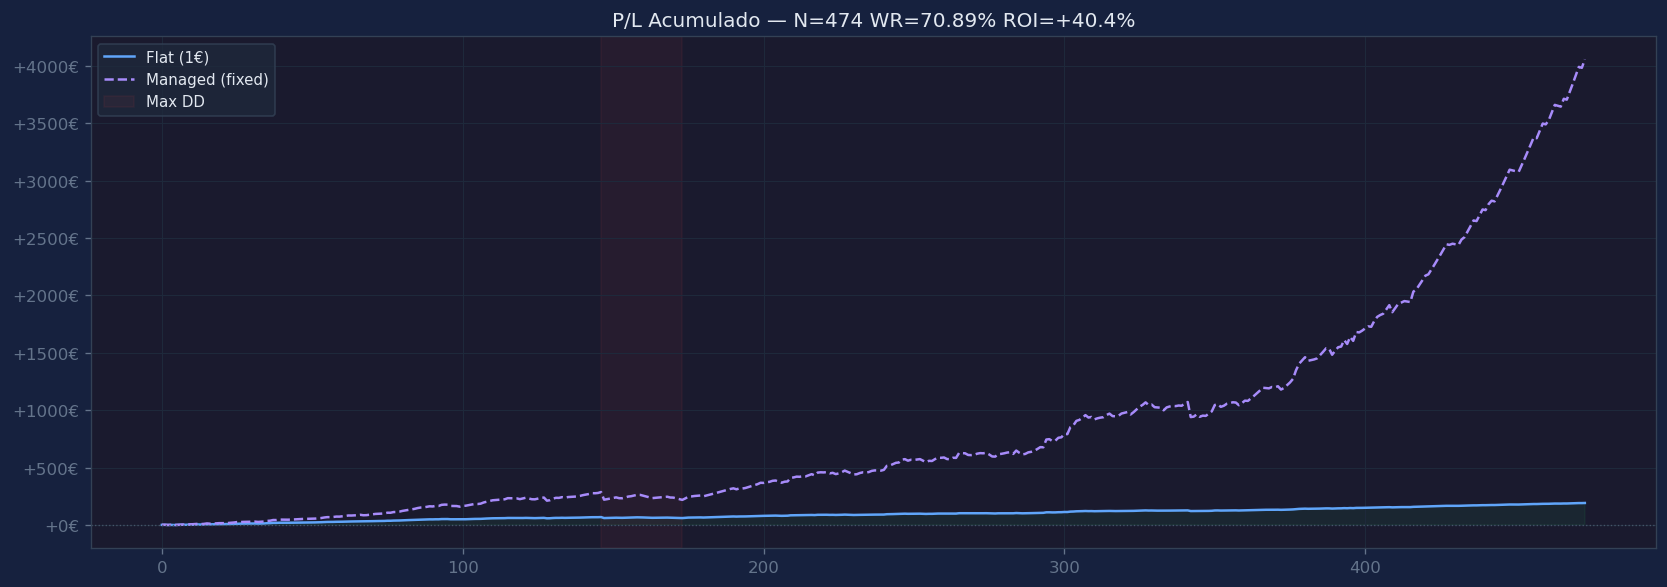

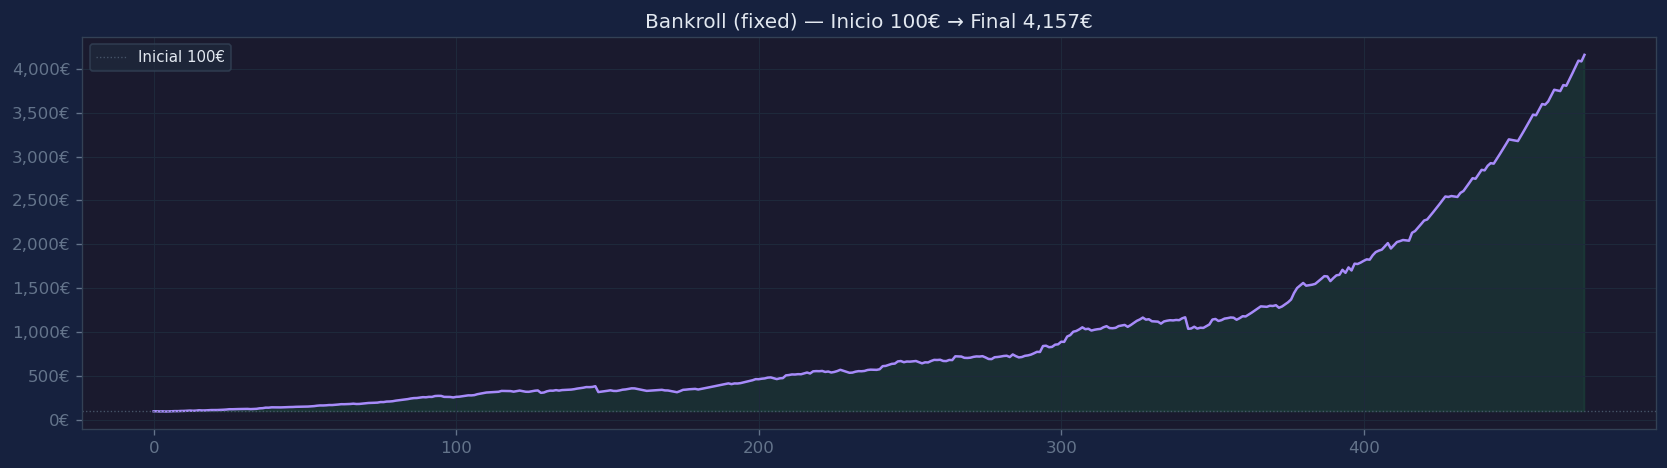

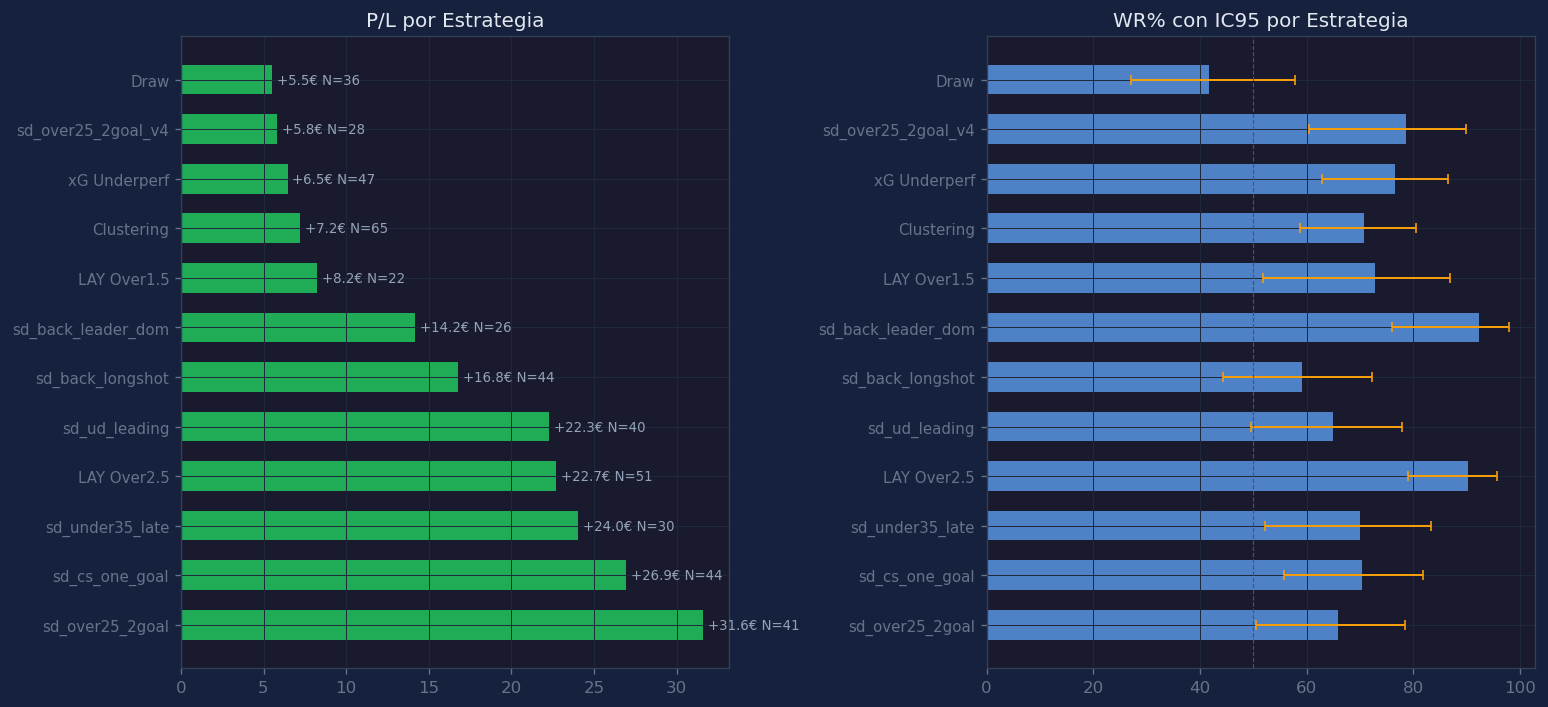

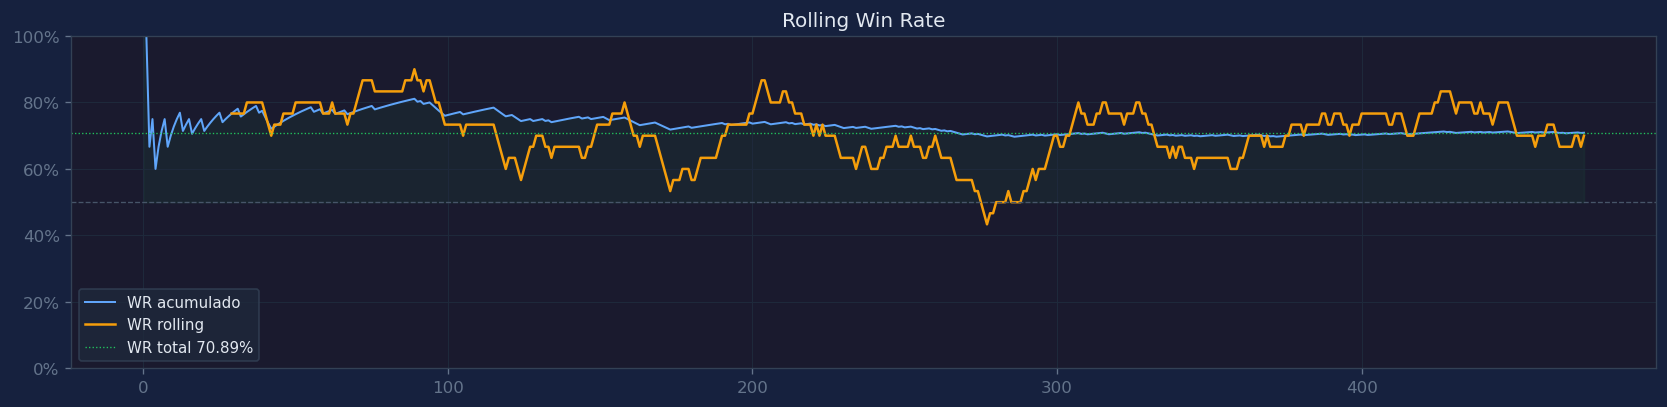

In [28]:
# ── GRÁFICOS ─────────────────────────────────────────────────────────────────
# 1. P/L Acumulado
fig, ax = plt.subplots(figsize=(14,5))
x = range(len(_sim['flat_arr']))
ax.plot(x, _sim['flat_arr'], color='#60a5fa', lw=1.5, label=f'Flat ({G_STAKE}€)')
ax.plot(x, _sim['managed_arr'], color='#a78bfa', lw=1.5, ls='--', label=f'Managed ({G_BR_MODE})')
ax.fill_between(x,_sim['flat_arr'],0, where=[v>=0 for v in _sim['flat_arr']], alpha=0.07, color='#22c55e')
ax.fill_between(x,_sim['flat_arr'],0, where=[v<0  for v in _sim['flat_arr']], alpha=0.07, color='#ef4444')
ax.axhline(0, color='#475569', lw=0.8, ls=':')
_dd=_sim['flat_dd']
if _dd['max_dd']>0: ax.axvspan(_dd['peak_idx'],_dd['trough_idx'],alpha=0.06,color='#ef4444',label=f'Max DD')
ax.set_title(f'P/L Acumulado — N={_sim["total"]} WR={_sim["win_pct"]}% ROI={_sim["flat_roi"]:+.1f}%',color='#e2e8f0')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_:f'{v:+.0f}€'))
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

# 2. Bankroll
fig,ax=plt.subplots(figsize=(14,4))
_bk=[G_BANKROLL+v for v in _sim['managed_arr']]
ax.plot(range(len(_bk)),_bk,color='#a78bfa',lw=1.5)
ax.fill_between(range(len(_bk)),_bk,G_BANKROLL,where=[v>=G_BANKROLL for v in _bk],alpha=0.12,color='#22c55e')
ax.fill_between(range(len(_bk)),_bk,G_BANKROLL,where=[v<G_BANKROLL  for v in _bk],alpha=0.12,color='#ef4444')
ax.axhline(G_BANKROLL,color='#475569',lw=0.8,ls=':',label=f'Inicial {G_BANKROLL}€')
ax.set_title(f'Bankroll ({G_BR_MODE}) — Inicio {G_BANKROLL}€ → Final {_sim["managed_final"]:,.0f}€',color='#e2e8f0')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_:f'{v:,.0f}€'))
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

# 3. P/L & WR por estrategia
if _rows_strat:
    _names=[r['Estrategia'] for r in _rows_strat]; _pls=[r['P/L'] for r in _rows_strat]
    _wrs=[r['WR%'] for r in _rows_strat]; _ns=[r['N'] for r in _rows_strat]
    fig,axes=plt.subplots(1,2,figsize=(13,max(3,len(_names)*0.5)))
    _y=range(len(_names))
    axes[0].barh(_y,_pls,color=['#22c55e' if v>=0 else '#ef4444' for v in _pls],alpha=0.85,height=0.6)
    for i,(v,n) in enumerate(zip(_pls,_ns)):
        axes[0].text(v+(0.3 if v>=0 else -0.3),i,f'{v:+.1f}€ N={n}',va='center',ha='left' if v>=0 else 'right',fontsize=8,color='#94a3b8')
    axes[0].set_yticks(_y); axes[0].set_yticklabels(_names,fontsize=9); axes[0].axvline(0,color='#475569',lw=0.7)
    axes[0].set_title('P/L por Estrategia',color='#e2e8f0')
    _ci_ls=[_wilson_ci(r['Wins'],r['N'])[0] if r['N']>=5 else 0 for r in _rows_strat]
    _ci_hs=[_wilson_ci(r['Wins'],r['N'])[1] if r['N']>=5 else 0 for r in _rows_strat]
    axes[1].barh(_y,_wrs,color='#60a5fa',alpha=0.75,height=0.6)
    axes[1].errorbar(_wrs,list(_y),xerr=[[w-cl for w,cl in zip(_wrs,_ci_ls)],[ch-w for w,ch in zip(_wrs,_ci_hs)]],
                     fmt='none',color='#f59e0b',capsize=3,lw=1.2)
    axes[1].axvline(50,color='#475569',lw=0.7,ls='--')
    axes[1].set_yticks(_y); axes[1].set_yticklabels(_names,fontsize=9)
    axes[1].set_title('WR% con IC95 por Estrategia',color='#e2e8f0')
    fig.tight_layout(); plt.show()

# 4. Rolling WR
if len(_bets_risk)>=10:
    _w=[int(bool(b.get('won'))) for b in _bets_risk]
    _cum=[_r2(sum(_w[:i+1])/(i+1)*100) for i in range(len(_w))]
    _roll=pd.Series(_w).rolling(min(30,len(_w)//3)).mean()*100
    fig,ax=plt.subplots(figsize=(14,3.5))
    ax.plot(_cum,color='#60a5fa',lw=1.2,label='WR acumulado')
    ax.plot(_roll,color='#f59e0b',lw=1.5,label=f'WR rolling')
    ax.axhline(50,color='#475569',lw=0.8,ls='--')
    ax.axhline(_sim['win_pct'],color='#22c55e',lw=0.8,ls=':',label=f'WR total {_sim["win_pct"]}%')
    ax.fill_between(range(len(_cum)),_cum,50,where=[v>=50 for v in _cum],alpha=0.06,color='#22c55e')
    ax.fill_between(range(len(_cum)),_cum,50,where=[v<50  for v in _cum],alpha=0.06,color='#ef4444')
    ax.set_ylim(0,100); ax.set_title('Rolling Win Rate',color='#e2e8f0')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_:f'{v:.0f}%'))
    ax.legend(fontsize=9); fig.tight_layout(); plt.show()

### #29 — Historial Detallado de Apuestas

**Que hace**: Construye y renderiza una tabla HTML con el detalle de cada apuesta: fecha, estrategia, tipo (LAY/BACK), partido, minuto de entrada, P/L de la apuesta y P/L acumulado. Util para auditar apuestas individuales o buscar patrones concretos.

**Output esperado**: _(tabla HTML con ~359 filas — visible en el notebook)_

---

### 📋 Historial de apuestas
> Tabla detallada de cada apuesta individual con resultado, estrategia y P/L acumulado

In [29]:
# ── HISTORIAL DE APUESTAS ────────────────────────────────────────────────────
_cum=0.; _rows=[]
for i,b in enumerate(_bets_risk,1):
    pl=float(b.get('pl') or 0)*G_STAKE/10; _cum=_r2(_cum+pl)
    _rows.append({'#':i,'Fecha':(b.get('timestamp_utc') or '')[:16].replace('T',' '),
        'Estrategia':_STRAT_LABELS.get(b.get('strategy',''),b.get('strategy','')),
        'Tipo':'LAY' if b.get('bet_type_dir')=='lay' else 'BACK',
        'Partido':(b.get('match_id') or '')[:35],'Min':b.get('minuto'),
        'Score':b.get('score') or b.get('score_trigger') or '','FT':b.get('ft_score') or b.get('ft_result') or '',
        'Won':'✓' if b.get('won') else '✗','Odds':f'{_get_bet_odds(b):.2f}',
        'P/L':f'{pl:+.2f}€','Acum.':f'{_cum:+.2f}€','Riesgo':b.get('risk_level') or 'none'})

_show_table(pd.DataFrame(_rows), f'Historial — {len(_rows)} apuestas')

#,Fecha,Estrategia,Tipo,Partido,Min,Score,FT,Won,Odds,P/L,Acum.,Riesgo
1,,sd_ud_leading,BACK,lan%C3%BAs-flamengo-apuestas-350731,76.000000,,,✓,2.00,+0.91€,+0.91€,none
2,2026-02-10 20:56,sd_back_leader_dom,BACK,tottenham-newcastle-apuestas-352121,62.000000,,,✓,1.31,+0.27€,+1.18€,none
3,2026-02-12 20:50,xG Underperf,BACK,atlético-de-madrid-fc-barcelona-apu,45.000000,,4-0,✗,1.42,-1.00€,+0.18€,none
4,2026-02-12 21:26,xG Underperf,BACK,brentford-arsenal-apuestas-35212180,68.000000,,1-1,✓,1.64,+0.58€,+0.76€,none
5,2026-02-12 23:06,Draw,BACK,fluminense-botafogo-fr-apuestas-352,32.000000,,1-0,✗,2.68,-1.00€,-0.24€,none
6,2026-02-13 00:06,LAY Over2.5,LAY,fluminense-botafogo-fr-apuestas-352,70.000000,1-0,1-0,✓,8.80,+0.95€,+0.71€,none
7,2026-02-13 00:32,xG Underperf,BACK,corinthians-red-bull-bragantino-apu,64.000000,,2-0,✓,1.69,+0.63€,+1.34€,none
8,2026-02-13 00:33,Clustering,BACK,corinthians-red-bull-bragantino-apu,62.000000,1-0,2-0,✓,1.67,+0.61€,+1.95€,none
9,2026-02-13 00:44,sd_over25_2goal,BACK,corinthians-red-bull-bragantino-apu,76.000000,,,✗,2.00,-0.10€,+1.85€,none
10,2026-02-13 19:05,LAY Over2.5,LAY,fortuna-dusseldorf-preussen-munster,72.000000,0-0,0-0,✓,2.16,+0.95€,+2.80€,none


### #30 — CO Optimizer (Evaluador de Cashout)

**Que hace**: Evalua todas las modalidades de cashout: Sin CO, Gol Adverso, Fijo % (5/10/15/20%), Trailing, y combinaciones. Para cada una calcula impacto neto (WC perdidos − LS ahorrados). Selecciona la mejor segun `CO_CRITERION`. Guarda en `G_CO_CONFIG` y `G_CO_LABEL`.

**Output esperado**: Tabla con neto de cada modalidad + `El ganador es: "Sin CO"` (o el mejor si hay mejora real).

---

### 💰 CO Optimizer — selección automática del mejor mecanismo de cashout
> Testa **todas** las modalidades disponibles (odds-based, gol adverso, trailing, combinaciones)
> y elige automáticamente la que maximiza el P/L neto vs sin CO.
> **El resultado puede cambiar con más datos** — no hay nada hardcodeado.

Evaluando configuraciones CO...
  Sin CO                         net=  +0.00€  WC=0 LS=0  ratio=inf
  Gol Adverso                    net=-128.36€  WC=7 LS=20  ratio=0.35
  Trailing 10%                   net=-109.18€  WC=57 LS=51  ratio=1.12
  Trailing 15%                   net=-110.36€  WC=49 LS=51  ratio=0.96
  Trailing 20%                   net=-111.87€  WC=39 LS=49  ratio=0.8
  Trailing 25%                   net=-116.56€  WC=34 LS=47  ratio=0.72
  Fijo 10%                       net=-106.92€  WC=74 LS=56  ratio=1.32
  Fijo 20%                       net=-112.00€  WC=48 LS=51  ratio=0.94
  Fijo 30%                       net=-114.90€  WC=41 LS=50  ratio=0.82
  GolAdv + Trailing 15%          net=-105.62€  WC=49 LS=52  ratio=0.94
  GolAdv + Trailing 20%          net=-107.04€  WC=39 LS=50  ratio=0.78
  GolAdv + Fijo 20%              net=-106.72€  WC=48 LS=52  ratio=0.92
  GolAdv + Fijo 30%              net=-109.60€  WC=41 LS=51  ratio=0.8

──────────────────────────────────────────────────

Configuración,CO%,WC,LS,Ratio WC/LS,Net dP/L,P/L Total,ROI%,Max DD
Sin CO,0.000000,0,0,inf,+0.00,+191.63,+40.4,8.74
GolAdv + Trailing 15%,21.300000,49,52,0.940000,-105.62,+86.01,+38.9,8.60
GolAdv + Fijo 20%,21.100000,48,52,0.920000,-106.72,+84.91,+38.4,8.60
Fijo 10%,27.400000,74,56,1.320000,-106.92,+84.71,+38.3,8.60
GolAdv + Trailing 20%,18.800000,39,50,0.780000,-107.04,+84.59,+38.3,8.60
Trailing 10%,22.800000,57,51,1.120000,-109.18,+82.45,+37.3,8.60
GolAdv + Fijo 30%,19.400000,41,51,0.800000,-109.60,+82.03,+37.1,8.75
Trailing 15%,21.100000,49,51,0.960000,-110.36,+81.27,+36.8,8.60
Trailing 20%,18.600000,39,49,0.800000,-111.87,+79.76,+36.1,8.60
Fijo 20%,20.900000,48,51,0.940000,-112.00,+79.63,+36.0,8.60


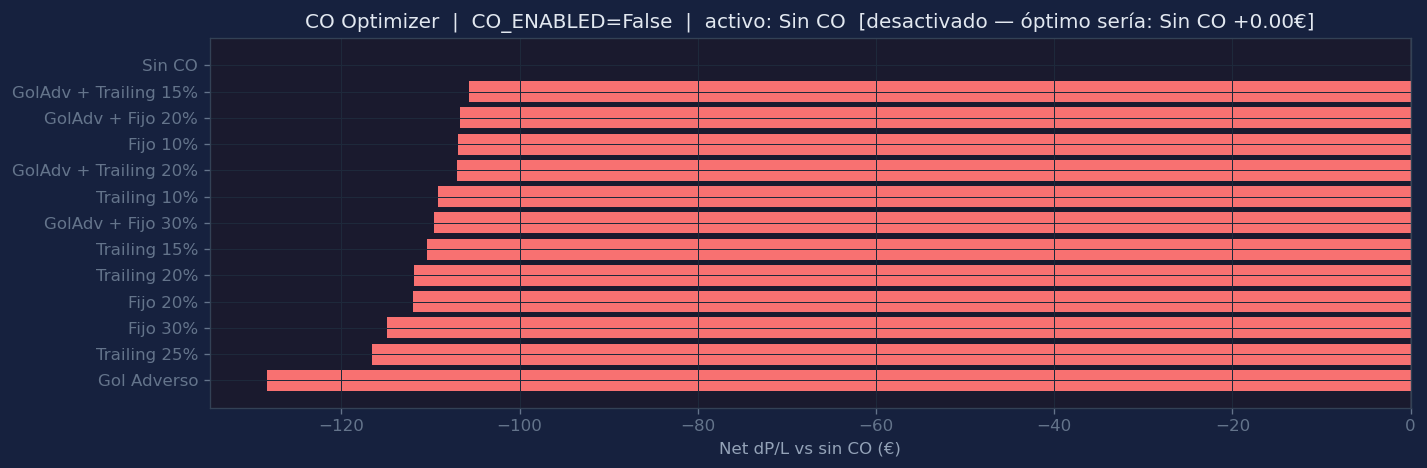

In [30]:
# ── CO OPTIMIZER ─────────────────────────────────────────────────────────────
# Evalúa todas las modalidades de cashout disponibles y elige la óptima
# automáticamente según los datos. No hay nada hardcodeado: con más histórico
# el ganador puede cambiar.
#
# CO_ENABLED:   False = desactivar CO aunque el optimizer encuentre ganador
#               True  = aplicar la config ganadora a G_CO_CONFIG
#
# CO_CRITERION:
#   'net_pl'    → maximiza P/L neto ganado respecto a sin CO  (default)
#   'pl_total'  → maximiza P/L total absoluto
#   'ratio'     → minimiza ratio ganadoras_cortadas / perdedoras_salvadas
# ─────────────────────────────────────────────────────────────────────────────
CO_ENABLED   = False   # ← cambiar a True cuando haya muestra suficiente (~1000 bets)
CO_CRITERION = 'net_pl'

# Catálogo de configuraciones a comparar. Añade aquí nuevas combinaciones si
# simulate_cashout_cartera incorpora nuevos modos en el futuro.
_CO_CANDIDATES = [
    {'label': 'Sin CO',                'kwargs': {}},
    {'label': 'Gol Adverso',           'kwargs': {'adverse_goal_stop': True}},
    {'label': 'Trailing 10%',          'kwargs': {'trailing_stop_pct': 10}},
    {'label': 'Trailing 15%',          'kwargs': {'trailing_stop_pct': 15}},
    {'label': 'Trailing 20%',          'kwargs': {'trailing_stop_pct': 20}},
    {'label': 'Trailing 25%',          'kwargs': {'trailing_stop_pct': 25}},
    {'label': 'Fijo 10%',              'kwargs': {'cashout_lay_pct': 10}},
    {'label': 'Fijo 20%',              'kwargs': {'cashout_lay_pct': 20}},
    {'label': 'Fijo 30%',              'kwargs': {'cashout_lay_pct': 30}},
    {'label': 'GolAdv + Trailing 15%', 'kwargs': {'adverse_goal_stop': True, 'trailing_stop_pct': 15}},
    {'label': 'GolAdv + Trailing 20%', 'kwargs': {'adverse_goal_stop': True, 'trailing_stop_pct': 20}},
    {'label': 'GolAdv + Fijo 20%',     'kwargs': {'adverse_goal_stop': True, 'cashout_lay_pct': 20}},
    {'label': 'GolAdv + Fijo 30%',     'kwargs': {'adverse_goal_stop': True, 'cashout_lay_pct': 30}},
]

# ── Helpers compartidos con la celda de diagnóstico ──────────────────────────
_ids           = {(b.get('match_id'), b.get('strategy')) for b in _bets_risk}
_base_map      = {(b.get('match_id'), b.get('strategy')): b for b in _cartera_data.get('bets', [])}
_n_total       = len(_bets_risk)
_BASE_PL_TOTAL = _sim_full(_bets_risk)['flat_pl']  # baseline sin CO (escala G_STAKE)

def _filter_co(raw):
    """Filtra y ordena las bets de un resultado de simulate_cashout_cartera."""
    bets = [b for b in raw.get('bets', []) if (b.get('match_id'), b.get('strategy')) in _ids]
    bets = _apply_realistic_adj(bets, G_ADJ)
    bets = _filter_by_risk(bets, G_RISK)
    bets.sort(key=lambda b: b.get('timestamp_utc') or '')
    return bets

def _co_eval(kwargs):
    """Evalúa una config CO vs sin CO. Devuelve dict con métricas comparativas.

    ESCALA: net_pl, pl_total, wc_dpl y ls_dpl están todos a escala G_STAKE
    (consistente con _sim_full). simulate_cashout_cartera usa stake=10 internamente;
    se escala multiplicando por G_STAKE/10.
    """
    _scale = G_STAKE / 10.0   # stake interno (10) → G_STAKE

    if not kwargs:
        _s = _sim_full(_bets_risk)
        return {'co_triggered': 0, 'penetracion_pct': 0.0,
                'winners_cut': 0, 'losers_saved': 0, 'ratio': float('inf'),
                'wc_dpl': 0.0, 'ls_dpl': 0.0, 'net_pl': 0.0,
                'pl_total': _s['flat_pl'], 'roi': _s['flat_roi'],
                'max_dd': _s['flat_dd']['max_dd']}

    co_raw = csv_reader.simulate_cashout_cartera(_cartera_data, **kwargs)

    co_triggered = winners_cut = losers_saved = 0
    wc_dpl = ls_dpl = 0.0
    co_bets = []

    for co_b in co_raw.get('bets', []):
        key = (co_b.get('match_id'), co_b.get('strategy'))
        if key not in _ids:
            continue
        base_b = _base_map.get(key)
        if not base_b:
            continue
        co_bets.append(co_b)
        if co_b.get('cashout_applied'):
            co_triggered += 1
            dpl_raw = co_b.get('pl', 0) - base_b.get('pl', 0)  # stake=10 bruto
            if base_b.get('won'):
                winners_cut += 1; wc_dpl += dpl_raw * _scale
            else:
                losers_saved += 1; ls_dpl += dpl_raw * _scale

    co_bets = _apply_realistic_adj(co_bets, G_ADJ)
    co_bets = _filter_by_risk(co_bets, G_RISK)
    co_bets.sort(key=lambda b: b.get('timestamp_utc') or '')
    s = _sim_full(co_bets) if co_bets else {'flat_pl': 0, 'flat_roi': 0, 'flat_dd': {'max_dd': 0}}

    # net_pl: diferencia P/L total CO vs sin CO (escala G_STAKE, consistente con pl_total)
    net_pl = round(s['flat_pl'] - _BASE_PL_TOTAL, 2)

    return {'co_triggered': co_triggered,
            'penetracion_pct': round(co_triggered / _n_total * 100, 1),
            'winners_cut': winners_cut, 'losers_saved': losers_saved,
            'ratio': round(winners_cut / losers_saved, 2) if losers_saved else float('inf'),
            'wc_dpl': round(wc_dpl, 2), 'ls_dpl': round(ls_dpl, 2),
            'net_pl': net_pl,
            'pl_total': s['flat_pl'], 'roi': s['flat_roi'],
            'max_dd': s['flat_dd']['max_dd']}

# ── Evaluar todos los candidatos ──────────────────────────────────────────────
print('Evaluando configuraciones CO...')
_co_results = []
for cfg in _CO_CANDIDATES:
    print(f'  {cfg["label"]:30s}', end=' ', flush=True)
    r = _co_eval(cfg['kwargs'])
    _co_results.append({**r, 'label': cfg['label'], 'kwargs': cfg['kwargs']})
    wc_ls = f'WC={r["winners_cut"]} LS={r["losers_saved"]}'
    print(f'net={r["net_pl"]:+7.2f}€  {wc_ls}  ratio={r["ratio"]}')

# ── Auto-selección según criterio ─────────────────────────────────────────────
_sort_key = {'net_pl': ('net_pl', max), 'pl_total': ('pl_total', max), 'ratio': ('ratio', min)}
_key, _fn  = _sort_key.get(CO_CRITERION, ('net_pl', max))
_optimal   = _fn(_co_results, key=lambda x: x[_key])

# ── Aplicar CO_ENABLED ────────────────────────────────────────────────────────
if CO_ENABLED:
    G_CO_CONFIG = _optimal['kwargs']
    G_CO_LABEL  = _optimal['label']
else:
    G_CO_CONFIG = {}
    G_CO_LABEL  = f'Sin CO  [desactivado — óptimo sería: {_optimal["label"]} +{_optimal["net_pl"]:.2f}€]'

print(f'\n{"─"*60}')
print(f'  CO_ENABLED = {CO_ENABLED}')
print(f'  RESULTADO:  {G_CO_LABEL}')
print(f'  G_CO_CONFIG = {G_CO_CONFIG}')
if CO_ENABLED:
    print(f'  net dP/L = {_optimal["net_pl"]:+.2f}€  |  P/L total = {_optimal["pl_total"]:+.2f}€  |  ROI = {_optimal["roi"]:+.1f}%')
    print(f'  Ganadoras cortadas: {_optimal["winners_cut"]}  |  Perdedoras salvadas: {_optimal["losers_saved"]}  |  ratio: {_optimal["ratio"]}')
else:
    print(f'  P/L total sin CO = {_BASE_PL_TOTAL:+.2f}€')
print(f'{"─"*60}')

# ── Tabla comparativa completa (ordenada por net_pl desc) ─────────────────────
_cmp_df = pd.DataFrame([{
    'Configuración':   r['label'],
    'CO%':             r['penetracion_pct'],
    'WC':              r['winners_cut'],
    'LS':              r['losers_saved'],
    'Ratio WC/LS':     r['ratio'],
    'Net dP/L':        r['net_pl'],
    'P/L Total':       r['pl_total'],
    'ROI%':            r['roi'],
    'Max DD':          r['max_dd'],
} for r in sorted(_co_results, key=lambda x: -x['net_pl'])])

_show_table(_cmp_df, f'CO Optimizer — ordenado por net dP/L | CO_ENABLED={CO_ENABLED} | activo: {G_CO_LABEL}')

# ── Gráfico: net dP/L por configuración ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
_labels = [r['label'] for r in sorted(_co_results, key=lambda x: -x['net_pl'])]
_vals   = [r['net_pl'] for r in sorted(_co_results, key=lambda x: -x['net_pl'])]
_cols   = ['#4ade80' if v > 0 else '#f87171' for v in _vals]
ax.barh(_labels[::-1], _vals[::-1], color=_cols[::-1])
ax.axvline(0, color='#94a3b8', lw=0.8)
ax.set_xlabel('Net dP/L vs sin CO (€)')
ax.set_title(f'CO Optimizer  |  CO_ENABLED={CO_ENABLED}  |  activo: {G_CO_LABEL}', color='#e2e8f0')
plt.tight_layout(); plt.show()


### #31 — Diagnostico del CO Ganador por Estrategia

**Que hace**: Desglosa el impacto del CO ganador por estrategia: cuantas apuestas ganadoras se cortaron prematuramente (WC, dinero dejado en mesa) y cuantas perdedoras se salvaron (LS, dinero ahorrado). Si el ganador es "Sin CO", muestra que CO seria el optimo teorico y por que no se activo.

**Output esperado**: `El ganador es "Sin CO"` con nota del optimo teorico y tabla WC/LS por estrategia.

---

### 🔬 Diagnóstico del CO ganador
> Desglosa por estrategia cuántas ganadoras se cortaron y cuántas perdedoras se salvaron con `G_CO_CONFIG`.

In [31]:
# ── DIAGNÓSTICO CO GANADOR ────────────────────────────────────────────────────
# Desglosa el impacto de G_CO_CONFIG por estrategia.
# Si G_CO_CONFIG es vacío (sin CO = ganador), imprime que no hay CO.
# ---------------------------------------------------------------------------

if not G_CO_CONFIG:
    print(f'El ganador es "Sin CO" ({G_CO_LABEL}) — no hay mecanismo de cashout activo.')
    print('La cartera se deja correr hasta el resultado final en todas las estrategias.')
else:
    print(f'Configuración ganadora: {G_CO_LABEL}')
    print(f'Parámetros: {G_CO_CONFIG}\n')

    co_raw    = csv_reader.simulate_cashout_cartera(_cartera_data, **G_CO_CONFIG)
    co_bets   = _filter_co(co_raw)
    triggered = [b for b in co_bets if b.get('cashout_applied')]
    co_win    = [b for b in triggered if b.get('won')]
    co_los    = [b for b in triggered if not b.get('won')]

    print(f'{"─"*55}')
    print(f'  PENETRACIÓN')
    print(f'{"─"*55}')
    print(f'  Bets en cartera:       {len(co_bets)}')
    print(f'  CO disparado:          {len(triggered)}  ({len(triggered)/len(co_bets)*100:.1f}%)')
    print(f'    Ganadoras cortadas:  {len(co_win)}{"  ⚠️" if co_win else "  ✓"}')
    print(f'    Perdedoras salvadas: {len(co_los)}')

    if co_los:
        # Escalar de stake=10 (backend) a G_STAKE para mostrar en la escala del usuario
        _scale = G_STAKE / 10.0
        avg_co_raw   = sum(b['pl'] for b in co_los) / len(co_los)
        avg_base_raw = sum(
            _base_map.get((b.get('match_id'), b.get('strategy')), {}).get('pl', -10.0)
            for b in co_los
        ) / len(co_los)
        avg_co   = avg_co_raw   * _scale   # pérdida media con CO (G_STAKE)
        avg_base = avg_base_raw * _scale   # pérdida media sin CO (G_STAKE)
        saving   = avg_co - avg_base       # ahorro por bet (positivo = CO ayuda)
        print(f'\n  Pérdida media con CO:    {avg_co:+.2f}€')
        print(f'  Pérdida media sin CO:    {avg_base:+.2f}€')
        print(f'  Ahorro medio (por bet):  {saving:+.2f}€  ({saving/G_STAKE*100:+.0f}% del stake)')
        print(f'  Ahorro total:            {saving*len(co_los):+.2f}€')

    # Breakdown por estrategia
    from collections import defaultdict
    _by = defaultdict(lambda: {'total': 0, 'co': 0, 'wc': 0, 'ls': 0, 'net_dpl': 0.0})
    _scale = G_STAKE / 10.0
    for co_b in co_bets:
        s   = co_b.get('strategy', '?')
        key = (co_b.get('match_id'), s)
        bb  = _base_map.get(key)
        _by[s]['total'] += 1
        if co_b.get('cashout_applied') and bb:
            _by[s]['co'] += 1
            dpl = (co_b.get('pl', 0) - bb.get('pl', 0)) * _scale
            _by[s]['net_dpl'] += dpl
            if bb.get('won'): _by[s]['wc'] += 1
            else:             _by[s]['ls'] += 1

    _rows = [{'Estrategia': s, 'Total': d['total'], 'CO disp.': d['co'],
              'Ganadoras cortadas': d['wc'], 'Perdedoras salvadas': d['ls'],
              'Net dP/L': round(d['net_dpl'], 2)}
             for s, d in sorted(_by.items(), key=lambda x: -abs(x[1]['net_dpl']))]
    print()
    _show_table(pd.DataFrame(_rows), f'Desglose por estrategia — {G_CO_LABEL}')


El ganador es "Sin CO" (Sin CO  [desactivado — óptimo sería: Sin CO +0.00€]) — no hay mecanismo de cashout activo.
La cartera se deja correr hasta el resultado final en todas las estrategias.


## 🎯 Presets / Optimizador Completo

In [32]:
# ── Params optimizados por celdas individuales → propagados al preset ─────────
# Las celdas opt-simple-lays (#14) producen CFG_* con los params óptimos para
# cada estrategia on/off. Los pasamos al optimizer para que _build_preset_config()
# los use en vez de hardcodear defaults.
_STRATEGY_PARAMS = {}
if isinstance(CFG_LAY25, dict):
    _STRATEGY_PARAMS["lay_over25_def"] = CFG_LAY25
if isinstance(CFG_LAY_DRAW, dict):
    _STRATEGY_PARAMS["lay_draw_asym"] = CFG_LAY_DRAW
if isinstance(CFG_BACK_SOT, dict):
    _STRATEGY_PARAMS["back_sot_dom"] = CFG_BACK_SOT
if isinstance(CFG_BACK_O15E, dict):
    _STRATEGY_PARAMS["back_over15_early"] = CFG_BACK_O15E
if isinstance(CFG_LAY_FAV, dict):
    _STRATEGY_PARAMS["lay_false_fav"] = CFG_LAY_FAV

if _STRATEGY_PARAMS:
    print(f"Strategy params para preset: {list(_STRATEGY_PARAMS.keys())}")
    for k, v in _STRATEGY_PARAMS.items():
        print(f"  {k}: {v}")
else:
    print("Sin strategy params (todas las estrategias on/off = off)")

Strategy params para preset: ['lay_over25_def']
  lay_over25_def: {'xg_max': 2.0, 'goals_max': 1, 'm_min': 65, 'm_max': 80}


### #32 — Preset max_roi (Optimizador 4 Fases)

**Que hace**: Lanza el optimizador completo de 4 fases con criterio `max_roi` (mayor ROI por apuesta). Fase 1: mejor combinacion de versiones + bankroll mode. Fase 2: ajustes realistas (G_ADJ). Fase 2.5: desactiva estrategias que dañan el criterio. Fase 3: afina rangos de minutos. Puede tardar varios minutos con n_workers>1.

**Output esperado**: Log por fases + `✓ Preset max_roi guardado: N=X WR=Y% ROI=Z%`

---

### ▶️ Preset `max_roi` — Mayor ROI por apuesta
> Eficiencia máxima: la versión con mejor retorno por euro apostado · buen equilibrio entre volumen y rendimiento

In [33]:
# ── Preset: max_roi — Mayor ROI por apuesta ───────────────────────────
_CRITERION   = 'max_roi'
_preset_path = _presets_dir / f'preset_{_CRITERION}_config.json'

if RECALCULAR_PRESETS:
    print(f'{"═"*60}')
    print(f'  Generando preset: {_CRITERION}  (workers={_PRESET_WORKERS})')
    print(f'{"═"*60}')
    _t0 = datetime.now()
    _result = _opt_cli.run(criterion=_CRITERION, bankroll_init=float(_PRESET_BANKROLL),
                           n_workers=_PRESET_WORKERS, adj_override=G_ADJ,
                            strategy_params=_STRATEGY_PARAMS)
    _elapsed = (datetime.now() - _t0).seconds
    print(f'  ✓ {_elapsed}s')
    if _result.get('n_bets'):
        _cl, _ch = _wilson_ci(_result.get('wins', 0), _result.get('n_bets', 1))
        print(f'  N={_result["n_bets"]}  WR={_result["win_pct"]}%'
              f'  IC95=[{_cl}–{_ch}%]  ROI={_result["flat_roi"]}%  P/L={_result["flat_pl"]:.2f}€')
    if _result.get('csv_path'):    print(f'  CSV    → {_result["csv_path"]}')
    if _result.get('config_path'): print(f'  Config → {_result["config_path"]}')
    # Guardar n_partidos para comparación futura
    if _result.get('config_path') and Path(_result['config_path']).exists():
        _cfg = json.loads(Path(_result['config_path']).read_text(encoding='utf-8'))
        _cfg.setdefault('_optimizer_stats', {})['n_partidos'] = \
            len({b.get('match_id') for b in _ALL_BETS if b.get('match_id')})
        Path(_result['config_path']).write_text(
            json.dumps(_cfg, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'  Ejecuta la celda "Comparar todos" para ver el ganador.')

else:
    _n_now = len({b.get('match_id') for b in _ALL_BETS if b.get('match_id')})
    if _preset_path.exists():
        _cached = json.loads(_preset_path.read_text(encoding='utf-8'))
        _s = _cached.get('_optimizer_stats', {})
        _pl_str = f'  P/L={_s["pl"]:.2f}€' if isinstance(_s.get('pl'), (int, float)) else ''
        print(f'  ✓ Preset {_CRITERION} — cargado desde disco  (RECALCULAR_PRESETS=False)')
        print(f'    N={_s.get("n","?")} bets  WR={_s.get("wr","?")}%  '
              f'ROI={_s.get("roi","?")}%{_pl_str}')
        _n_opt = _s.get('n_partidos')
        if _n_opt:
            _delta = _n_now - int(_n_opt)
            _pct   = (_n_now / int(_n_opt) - 1) * 100
            _warn  = '  ⚠  Considera RECALCULAR_PRESETS=True' if _pct >= 20 else ''
            print(f'    Partidos al optimizar: {_n_opt}  →  Ahora: {_n_now} (+{_delta}, +{_pct:.0f}%){_warn}')
        else:
            print(f'    Partidos actuales: {_n_now}  '
                  f'(ejecuta con RECALCULAR_PRESETS=True para registrar el baseline)')
    else:
        print(f'  ⚠  Preset {_CRITERION} no encontrado en disco.')
        print(f'     → Cambia RECALCULAR_PRESETS=True en celda #4 y ejecuta de nuevo.')


════════════════════════════════════════════════════════════
  Generando preset: max_roi  (workers=10)
════════════════════════════════════════════════════════════
[19:34:34] Iniciando optimizador — criterio=max_roi bankroll=1000.0 workers=10
[19:34:34] adj_override activo: {'dedup': True, 'minOdds': 1.21, 'maxOdds': 10.0, 'driftMinMinute': 0, 'slippagePct': 2, 'conflictFilter': False, 'allowContrarias': True, 'minStability': 2, 'globalMinuteMin': None, 'globalMinuteMax': None}
[19:34:34] Cargando datos desde CSV…
[19:34:34] Datos cargados en 0.0s — 2521 bets
[19:34:34] Phase 1 — 12,386,304 combos en 10 workers (split por 24 pares draw×xg)…
[19:45:59]   Worker 10/10 terminado — score=17.4100  (1/10 listos)
[19:45:59]   Worker 6/10 terminado — score=19.1500  (2/10 listos)
[19:46:09]   Worker 9/10 terminado — score=17.3300  (3/10 listos)
[19:46:09]   Worker 5/10 terminado — score=19.5500  (4/10 listos)
[19:46:22]   Worker 8/10 terminado — score=15.2900  (5/10 listos)
[19:46:34]   Worker 

### #33 — Preset max_pl (Optimizador 4 Fases)

**Que hace**: Mismo optimizador con criterio `max_pl` (mayor P/L total). Produce mas apuestas y mayor ganancia absoluta que max_roi, a costa de ROI ligeramente menor. **Este es el preset activo actualmente en produccion.**

**Output esperado**: Log por fases + `✓ Preset max_pl guardado: N=183 WR=69.9% ROI=39.82%`

---

### ▶️ Preset `max_pl` — Mayor P/L total
> Máxima ganancia absoluta: optimiza el beneficio neto total aunque el ROI% sea más bajo · más apuestas, más volumen

In [34]:
# ── Preset: max_pl — Mayor P/L total ──────────────────────────────────
_CRITERION   = 'max_pl'
_preset_path = _presets_dir / f'preset_{_CRITERION}_config.json'

if RECALCULAR_PRESETS:
    print(f'{"═"*60}')
    print(f'  Generando preset: {_CRITERION}  (workers={_PRESET_WORKERS})')
    print(f'{"═"*60}')
    _t0 = datetime.now()
    _result = _opt_cli.run(criterion=_CRITERION, bankroll_init=float(_PRESET_BANKROLL),
                           n_workers=_PRESET_WORKERS, adj_override=G_ADJ,
                            strategy_params=_STRATEGY_PARAMS)
    _elapsed = (datetime.now() - _t0).seconds
    print(f'  ✓ {_elapsed}s')
    if _result.get('n_bets'):
        _cl, _ch = _wilson_ci(_result.get('wins', 0), _result.get('n_bets', 1))
        print(f'  N={_result["n_bets"]}  WR={_result["win_pct"]}%'
              f'  IC95=[{_cl}–{_ch}%]  ROI={_result["flat_roi"]}%  P/L={_result["flat_pl"]:.2f}€')
    if _result.get('csv_path'):    print(f'  CSV    → {_result["csv_path"]}')
    if _result.get('config_path'): print(f'  Config → {_result["config_path"]}')
    # Guardar n_partidos para comparación futura
    if _result.get('config_path') and Path(_result['config_path']).exists():
        _cfg = json.loads(Path(_result['config_path']).read_text(encoding='utf-8'))
        _cfg.setdefault('_optimizer_stats', {})['n_partidos'] = \
            len({b.get('match_id') for b in _ALL_BETS if b.get('match_id')})
        Path(_result['config_path']).write_text(
            json.dumps(_cfg, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'  Ejecuta la celda "Comparar todos" para ver el ganador.')

else:
    _n_now = len({b.get('match_id') for b in _ALL_BETS if b.get('match_id')})
    if _preset_path.exists():
        _cached = json.loads(_preset_path.read_text(encoding='utf-8'))
        _s = _cached.get('_optimizer_stats', {})
        _pl_str = f'  P/L={_s["pl"]:.2f}€' if isinstance(_s.get('pl'), (int, float)) else ''
        print(f'  ✓ Preset {_CRITERION} — cargado desde disco  (RECALCULAR_PRESETS=False)')
        print(f'    N={_s.get("n","?")} bets  WR={_s.get("wr","?")}%  '
              f'ROI={_s.get("roi","?")}%{_pl_str}')
        _n_opt = _s.get('n_partidos')
        if _n_opt:
            _delta = _n_now - int(_n_opt)
            _pct   = (_n_now / int(_n_opt) - 1) * 100
            _warn  = '  ⚠  Considera RECALCULAR_PRESETS=True' if _pct >= 20 else ''
            print(f'    Partidos al optimizar: {_n_opt}  →  Ahora: {_n_now} (+{_delta}, +{_pct:.0f}%){_warn}')
        else:
            print(f'    Partidos actuales: {_n_now}  '
                  f'(ejecuta con RECALCULAR_PRESETS=True para registrar el baseline)')
    else:
        print(f'  ⚠  Preset {_CRITERION} no encontrado en disco.')
        print(f'     → Cambia RECALCULAR_PRESETS=True en celda #4 y ejecuta de nuevo.')


════════════════════════════════════════════════════════════
  Generando preset: max_pl  (workers=10)
════════════════════════════════════════════════════════════
[19:50:12] Iniciando optimizador — criterio=max_pl bankroll=1000.0 workers=10
[19:50:12] adj_override activo: {'dedup': True, 'minOdds': 1.21, 'maxOdds': 10.0, 'driftMinMinute': 0, 'slippagePct': 2, 'conflictFilter': False, 'allowContrarias': True, 'minStability': 2, 'globalMinuteMin': None, 'globalMinuteMax': None}
[19:50:12] Cargando datos desde CSV…
[19:50:12] Datos cargados en 0.0s — 2521 bets
[19:50:12] Phase 1 — 12,386,304 combos en 10 workers (split por 24 pares draw×xg)…
[20:02:42]   Worker 10/10 terminado — score=928.8800  (1/10 listos)
[20:02:51]   Worker 6/10 terminado — score=942.5300  (2/10 listos)
[20:02:58]   Worker 9/10 terminado — score=939.1500  (3/10 listos)
[20:03:02]   Worker 5/10 terminado — score=979.0500  (4/10 listos)
[20:03:06]   Worker 8/10 terminado — score=853.1100  (5/10 listos)
[20:03:25]   Work

### #34 — Preset max_wr (Optimizador 4 Fases)

**Que hace**: Mismo optimizador con criterio `max_wr` (mayor Win Rate). Mas selectivo, menos apuestas pero mayor % de aciertos. Penaliza P/L absoluto en favor de selectividad.

**Output esperado**: Log por fases + `✓ Preset max_wr guardado: N=X WR=Y%`

---

### ▶️ Preset `max_wr` — Mayor Win Rate
> Máxima tasa de acierto: prioriza estrategias con el WR más alto demostrado estadísticamente · menos apuestas, más selectivo

In [35]:
# ── Preset: max_wr — Mayor Win Rate ───────────────────────────────────
_CRITERION   = 'max_wr'
_preset_path = _presets_dir / f'preset_{_CRITERION}_config.json'

if RECALCULAR_PRESETS:
    print(f'{"═"*60}')
    print(f'  Generando preset: {_CRITERION}  (workers={_PRESET_WORKERS})')
    print(f'{"═"*60}')
    _t0 = datetime.now()
    _result = _opt_cli.run(criterion=_CRITERION, bankroll_init=float(_PRESET_BANKROLL),
                           n_workers=_PRESET_WORKERS, adj_override=G_ADJ,
                            strategy_params=_STRATEGY_PARAMS)
    _elapsed = (datetime.now() - _t0).seconds
    print(f'  ✓ {_elapsed}s')
    if _result.get('n_bets'):
        _cl, _ch = _wilson_ci(_result.get('wins', 0), _result.get('n_bets', 1))
        print(f'  N={_result["n_bets"]}  WR={_result["win_pct"]}%'
              f'  IC95=[{_cl}–{_ch}%]  ROI={_result["flat_roi"]}%  P/L={_result["flat_pl"]:.2f}€')
    if _result.get('csv_path'):    print(f'  CSV    → {_result["csv_path"]}')
    if _result.get('config_path'): print(f'  Config → {_result["config_path"]}')
    # Guardar n_partidos para comparación futura
    if _result.get('config_path') and Path(_result['config_path']).exists():
        _cfg = json.loads(Path(_result['config_path']).read_text(encoding='utf-8'))
        _cfg.setdefault('_optimizer_stats', {})['n_partidos'] = \
            len({b.get('match_id') for b in _ALL_BETS if b.get('match_id')})
        Path(_result['config_path']).write_text(
            json.dumps(_cfg, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'  Ejecuta la celda "Comparar todos" para ver el ganador.')

else:
    _n_now = len({b.get('match_id') for b in _ALL_BETS if b.get('match_id')})
    if _preset_path.exists():
        _cached = json.loads(_preset_path.read_text(encoding='utf-8'))
        _s = _cached.get('_optimizer_stats', {})
        _pl_str = f'  P/L={_s["pl"]:.2f}€' if isinstance(_s.get('pl'), (int, float)) else ''
        print(f'  ✓ Preset {_CRITERION} — cargado desde disco  (RECALCULAR_PRESETS=False)')
        print(f'    N={_s.get("n","?")} bets  WR={_s.get("wr","?")}%  '
              f'ROI={_s.get("roi","?")}%{_pl_str}')
        _n_opt = _s.get('n_partidos')
        if _n_opt:
            _delta = _n_now - int(_n_opt)
            _pct   = (_n_now / int(_n_opt) - 1) * 100
            _warn  = '  ⚠  Considera RECALCULAR_PRESETS=True' if _pct >= 20 else ''
            print(f'    Partidos al optimizar: {_n_opt}  →  Ahora: {_n_now} (+{_delta}, +{_pct:.0f}%){_warn}')
        else:
            print(f'    Partidos actuales: {_n_now}  '
                  f'(ejecuta con RECALCULAR_PRESETS=True para registrar el baseline)')
    else:
        print(f'  ⚠  Preset {_CRITERION} no encontrado en disco.')
        print(f'     → Cambia RECALCULAR_PRESETS=True en celda #4 y ejecuta de nuevo.')


════════════════════════════════════════════════════════════
  Generando preset: max_wr  (workers=10)
════════════════════════════════════════════════════════════
[20:06:42] Iniciando optimizador — criterio=max_wr bankroll=1000.0 workers=10
[20:06:42] adj_override activo: {'dedup': True, 'minOdds': 1.21, 'maxOdds': 10.0, 'driftMinMinute': 0, 'slippagePct': 2, 'conflictFilter': False, 'allowContrarias': True, 'minStability': 2, 'globalMinuteMin': None, 'globalMinuteMax': None}
[20:06:42] Cargando datos desde CSV…
[20:06:42] Datos cargados en 0.0s — 2521 bets
[20:06:42] Phase 1 — 12,386,304 combos en 10 workers (split por 24 pares draw×xg)…
[20:17:06]   Worker 10/10 terminado — score=52.0000  (1/10 listos)
[20:17:09]   Worker 6/10 terminado — score=53.1000  (2/10 listos)
[20:17:18]   Worker 9/10 terminado — score=52.1000  (3/10 listos)
[20:17:23]   Worker 5/10 terminado — score=53.7000  (4/10 listos)
[20:17:30]   Worker 8/10 terminado — score=50.9000  (5/10 listos)
[20:17:40]   Worker 7/

### #35 — Preset min_dd (Optimizador 4 Fases)

**Que hace**: Mismo optimizador con criterio `min_dd` (minimo drawdown). Produce la cartera mas conservadora y estable. Prioriza evitar rachas de perdidas sobre maximizar ganancias.

**Output esperado**: Log por fases + `✓ Preset min_dd guardado: N=X WR=Y% DD=Z€`

---

### ▶️ Preset `min_dd` — Mínimo Drawdown
> Máxima estabilidad: minimiza la racha de pérdidas más grande · ideal si priorizar la consistencia sobre la rentabilidad

In [36]:
# ── Preset: min_dd — Mínimo Drawdown ──────────────────────────────────
_CRITERION   = 'min_dd'
_preset_path = _presets_dir / f'preset_{_CRITERION}_config.json'

if RECALCULAR_PRESETS:
    print(f'{"═"*60}')
    print(f'  Generando preset: {_CRITERION}  (workers={_PRESET_WORKERS})')
    print(f'{"═"*60}')
    _t0 = datetime.now()
    _result = _opt_cli.run(criterion=_CRITERION, bankroll_init=float(_PRESET_BANKROLL),
                           n_workers=_PRESET_WORKERS, adj_override=G_ADJ,
                            strategy_params=_STRATEGY_PARAMS)
    _elapsed = (datetime.now() - _t0).seconds
    print(f'  ✓ {_elapsed}s')
    if _result.get('n_bets'):
        _cl, _ch = _wilson_ci(_result.get('wins', 0), _result.get('n_bets', 1))
        print(f'  N={_result["n_bets"]}  WR={_result["win_pct"]}%'
              f'  IC95=[{_cl}–{_ch}%]  ROI={_result["flat_roi"]}%  P/L={_result["flat_pl"]:.2f}€')
    if _result.get('csv_path'):    print(f'  CSV    → {_result["csv_path"]}')
    if _result.get('config_path'): print(f'  Config → {_result["config_path"]}')
    # Guardar n_partidos para comparación futura
    if _result.get('config_path') and Path(_result['config_path']).exists():
        _cfg = json.loads(Path(_result['config_path']).read_text(encoding='utf-8'))
        _cfg.setdefault('_optimizer_stats', {})['n_partidos'] = \
            len({b.get('match_id') for b in _ALL_BETS if b.get('match_id')})
        Path(_result['config_path']).write_text(
            json.dumps(_cfg, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'  Ejecuta la celda "Comparar todos" para ver el ganador.')

else:
    _n_now = len({b.get('match_id') for b in _ALL_BETS if b.get('match_id')})
    if _preset_path.exists():
        _cached = json.loads(_preset_path.read_text(encoding='utf-8'))
        _s = _cached.get('_optimizer_stats', {})
        _pl_str = f'  P/L={_s["pl"]:.2f}€' if isinstance(_s.get('pl'), (int, float)) else ''
        print(f'  ✓ Preset {_CRITERION} — cargado desde disco  (RECALCULAR_PRESETS=False)')
        print(f'    N={_s.get("n","?")} bets  WR={_s.get("wr","?")}%  '
              f'ROI={_s.get("roi","?")}%{_pl_str}')
        _n_opt = _s.get('n_partidos')
        if _n_opt:
            _delta = _n_now - int(_n_opt)
            _pct   = (_n_now / int(_n_opt) - 1) * 100
            _warn  = '  ⚠  Considera RECALCULAR_PRESETS=True' if _pct >= 20 else ''
            print(f'    Partidos al optimizar: {_n_opt}  →  Ahora: {_n_now} (+{_delta}, +{_pct:.0f}%){_warn}')
        else:
            print(f'    Partidos actuales: {_n_now}  '
                  f'(ejecuta con RECALCULAR_PRESETS=True para registrar el baseline)')
    else:
        print(f'  ⚠  Preset {_CRITERION} no encontrado en disco.')
        print(f'     → Cambia RECALCULAR_PRESETS=True en celda #4 y ejecuta de nuevo.')


════════════════════════════════════════════════════════════
  Generando preset: min_dd  (workers=10)
════════════════════════════════════════════════════════════
[20:21:05] Iniciando optimizador — criterio=min_dd bankroll=1000.0 workers=10
[20:21:05] adj_override activo: {'dedup': True, 'minOdds': 1.21, 'maxOdds': 10.0, 'driftMinMinute': 0, 'slippagePct': 2, 'conflictFilter': False, 'allowContrarias': True, 'minStability': 2, 'globalMinuteMin': None, 'globalMinuteMax': None}
[20:21:05] Cargando datos desde CSV…
[20:21:05] Datos cargados en 0.0s — 2521 bets
[20:21:05] Phase 1 — 12,386,304 combos en 10 workers (split por 24 pares draw×xg)…
[20:31:56]   Worker 6/10 terminado — score=858.1150  (1/10 listos)
[20:32:02]   Worker 10/10 terminado — score=1176.5950  (2/10 listos)
[20:32:07]   Worker 5/10 terminado — score=894.0700  (3/10 listos)
[20:32:19]   Worker 9/10 terminado — score=1244.8450  (4/10 listos)
[20:32:25]   Worker 8/10 terminado — score=724.8700  (5/10 listos)
[20:32:40]   Wo

### #36 — Comparar y Seleccionar el Mejor Preset

**Que hace**: Carga los 4 presets generados (#32-#35) y los compara usando el selector `PRESET_SELECTOR_CRITERION` (por defecto `confident_roi`). Aplica filtro minimo de N apuestas (`PRESET_MIN_N=100`). Selecciona el mejor y lo guarda en `BEST_PRESET` para usar en #37.

**Output esperado**: `Minimo N requerido: 100 | Presets validos: X` + tabla comparativa + `BEST_PRESET = max_pl`

---

### 📊 Comparar todos los presets
> Lanza los 5 criterios en secuencia y muestra la tabla comparativa de P/L, ROI% y DD

─────────────────────────────────────────────────────────────────
  Mínimo N requerido: 100  |  Presets con datos: 4  |  Válidos: 1
─────────────────────────────────────────────────────────────────
  GANADOR (confident_roi): max_pl
  N=174  WR=71.3%  IC95=[64.1–77.5%]  ROI=40.03%  Score=25.6592
  BR Mode=fixed  Risk=no_risk
  Estrategias: xg, drift, clustering, pressure, lay_over15, lay_over25_def, lay_false_fav
  → BEST_PRESET = "max_pl"  (usado por la celda Aplicar)
─────────────────────────────────────────────────────────────────


Criterio,N,N OK,WR%,IC95,ROI%,Score,BR Mode,Risk,Estrategias
max_roi,37,✗ <100,+86.5,[72.0–94.1%],+76.5,-999.0,fixed,all,"xg, drift, clustering, lay_false_fav"
max_pl,174,✓,+71.3,[64.1–77.5%],+40.0,+25.7,fixed,no_risk,"xg, drift, clustering, pressure, lay_over15, lay_over25_def, lay_false_fav"
max_wr,28,✗ <100,+96.4,[82.3–99.4%],+69.7,-999.0,fixed,all,"drift, lay_over25_def"
min_dd,39,✗ <100,+87.2,[73.3–94.4%],+73.8,-999.0,half_kelly,all,"xg, drift, clustering, back_over15_early, lay_false_fav"


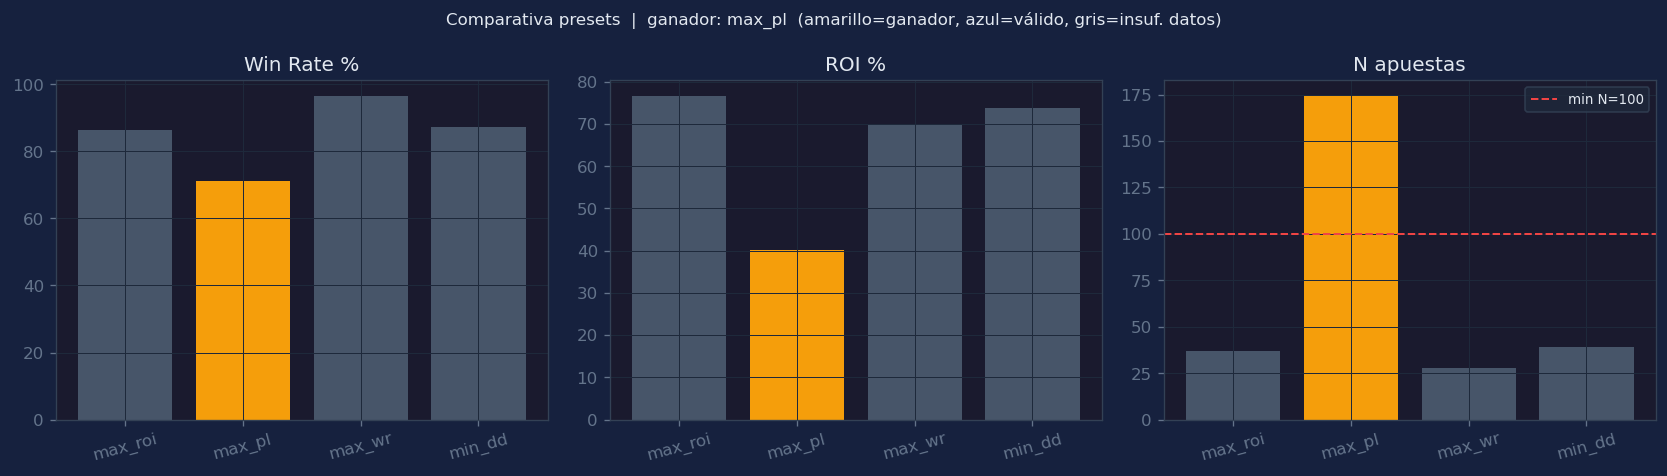

In [37]:
# ── COMPARAR TODOS LOS PRESETS Y ELEGIR EL MEJOR ─────────────────────────────
#
# PRESET_MIN_N:
#   Número mínimo de apuestas históricas para considerar un preset válido.
#   Presets con N < PRESET_MIN_N se muestran en la tabla pero no pueden ganar.
#   Subir cuando haya más datos. Con N>=100 el IC95 es estadísticamente sólido.
#
# PRESET_SELECTOR_CRITERION (solo aplica entre los presets que pasan PRESET_MIN_N):
#   'confident_roi'  → ci_low × roi / 100  (recomendado — edge real y demostrado)
#   'max_wr'         → mayor win rate
#   'max_roi'        → mayor ROI%
#   'max_pl'         → roi × n / 100  (proxy P/L — sin flat_pl en JSON)
#   'min_dd'         → mayor N  (proxy estabilidad)
# ─────────────────────────────────────────────────────────────────────────────
PRESET_MIN_N              = 100   # ← subir a 200 cuando haya muestra mayor
PRESET_SELECTOR_CRITERION = 'confident_roi'

_criteria = ['max_roi', 'max_pl', 'max_wr', 'min_dd']
_prows    = []

for _crit in _criteria:
    _p = _presets_dir / f'preset_{_crit}_config.json'
    if _p.exists():
        _c  = json.loads(_p.read_text(encoding='utf-8'))
        _s  = _c.get('_optimizer_stats', {})
        _st = [k for k, v in _c.get('strategies', {}).items() if v.get('enabled')]

        n       = int(_s.get('n', 0) or 0)
        wr      = float(_s.get('wr', 0) or 0)
        roi     = float(_s.get('roi', 0) or 0)
        ci_low  = float(_s.get('ci_low', 0) or 0)
        ci_high = float(_s.get('ci_high', 0) or 0)
        ok      = n >= PRESET_MIN_N   # pasa el filtro de muestra mínima

        score_map = {
            'confident_roi': round(ci_low * roi / 100, 4),
            'max_wr':        wr,
            'max_roi':       roi,
            'max_pl':        roi * n / 100,
            'min_dd':        float(n),
        }
        score = score_map.get(PRESET_SELECTOR_CRITERION, score_map['confident_roi'])

        _prows.append({
            'Criterio':    _crit,
            'N':           n,
            'N OK':        '✓' if ok else f'✗ <{PRESET_MIN_N}',
            'WR%':         wr,
            'IC95':        f'[{ci_low}–{ci_high}%]',
            'ROI%':        roi,
            'Score':       score if ok else -999.0,
            'BR Mode':     _c.get('bankroll_mode', '?'),
            'Risk':        _c.get('risk_filter', '?'),
            'Estrategias': ', '.join(_st),
        })
    else:
        _prows.append({
            'Criterio': _crit, 'N': 0, 'N OK': '✗ sin datos',
            'WR%': 0.0, 'IC95': '—', 'ROI%': 0.0, 'Score': -999.0,
            'BR Mode': '—', 'Risk': '—', 'Estrategias': '(no calculado)',
        })

# ── Auto-selección (solo entre presets que pasan PRESET_MIN_N) ────────────────
_valid = [r for r in _prows if r['Score'] > -999]
if _valid:
    _best_row   = max(_valid, key=lambda r: r['Score'])
    BEST_PRESET = _best_row['Criterio']
else:
    BEST_PRESET = None

n_valid   = len(_valid)
n_total   = len([r for r in _prows if r['N OK'] != '✗ sin datos'])
print(f'{"─"*65}')
print(f'  Mínimo N requerido: {PRESET_MIN_N}  |  Presets con datos: {n_total}  |  Válidos: {n_valid}')
print(f'{"─"*65}')
if BEST_PRESET:
    _br = _best_row
    print(f'  GANADOR ({PRESET_SELECTOR_CRITERION}): {BEST_PRESET}')
    print(f'  N={_br["N"]}  WR={_br["WR%"]}%  IC95={_br["IC95"]}  ROI={_br["ROI%"]}%  Score={_br["Score"]}')
    print(f'  BR Mode={_br["BR Mode"]}  Risk={_br["Risk"]}')
    print(f'  Estrategias: {_br["Estrategias"]}')
    print(f'  → BEST_PRESET = "{BEST_PRESET}"  (usado por la celda Aplicar)')
elif n_valid == 0 and n_total > 0:
    _mejor = max([r for r in _prows if r["N"] > 0], key=lambda r: r["N"])
    print(f'  Ningún preset alcanza N>={PRESET_MIN_N}. El mayor es {_mejor["Criterio"]} (N={_mejor["N"]}).')
    print(f'  Baja PRESET_MIN_N o acumula más datos.')
    BEST_PRESET = _mejor['Criterio']
    print(f'  → BEST_PRESET = "{BEST_PRESET}"  (fallback: mayor N disponible)')
else:
    print('  No hay presets calculados. Ejecuta las celdas de preset primero.')
print(f'{"─"*65}')

# ── Tabla comparativa ─────────────────────────────────────────────────────────
_df = pd.DataFrame(_prows)
_show_table(_df, f'Presets  |  min_N={PRESET_MIN_N}  |  selector={PRESET_SELECTOR_CRITERION}  |  ganador={BEST_PRESET}')

# ── Gráfico comparativo ───────────────────────────────────────────────────────
_calc = [r for r in _prows if r['N'] > 0]
if len(_calc) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    _labels = [r['Criterio'] for r in _calc]
    _winner_col  = '#f59e0b'
    _valid_col   = '#60a5fa'
    _invalid_col = '#475569'
    def _col(r):
        if r['Criterio'] == BEST_PRESET: return _winner_col
        return _valid_col if r['N'] >= PRESET_MIN_N else _invalid_col
    for ax, metric, title in zip(axes, ['WR%', 'ROI%', 'N'], ['Win Rate %', 'ROI %', 'N apuestas']):
        _vals = [float(r[metric]) for r in _calc]
        _cols = [_col(r) for r in _calc]
        ax.bar(_labels, _vals, color=_cols)
        if metric == 'N':
            ax.axhline(PRESET_MIN_N, color='#ef4444', lw=1.2, ls='--', label=f'min N={PRESET_MIN_N}')
            ax.legend(fontsize=8)
        ax.set_title(title, color='#e2e8f0')
        ax.tick_params(axis='x', rotation=15)
    fig.suptitle(f'Comparativa presets  |  ganador: {BEST_PRESET}  (amarillo=ganador, azul=válido, gris=insuf. datos)', color='#e2e8f0', fontsize=10)
    plt.tight_layout(); plt.show()


### #37 — Aplicar Preset al cartera_config.json

**Que hace**: Escribe `BEST_PRESET` en `cartera_config.json`. Con `DRY_RUN=True` (defecto) solo muestra los cambios sin escribir. Con `DRY_RUN=False` escribe y crea backup automatico. **Este paso actualiza el sistema en produccion — cambiar a False con precaucion.**

**Output esperado**: `DRY RUN — se aplicaria: preset_max_pl_config.json` con lista de parametros que cambiarian.

---

### ✅ Aplicar preset al sistema
> Escribe la configuración del preset elegido en `cartera_config.json` (hace backup automático)  
> Cambia `APPLY_CRITERION` al criterio deseado antes de ejecutar · la UI del dashboard recargará el config

In [38]:
# ── APLICAR PRESET AL SISTEMA ─────────────────────────────────────────────────
# Usa BEST_PRESET (auto-seleccionado por la celda anterior) o sobrescríbelo aquí.
# DRY_RUN = True  → solo muestra qué haría, sin tocar nada
# DRY_RUN = False → copia el preset a cartera_config.json (backup automático)
# ─────────────────────────────────────────────────────────────────────────────
import shutil
DRY_RUN             = False
APPLY_CRITERION     = BEST_PRESET   # ← None para usar auto-selección, o p.ej. 'max_wr' para forzar

if APPLY_CRITERION is None:
    print('ERROR: BEST_PRESET es None. Ejecuta primero la celda "Comparar todos".')
else:
    _src = _presets_dir / f'preset_{APPLY_CRITERION}_config.json'
    _dst = _project_root / 'betfair_scraper' / 'cartera_config.json'

    if not _src.exists():
        print(f'ERROR: {_src} no existe. Ejecuta primero "Ejecutar presets" con criterio {APPLY_CRITERION}.')
    elif DRY_RUN:
        _c = json.loads(_src.read_text(encoding='utf-8'))
        _s = _c.get('_optimizer_stats', {})
        print(f'DRY RUN — se aplicaría: {_src.name}')
        print(f'  Criterio: {APPLY_CRITERION}  |  Selector: {PRESET_SELECTOR_CRITERION}')
        print(f'  N={_s.get("n","?")}  WR={_s.get("wr","?")}%  ROI={_s.get("roi","?")}%  P/L={_s.get("pl","?")}€')
        _st = [k for k, v in _c.get('strategies', {}).items() if v.get('enabled')]
        print(f'  Estrategias activas: {", ".join(_st)}')
        print(f'\nPon DRY_RUN=False para aplicar realmente.')
    else:
        _bak = _dst.with_suffix(f'.json.bak_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
        shutil.copy2(_dst, _bak)
        shutil.copy2(_src, _dst)
        print(f'✓ Aplicado: preset_{APPLY_CRITERION}_config.json → cartera_config.json')
        print(f'  Backup guardado en: {_bak.name}')
        print(f'  El paper trading lo aplicará en ~60s.')


✓ Aplicado: preset_max_pl_config.json → cartera_config.json
  Backup guardado en: cartera_config.json.bak_20260305_203550
  El paper trading lo aplicará en ~60s.


### #38 — Aplicar CO Optimo al cartera_config.json

**Que hace**: Escribe `G_CO_CONFIG` (el CO optimo de #30) en `cartera_config.json`. Con `DRY_RUN_CO=True` solo muestra, con `False` aplica. Independiente del flujo de presets — compatible con cualquier preset.

**Output esperado**: `DRY RUN — cambios pendientes (Sin CO): coLayPct: None → None ...`

---

### 🎛️ Aplicar CO óptimo al sistema
> Escribe en `cartera_config.json` la configuración `G_CO_CONFIG` seleccionada automáticamente por el CO Optimizer.  
> Independiente del flujo de presets — usa el resultado del análisis de esta sesión.

In [39]:
# ── APLICAR CO ÓPTIMO AL SISTEMA ─────────────────────────────────────────────
# Escribe G_CO_CONFIG en cartera_config.json.
# G_CO_CONFIG puede ser {} (sin CO), {'adverse_goal_stop': True},
# {'cashout_lay_pct': X}, {'trailing_stop_pct': X}, o combinaciones.
# ---------------------------------------------------------------------------
DRY_RUN_CO = True   # Cambia a False para aplicar realmente

_cfg_path = _project_root / 'betfair_scraper' / 'cartera_config.json'
with open(_cfg_path, 'r', encoding='utf-8') as _f:
    _cfg = json.load(_f)

# Campos CO en cartera_config.json (todos se resetean y luego se aplica G_CO_CONFIG)
_CO_FIELDS = {'coLayPct': None, 'coAdverseGoalStop': False, 'coTrailingStopPct': None}
_new_co = {
    'coLayPct':           G_CO_CONFIG.get('cashout_lay_pct', None),
    'coAdverseGoalStop':  G_CO_CONFIG.get('adverse_goal_stop', False),
    'coTrailingStopPct':  G_CO_CONFIG.get('trailing_stop_pct', None),
}

_old_co = {k: _cfg.get(k) for k in _CO_FIELDS}

if DRY_RUN_CO:
    print(f'DRY RUN — cambios pendientes ({G_CO_LABEL}):')
    for k, v in _new_co.items():
        marker = ' ←' if _cfg.get(k) != v else ''
        print(f'  {k}: {_cfg.get(k)} → {v}{marker}')
    print(f'\nPon DRY_RUN_CO = False para aplicar.')
else:
    from datetime import datetime
    import shutil
    _bak = _cfg_path.with_suffix(f'.json.bak_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
    shutil.copy2(_cfg_path, _bak)
    _cfg.update(_new_co)
    with open(_cfg_path, 'w', encoding='utf-8') as _f:
        json.dump(_cfg, _f, indent=2, ensure_ascii=False)
    print(f'✓ CO aplicado: {G_CO_LABEL}')
    for k, v in _new_co.items():
        print(f'  {k}: {_old_co[k]} → {v}')
    print(f'  Backup: {_bak.name}')
    print(f'  Paper trading actualizará en ~60s.')

DRY RUN — cambios pendientes (Sin CO  [desactivado — óptimo sería: Sin CO +0.00€]):
  coLayPct: None → None
  coAdverseGoalStop: None → False ←
  coTrailingStopPct: None → None

Pon DRY_RUN_CO = False para aplicar.


### #39 — Export para Agente Analista

**Que hace**: Genera los 2 ficheros de analisis en `analisis/`: `portfolio_analysis_{timestamp}.json` con estadisticas pre-calculadas (per_strategy, what-if, correlacion, distribucion temporal, odds buckets, config_consistency, hints de analisis) y `portfolio_bets_{timestamp}.csv` con el detalle apuesta a apuesta. **Ejecutar siempre al final del flujo para tener el export actualizado.**

**Output esperado**: `Exportado: JSON → analisis/portfolio_analysis_{timestamp}.json / CSV → analisis/portfolio_bets_{timestamp}.csv`

---

## 📦 Export para Agente Analista
> Exporta un JSON + CSV completo con todo el detalle de la cartera seleccionada.
> El JSON incluye: métricas por estrategia, análisis what-if, correlación entre estrategias,
> distribución temporal, buckets de odds, hints pre-calculados y snapshot de config.
> Diseñado para ser consumido por un agente LLM que audite el diseño de la cartera.


In [40]:

# ── EXPORT PARA AGENTE ANALISTA ───────────────────────────────────────────────
import csv as _csv
from datetime import datetime, timezone
from collections import defaultdict
from pathlib import Path
import math as _math

_EXPORT_DIR = _project_root / 'analisis'
_EXPORT_DIR.mkdir(exist_ok=True)
_ts_str   = datetime.now().strftime('%Y%m%d_%H%M%S')
_json_out = _EXPORT_DIR / f'portfolio_analysis_{_ts_str}.json'
_csv_out  = _EXPORT_DIR / f'portfolio_bets_{_ts_str}.csv'

_cfg_path = _project_root / 'betfair_scraper' / 'cartera_config.json'
_cfg      = json.loads(_cfg_path.read_text(encoding='utf-8'))
_scale    = G_STAKE / 10.0   # stake interno (10) -> G_STAKE

# ── 1. Bets enriquecidas ──────────────────────────────────────────────────────
_bets_sorted = sorted(_bets_risk, key=lambda b: b.get('timestamp_utc') or '')

_match_count = defaultdict(int)
for b in _bets_sorted:
    _match_count[b.get('match_id', '')] += 1

_cum = 0.0
_ebets = []
for i, b in enumerate(_bets_sorted, 1):
    pl = round(float(b.get('pl') or 0) * _scale, 4)
    _cum = round(_cum + pl, 4)
    _ebets.append({
        'seq': i,
        'timestamp_utc':      b.get('timestamp_utc', ''),
        'date':               (b.get('timestamp_utc') or '')[:10],
        'match_id':           b.get('match_id', ''),
        'match_bet_count':    _match_count[b.get('match_id', '')],
        'strategy':           b.get('strategy', ''),
        'minuto':             b.get('minuto'),
        'bet_type_dir':       b.get('bet_type_dir', ''),
        'won':                b.get('won'),
        'pl_eur':             pl,
        'cum_pl_eur':         _cum,
        'effective_odds':     b.get('effective_odds'),
        'risk_level':         b.get('risk_level', ''),
        'xg_total':           b.get('xg_total'),
        'xg_excess':          b.get('xg_excess'),
        'xg_ratio':           b.get('xg_ratio'),
        'poss_diff':          b.get('poss_diff'),
        'shots_total':        b.get('shots_total'),
        'sot_team':           b.get('sot_team'),
        'sot_total':          b.get('sot_total'),
        'sot_max':            b.get('sot_max'),
        'sot_dominant':       b.get('sot_dominant'),
        'sot_rival':          b.get('sot_rival'),
        'drift_pct':          b.get('drift_pct'),
        'goal_diff':          b.get('goal_diff'),
        'back_odds':          b.get('back_odds'),
        'back_draw':          b.get('back_draw'),
        'over_odds':          b.get('over_odds'),
        'lay_over15_odds':    b.get('lay_over15_odds'),
        'lay_draw_odds':      b.get('lay_draw_odds'),
        'lay_over25_odds':    b.get('lay_over25_odds'),
        'lay_false_fav_odds': b.get('lay_false_fav_odds'),
        'fav_back_odds':      b.get('fav_back_odds'),
        'back_sot_odds':      b.get('back_sot_odds'),
        'back_over15_odds':   b.get('back_over15_odds'),
        'total_goals_trigger':b.get('total_goals_trigger'),
        'passes_lay_v1':      b.get('passes_lay_v1'),
        'passes_lay_v2':      b.get('passes_lay_v2'),
        'backed_team':        b.get('backed_team'),
        'fav_team':           b.get('fav_team'),
        'team':               b.get('team'),
    })

# ── 2. Stats por estrategia ───────────────────────────────────────────────────
_sg = defaultdict(list)
for b in _ebets:
    _sg[b['strategy']].append(b)

def _ss(bets):
    n = len(bets); wins = sum(1 for b in bets if b['won'])
    pl = round(sum(b['pl_eur'] for b in bets), 4)
    odds = [b['effective_odds'] for b in bets if b.get('effective_odds')]
    cl, ch = _wilson_ci(wins, n) if n else (0, 0)
    minutes = sorted(set(b['minuto'] for b in bets if b.get('minuto') is not None))
    return {
        'n': n, 'wins': wins, 'losses': n - wins,
        'wr_pct':  round(wins / n * 100, 2) if n else 0,
        'ci_low': cl, 'ci_high': ch,
        'pl_eur': pl,
        'roi_pct': round(pl / (n * G_STAKE) * 100, 2) if n else 0,
        'avg_odds': round(sum(odds) / len(odds), 3) if odds else None,
        'min_odds': round(min(odds), 3) if odds else None,
        'max_odds': round(max(odds), 3) if odds else None,
        'pct_portfolio': round(n / len(_ebets) * 100, 1) if _ebets else 0,
        'minute_range': [min(minutes), max(minutes)] if minutes else [],
        'bet_types': list(set(b['bet_type_dir'] for b in bets if b.get('bet_type_dir'))),
    }

_per_strat = {s: _ss(bets) for s, bets in sorted(_sg.items())}

# ── 3. What-if: quitar cada estrategia ───────────────────────────────────────
_base_sim = _sim_full(_bets_sorted)
_what_if  = []
for s in _per_strat:
    _rest = [b for b in _bets_sorted if b.get('strategy') != s]
    if not _rest:
        continue
    _s2 = _sim_full(_rest)
    _what_if.append({
        'remove': s,
        'n_remaining':  _s2['total'],
        'wr_delta':     round(_s2['win_pct']  - _base_sim['win_pct'],  2),
        'roi_delta':    round(_s2['flat_roi'] - _base_sim['flat_roi'], 2),
        'pl_delta_eur': round((_s2['flat_pl'] - _base_sim['flat_pl']) * _scale, 4),
        'dd_delta_eur': round((_s2['flat_dd']['max_dd'] - _base_sim['flat_dd']['max_dd']) * _scale, 4),
        'verdict': 'MEJORA' if (_s2['flat_pl'] - _base_sim['flat_pl']) > 0 else 'empeora',
    })
_what_if.sort(key=lambda x: -x['pl_delta_eur'])

# ── 4. Correlacion entre estrategias (mismo partido) ─────────────────────────
_co_pairs  = defaultdict(lambda: {'both_win': 0, 'both_lose': 0, 'split': 0})
_match_bets = defaultdict(list)
for b in _ebets:
    _match_bets[b['match_id']].append(b)

for mid, bets in _match_bets.items():
    if len(bets) < 2:
        continue
    for i in range(len(bets)):
        for j in range(i + 1, len(bets)):
            sa, sb = bets[i]['strategy'], bets[j]['strategy']
            key = tuple(sorted([sa, sb]))
            wa, wb = bets[i]['won'], bets[j]['won']
            if wa and wb:             _co_pairs[key]['both_win']  += 1
            elif not wa and not wb:   _co_pairs[key]['both_lose'] += 1
            else:                     _co_pairs[key]['split']     += 1

_correlation = []
for (sa, sb), counts in sorted(_co_pairs.items()):
    total = counts['both_win'] + counts['both_lose'] + counts['split']
    agree = (counts['both_win'] + counts['both_lose']) / total * 100 if total else 0
    _correlation.append({
        'strategy_a': sa, 'strategy_b': sb, 'co_fires': total,
        'both_win': counts['both_win'], 'both_lose': counts['both_lose'], 'split': counts['split'],
        'agreement_pct': round(agree, 1),
        'note': 'alta correlacion — riesgo doble exposicion' if total >= 5 and agree >= 70 else '',
    })
_correlation.sort(key=lambda x: -x['co_fires'])

# ── 5. Distribucion temporal ──────────────────────────────────────────────────
_by_date = defaultdict(lambda: {'n': 0, 'wins': 0, 'pl_eur': 0.0})
for b in _ebets:
    d = b['date']
    _by_date[d]['n']      += 1
    _by_date[d]['wins']   += int(bool(b['won']))
    _by_date[d]['pl_eur'] += b['pl_eur']

_temporal = [{'date': d, **{k: round(v, 4) if isinstance(v, float) else v for k, v in _by_date[d].items()}}
             for d in sorted(_by_date.keys())]

_half = len(_ebets) // 2
_wr_first  = round(sum(1 for b in _ebets[:_half] if b['won']) / _half * 100, 2) if _half else 0
_wr_second = round(sum(1 for b in _ebets[_half:] if b['won']) / (_half + len(_ebets) % 2) * 100, 2) if _half else 0

# ── 6. Buckets de odds ────────────────────────────────────────────────────────
_buckets = [('1.00-1.50', 1.00, 1.50), ('1.50-2.00', 1.50, 2.00),
            ('2.00-3.00', 2.00, 3.00), ('3.00-5.00', 3.00, 5.00), ('5.00+', 5.00, 999)]
_odds_buckets = []
for label, lo, hi in _buckets:
    bk = [b for b in _ebets if b.get('effective_odds') and lo <= b['effective_odds'] < hi]
    if not bk:
        continue
    wins = sum(1 for b in bk if b['won'])
    pl   = round(sum(b['pl_eur'] for b in bk), 4)
    cl, ch = _wilson_ci(wins, len(bk))
    _odds_buckets.append({
        'bucket': label, 'n': len(bk), 'wins': wins,
        'wr_pct': round(wins / len(bk) * 100, 2), 'ci_low': cl, 'ci_high': ch,
        'pl_eur': pl, 'roi_pct': round(pl / (len(bk) * G_STAKE) * 100, 2),
    })

# ── 7. Config consistency ─────────────────────────────────────────────────────
_enabled_cfg  = {k for k, v in _cfg.get('strategies', {}).items() if v.get('enabled')}
_active_bets  = set(_per_strat.keys())
_param_notes  = []
for k, v in _cfg.get('strategies', {}).items():
    if not v.get('enabled'): continue
    for param, threshold in [('xgMax', 5), ('shotsMax', 50), ('possMax', 90)]:
        val = v.get(param)
        if val and val >= threshold:
            _param_notes.append(f'{k}.{param}={val} — filtro practicamente inactivo')

_consistency = {
    'enabled_no_bets':  sorted(_enabled_cfg - _active_bets),
    'bets_not_in_cfg':  sorted(_active_bets - _enabled_cfg),
    'param_notes':      _param_notes,
}

# ── 8. Hints pre-calculados ───────────────────────────────────────────────────
_hints = []
for s, st in _per_strat.items():
    if st['n'] < 20:
        _hints.append({'type': 'low_sample', 'severity': 'warning', 'strategy': s,
            'detail': f'N={st["n"]} — IC95=[{st["ci_low"]}-{st["ci_high"]}%] demasiado amplio'})
    if st['roi_pct'] < 0:
        _hints.append({'type': 'negative_roi', 'severity': 'critical', 'strategy': s,
            'detail': f'ROI={st["roi_pct"]}% — drena el portfolio'})
    if st['wr_pct'] < 45 and st['n'] >= 20:
        _hints.append({'type': 'low_wr', 'severity': 'warning', 'strategy': s,
            'detail': f'WR={st["wr_pct"]}% avg_odds={st["avg_odds"]} — verificar EV positivo'})
    if st['pct_portfolio'] > 40:
        _hints.append({'type': 'concentration', 'severity': 'warning', 'strategy': s,
            'detail': f'{st["pct_portfolio"]}% del portfolio — concentracion alta'})

if _consistency['enabled_no_bets']:
    _hints.append({'type': 'config_mismatch', 'severity': 'warning', 'strategy': None,
        'detail': f'Habilitadas sin apuestas: {_consistency["enabled_no_bets"]}'})
if _consistency['bets_not_in_cfg']:
    _hints.append({'type': 'config_mismatch', 'severity': 'info', 'strategy': None,
        'detail': f'Apuestas de estrategias no habilitadas: {_consistency["bets_not_in_cfg"]}'})
for w in _what_if:
    if w['verdict'] == 'MEJORA' and w['pl_delta_eur'] > G_STAKE:
        _hints.append({'type': 'improvable', 'severity': 'info', 'strategy': w['remove'],
            'detail': f'Quitar mejora P/L en +{w["pl_delta_eur"]:.2f}€ (roi delta={w["roi_delta"]:+.1f}%)'})
for c in _correlation:
    if c['agreement_pct'] >= 70 and c['co_fires'] >= 5:
        _hints.append({'type': 'correlation', 'severity': 'warning', 'strategy': None,
            'detail': f'{c["strategy_a"]} + {c["strategy_b"]}: {c["agreement_pct"]}% acuerdo en {c["co_fires"]} co-disparos'})
if abs(_wr_second - _wr_first) > 10:
    _hints.append({'type': 'temporal_instability', 'severity': 'warning', 'strategy': None,
        'detail': f'WR 1a mitad={_wr_first}% vs 2a={_wr_second}% — diferencia {abs(_wr_second-_wr_first):.1f}pp'})
for note in _param_notes:
    _hints.append({'type': 'param_check', 'severity': 'info', 'strategy': None, 'detail': note})

# ── 9. Ensamblar y exportar ───────────────────────────────────────────────────
_ts_all = [b['timestamp_utc'] for b in _ebets if b['timestamp_utc']]
_export = {
    'meta': {
        'export_timestamp':         datetime.now(timezone.utc).isoformat(),
        'preset_applied':           BEST_PRESET,
        'preset_optimizer_stats':   _cfg.get('_optimizer_stats', {}),
        'date_range':               {'from': min(_ts_all)[:10], 'to': max(_ts_all)[:10]} if _ts_all else {},
        'total_matches_in_dataset': len(set(b.get('match_id', '') for b in _ALL_BETS)),
        'total_bets_in_dataset':    len(_ALL_BETS),
        'bets_after_filters':       len(_ebets),
        'stake_eur':                G_STAKE,
        'bankroll_eur':             G_BANKROLL,
        'adj_settings':             G_ADJ,
        'risk_filter':              G_RISK,
        'config_snapshot':          _cfg,
    },
    'portfolio': {
        'n':             _base_sim['total'],
        'wins':          _base_sim['wins'],
        'wr_pct':        _base_sim['win_pct'],
        'ci_low':        _wilson_ci(_base_sim['wins'], _base_sim['total'])[0] if _base_sim['total'] else 0,
        'ci_high':       _wilson_ci(_base_sim['wins'], _base_sim['total'])[1] if _base_sim['total'] else 0,
        'roi_pct':       _base_sim['flat_roi'],
        'pl_eur':        round(_base_sim['flat_pl'] * _scale, 4),
        'max_dd_eur':    round(_base_sim['flat_dd']['max_dd'] * _scale, 4),
        'worst_streak':  _base_sim['worst_streak'],
        'n_strategies':  len(_per_strat),
        'wr_first_half': _wr_first,
        'wr_second_half':_wr_second,
    },
    'per_strategy':             _per_strat,
    'what_if_remove_strategy':  _what_if,
    'strategy_correlation':     _correlation,
    'odds_bucket_analysis':     _odds_buckets,
    'temporal_distribution':    _temporal,
    'config_consistency':       _consistency,
    'analysis_hints':           _hints,
    'bets':                     _ebets,
}

_json_out.write_text(json.dumps(_export, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
if _ebets:
    _fields = list(_ebets[0].keys())
    with open(_csv_out, 'w', newline='', encoding='utf-8') as _f:
        _w = _csv.DictWriter(_f, fieldnames=_fields)
        _w.writeheader(); _w.writerows(_ebets)

print(f'Exportado:')
print(f'  JSON -> {_json_out}')
print(f'  CSV  -> {_csv_out}')
print(f'  {len(_ebets)} apuestas | {len(_per_strat)} estrategias | {len(_hints)} hints')
print()
print('Per-estrategia:')
for s, st in sorted(_per_strat.items(), key=lambda x: -x[1]['pl_eur']):
    flag = ' WARN' if st['roi_pct'] < 0 or st['n'] < 20 else ''
    print(f'  {s:35s} N={st["n"]:4d}  WR={st["wr_pct"]:5.1f}%  ROI={st["roi_pct"]:+6.1f}%  P/L={st["pl_eur"]:+6.2f}{flag}')
print()
print(f'Estabilidad: WR 1a mitad={_wr_first}% vs 2a={_wr_second}%')
print()
print('What-if top 5:')
for w in _what_if[:5]:
    print(f'  Quitar {w["remove"]:35s} delta={w["pl_delta_eur"]:+.2f}  ({w["verdict"]})')
print()
print('Hints:')
for h in _hints:
    print(f'  [{h["severity"].upper():8s}] {h["type"]:25s} {h["detail"]}')


Exportado:
  JSON -> C:\Users\agonz\OneDrive\Documents\Proyectos\Furbo\analisis\portfolio_analysis_20260305_203550.json
  CSV  -> C:\Users\agonz\OneDrive\Documents\Proyectos\Furbo\analisis\portfolio_bets_20260305_203550.csv
  474 apuestas | 12 estrategias | 10 hints

Per-estrategia:
  sd_over25_2goal                     N=  41  WR= 65.8%  ROI= +77.0%  P/L=+31.59
  sd_cs_one_goal                      N=  44  WR= 70.5%  ROI= +61.3%  P/L=+26.97
  sd_under35_late                     N=  30  WR= 70.0%  ROI= +80.1%  P/L=+24.02
  lay_over25_def                      N=  51  WR= 90.2%  ROI= +44.5%  P/L=+22.72
  sd_ud_leading                       N=  40  WR= 65.0%  ROI= +55.8%  P/L=+22.31
  sd_back_longshot                    N=  44  WR= 59.1%  ROI= +38.1%  P/L=+16.75
  sd_back_leader_dom                  N=  26  WR= 92.3%  ROI= +54.4%  P/L=+14.13
  lay_over15                          N=  22  WR= 72.7%  ROI= +37.3%  P/L= +8.21
  goal_clustering                     N=  65  WR= 70.8%  ROI= +11.1%